<div style="
    max-width: 1150px;
    margin: 24px auto;
    padding: 6px 10px;
    display: flex;
    justify-content: center; 
    align-items: center; 
    text-align: center;
    font-size: 20px;
    font-weight: 600;
    background-color: #013e6c;    
    border-radius: 5px;
    font-family: 'samim';
">
   <h3 style="
   margin: 0;
   color: #f5f1f2ff;
   font-weight: 900;
   "> 
    Heart Disease Risk </h3>
</div>

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
About Dataset
</h3>
<p> 
A synthetic heart health dataset combining clinical measurements, lifestyle habits and activity data to explore heart disease risk through data analysis and machine learning.

Heart disease risk is rarely explained by a single factor. This dataset brings together 9,000 records and 27 variables covering a broad range of health indicators-from traditional clinical measurements to everyday lifestyle and activity patterns.

It includes key cardiovascular and metabolic features such as blood pressure, total cholesterol, HDL, LDL, triglycerides, fasting blood sugar, HbA1c, BMI, resting and maximum heart rate, chest pain, ST depression and exercise-induced angina. It also extends beyond clinical measurements with smoking status, family history, alcohol consumption, exercise, sleep, stress, daily steps, diet quality and wearable ownership.

The target variable, has_heart_disease, identifies whether heart disease is present (0 = No, 1 = Yes). In this dataset, 30.3% of records are positive for heart disease, providing a useful classification target for exploring risk patterns and building predictive models.
</p> 
</div>

<div style="
    max-width: 1150px;
    margin: 24px auto;
    padding: 6px 10px;
    display: flex;
    justify-content: center; 
    align-items: center; 
    text-align: center;
    font-size: 20px;
    font-weight: 600;
    background-color: #013e6c;    
    border-radius: 5px;
    font-family: 'samim';
">
   <h3 style="
   margin: 0;
   color: #f5f1f2ff;
   font-weight: 900;
   "> 
    Reading Data </h3>
</div>

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import learning_curve
from matplotlib.colors import LogNorm
import joblib

In [3]:
class Color:
       BLUE = "\033[94m"
       RESET = "\033[0m"
       BOLD = "\033[1m"

In [4]:
data = pd.read_csv("../data/heart_disease.csv")
data.head(10)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
5,6,50,Female,122,71,147,46,101,41,134,...,True,Former,3.3,190,5.9,55.1,False,6857,82.6,0
6,7,50,Female,133,85,227,63,124,194,109,...,False,Never,5.1,91,8.2,82.2,True,8466,63.7,0
7,8,58,Female,133,81,141,54,99,40,118,...,True,Current,2.5,92,6.4,45.5,True,6769,42.4,1
8,9,51,Female,121,64,219,84,104,85,136,...,False,Former,2.8,266,9.0,65.6,True,7648,53.5,0
9,10,51,Male,126,77,172,50,104,115,132,...,True,Former,6.1,89,9.1,58.7,False,7531,53.2,0


In [5]:
rows, columns = data.shape
print(f'The data has {Color.BLUE}{rows}{Color.RESET} rows.')
print(f'The data has {Color.BLUE}{columns}{Color.RESET} columns.')

The data has 9000 rows.
The data has 27 columns.


In [6]:
pd.DataFrame({
    "Column": data.columns,
    "Data Type": data.dtypes.values,
    "Non-Null": data.notna().sum().values,
})

,Column,Data Type,Non-Null
0,patient_id,int64,9000
1,age,int64,9000
2,sex,str,9000
3,resting_bp_systolic,int64,9000
4,resting_bp_diastolic,int64,9000
5,cholesterol_total,int64,9000
6,hdl,int64,9000
7,ldl,int64,9000
8,triglycerides,int64,9000
9,fasting_blood_sugar,int64,9000


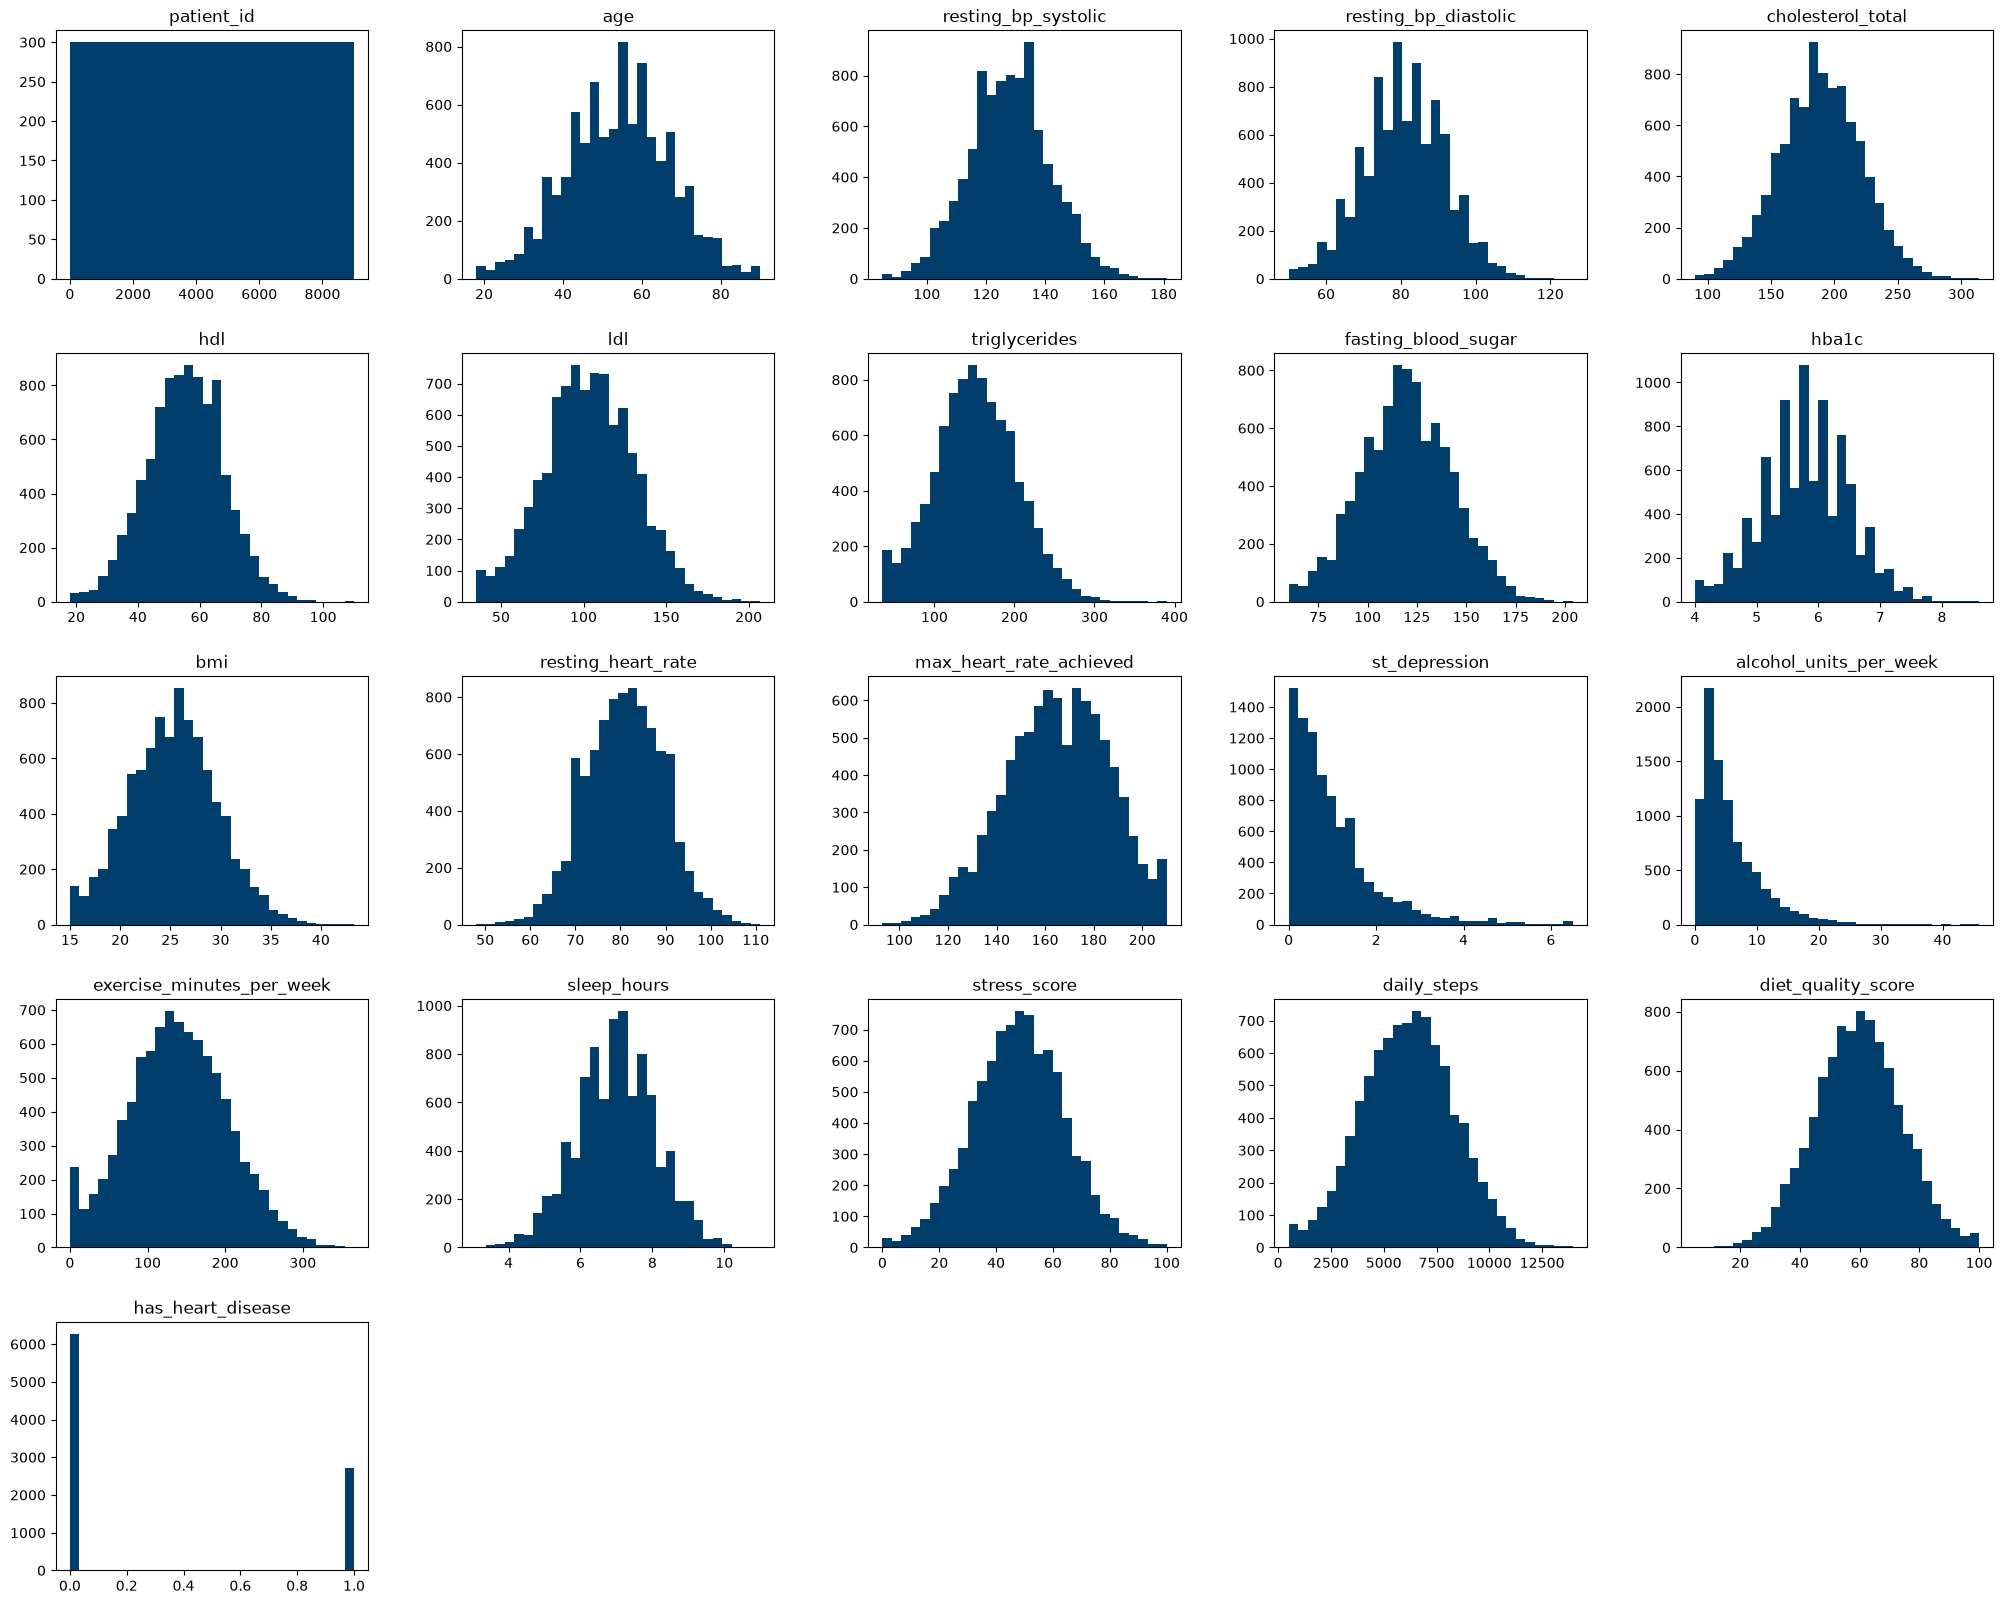

In [7]:
data.hist(bins=30, figsize=(25, 20), color="#013e6c", grid=False)
plt.show()

In [8]:
skew = data.select_dtypes(include="number").skew().sort_values()
print(skew)

max_heart_rate_achieved     -0.184662
sleep_hours                 -0.042455
age                         -0.021674
resting_heart_rate          -0.018912
stress_score                -0.012987
patient_id                   0.000000
diet_quality_score           0.001227
cholesterol_total            0.003850
resting_bp_diastolic         0.008614
hdl                          0.020459
daily_steps                  0.024890
hba1c                        0.029182
fasting_blood_sugar          0.040870
ldl                          0.044963
resting_bp_systolic          0.067686
bmi                          0.091722
exercise_minutes_per_week    0.093647
triglycerides                0.125859
has_heart_disease            0.857494
alcohol_units_per_week       2.027234
st_depression                2.040911
dtype: float64


<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The data contains 9000 rows and 27 columns.
Within the data, there are features with str and bool types
except for the two columns alcohol_units_per_week - st_depression which are right-skewed, the remaining features have normal distributions
</p> 
</div>

<div style="
    max-width: 1150px;
    margin: 24px auto;
    padding: 6px 10px;
    display: flex;
    justify-content: center; 
    align-items: center; 
    text-align: center;
    font-size: 20px;
    font-weight: 600;
    background-color: #013e6c;    
    border-radius: 5px;
    font-family: 'samim';
">
   <h3 style="
   margin: 0;
   color: #f5f1f2ff;
   font-weight: 900;
   "> 
    Cleaning Data </h3>
</div>

In [9]:
duplicated_values = data.duplicated().sum()
print(f'The data has {duplicated_values} duplicated values')

The data has 0 duplicated values


In [10]:
pd.DataFrame({"Missing Values": data.isna().sum()})

,Missing Values
patient_id,0
age,0
sex,0
resting_bp_systolic,0
resting_bp_diastolic,0
cholesterol_total,0
hdl,0
ldl,0
triglycerides,0
fasting_blood_sugar,0


<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
There are no duplicate data or missing values in the data, so we can conclude that our data is clean.
</p> 
</div>

<div style="
    max-width: 1150px;
    margin: 24px auto;
    padding: 6px 10px;
    display: flex;
    justify-content: center; 
    align-items: center; 
    text-align: center;
    font-size: 20px;
    font-weight: 600;
    background-color: #013e6c;    
    border-radius: 5px;
    font-family: 'samim';
">
   <h3 style="
   margin: 0;
   color: #f5f1f2ff;
   font-weight: 900;
   "> 
    PreProcessing </h3>
</div>

In [11]:
df =data.copy()

In [12]:
df.drop(columns=["patient_id"], inplace= True)
df
# In this project, `patient_id` is considered an identifier and will not be used in the model training process.

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,36,Female,108,63,178,68,82,158,96,5.3,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,44,Female,112,73,213,54,139,102,125,5.9,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,57,Female,144,93,198,66,113,79,102,5.7,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,61,Female,130,70,220,68,135,109,104,5.5,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1


In [13]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical features --> {Color.BLUE} {numerical_features} {Color.RESET}', len(numerical_features))

Numerical features -->  ['age', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi', 'resting_heart_rate', 'max_heart_rate_achieved', 'st_depression', 'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours', 'stress_score', 'daily_steps', 'diet_quality_score', 'has_heart_disease']  20


In [14]:
categorical_features = df.select_dtypes(include=['str', 'bool']).columns.tolist()
print(f'Categoricall features --> {Color.BLUE} {categorical_features} {Color.RESET}', len(categorical_features))

Categoricall features -->  ['sex', 'chest_pain_type', 'exercise_induced_angina', 'family_history', 'smoker_status', 'wearable_owner']  6


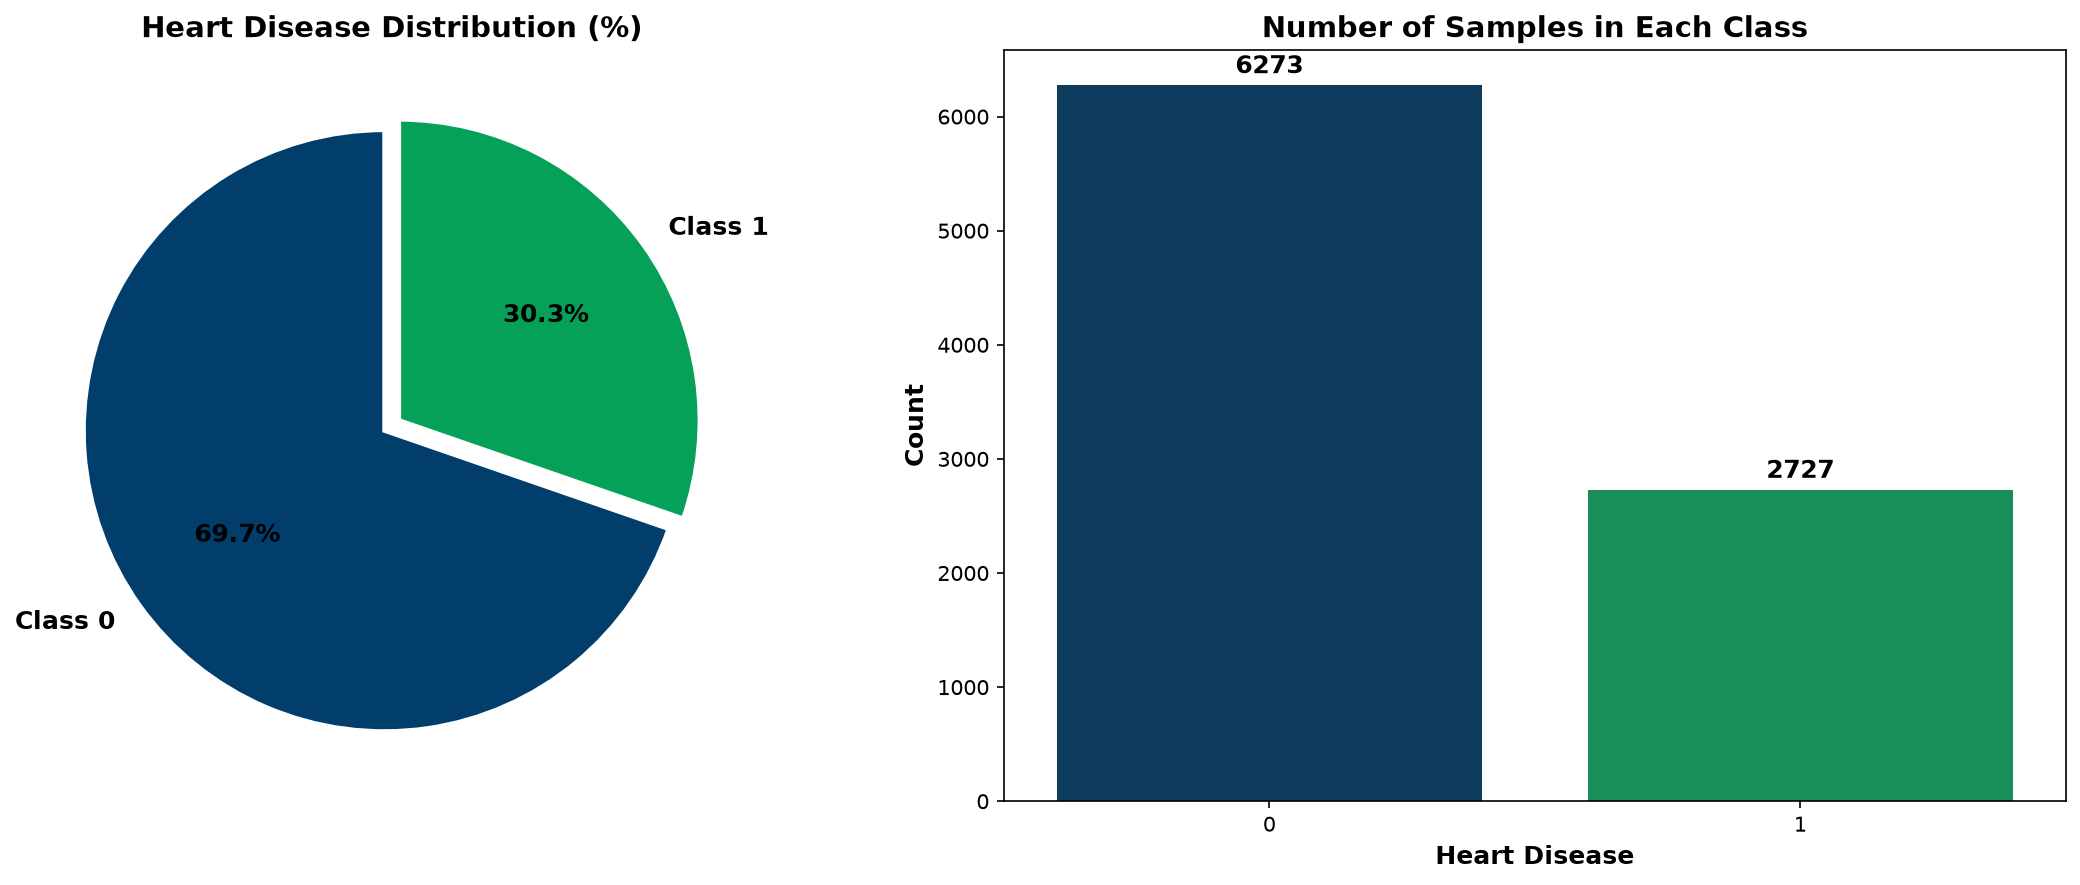

In [15]:
target = "has_heart_disease"

counts = data[target].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"Class {i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=target, hue=target, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Approximately one-third of the entire target column consists of class 1, meaning people who are sick, and two-thirds of the target column consists of class 0, meaning healthy people.
</p> 
</div>

### Numerical Features

* ##### Age

In [16]:
df["age"].describe()

count    9000.000000
mean       53.977333
std        13.008051
min        18.000000
25%        45.000000
50%        54.000000
75%        63.000000
max        90.000000
Name: age, dtype: float64

In [17]:
df["age"].dtype

dtype('int64')

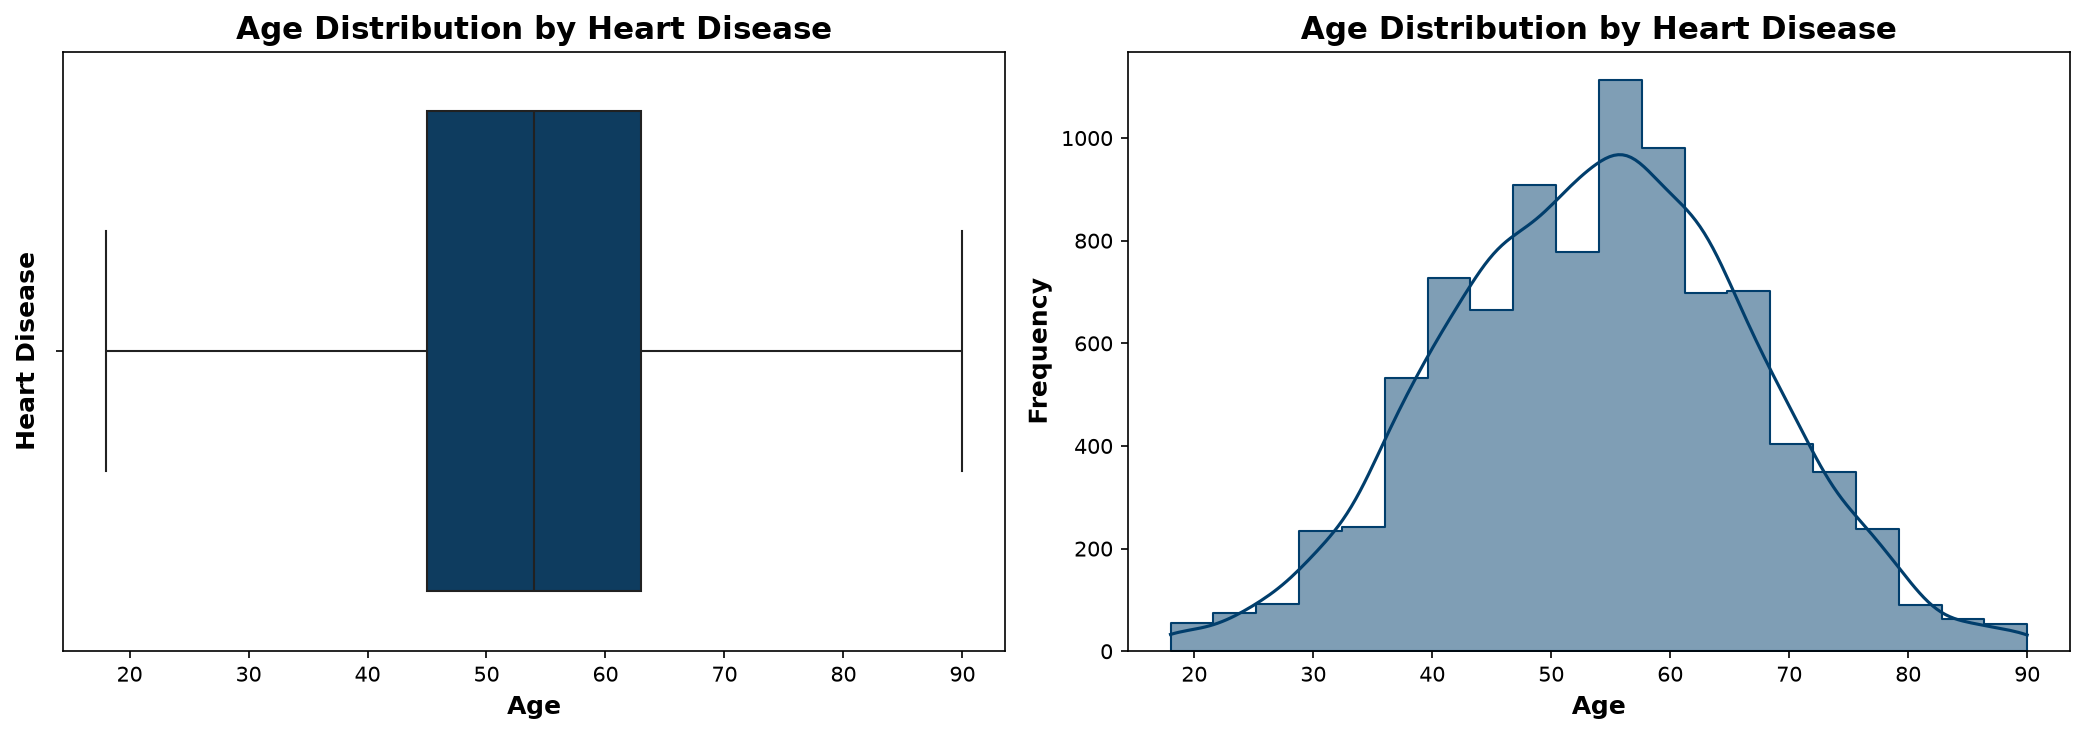

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="age", ax=axes[0], color="#013e6c")

axes[0].set_title("Age Distribution by Heart Disease", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Age", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="age", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Age Distribution by Heart Disease", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Age", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [19]:
df["age"].skew()

np.float64(-0.021673676942241465)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Age distribution is approximately symmetric, with a very slight negative (left) skewness of -0.0216. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The distribution of the ages of the people in our data set is close to normal distribution. The mean is 53.97 with a standard deviation of 13 The ages vary from 18to 90 (both inclusive). The median is 54.
</p> 
</div>

In [20]:
age_group = pd.cut(df["age"], bins=[17, 29, 39, 49, 59, 69, 79, 90], 
                   labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-90"])

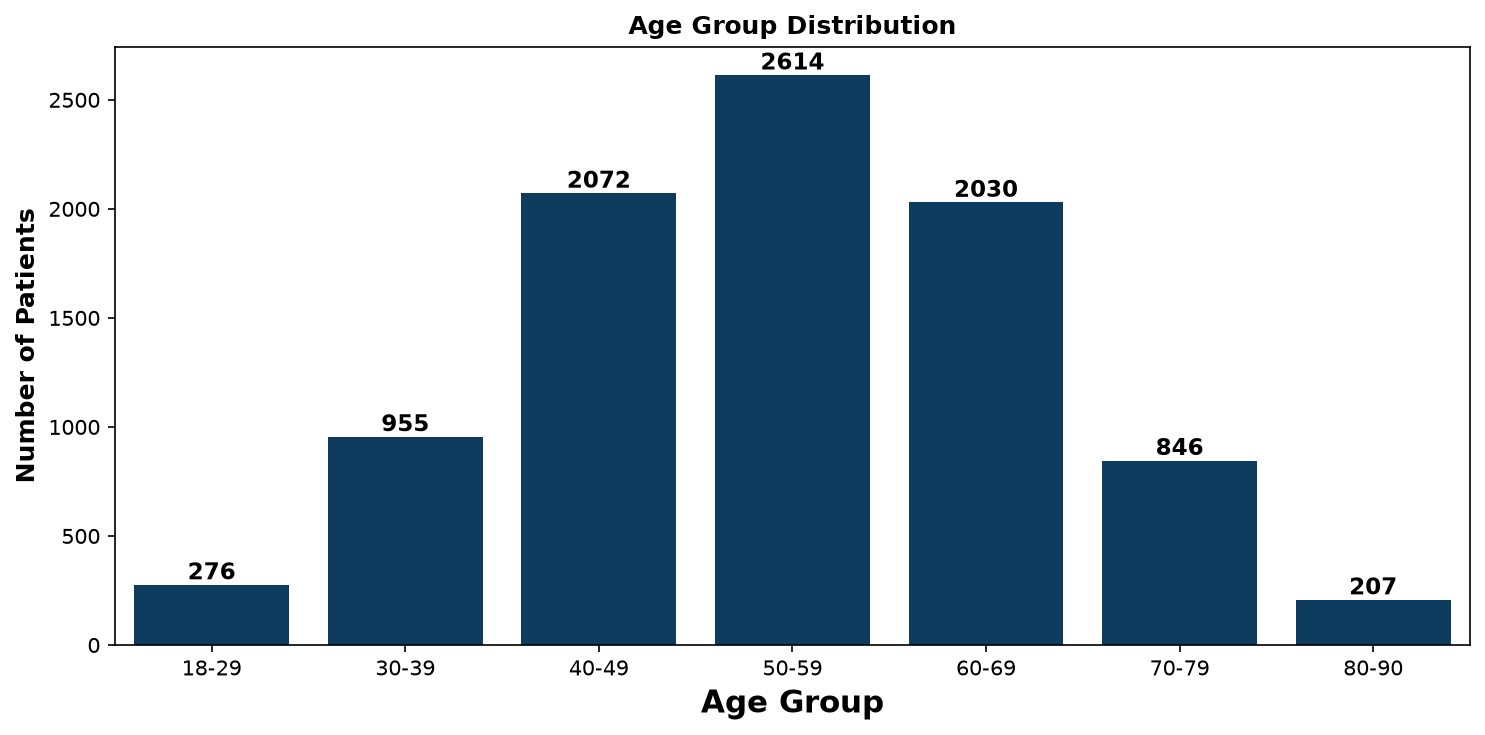

In [21]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=age_group, color="#013e6c")

ax.bar_label(ax.containers[0], fontsize=11, fontweight="bold")

plt.xlabel("Age Group", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=12, fontweight="bold")
plt.title("Age Group Distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

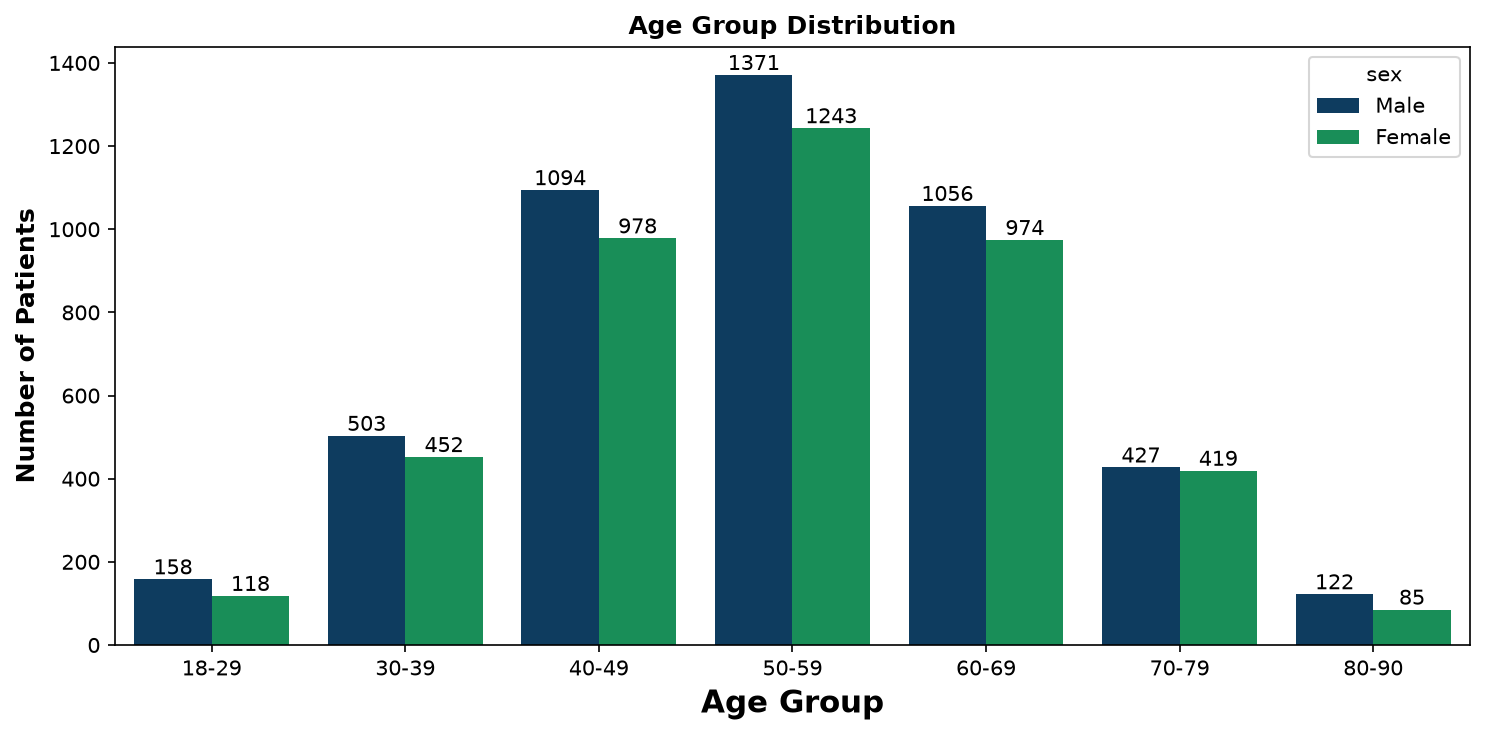

In [22]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=age_group, hue=df["sex"], palette= ["#013e6c", "#06A159"])

plt.xlabel("Age Group", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=12, fontweight="bold")
plt.title("Age Group Distribution", fontsize=12, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
We decided to separate our respondents into various age categories, making the bin size 10. We see that most of the respondents fall into category 4, that is the ages of 50-59. Following is the age group 40-49, then comes middle-aged people falling into 60-69 years old. Then comes the rest of the respondents, falling into various bins. 
</p> 
</div>

* #### Resting BP Systolic

In [23]:
df["resting_bp_systolic"].describe()

count    9000.000000
mean      127.849778
std        13.767233
min        85.000000
25%       119.000000
50%       128.000000
75%       137.000000
max       181.000000
Name: resting_bp_systolic, dtype: float64

In [24]:
df["resting_bp_systolic"].dtype

dtype('int64')

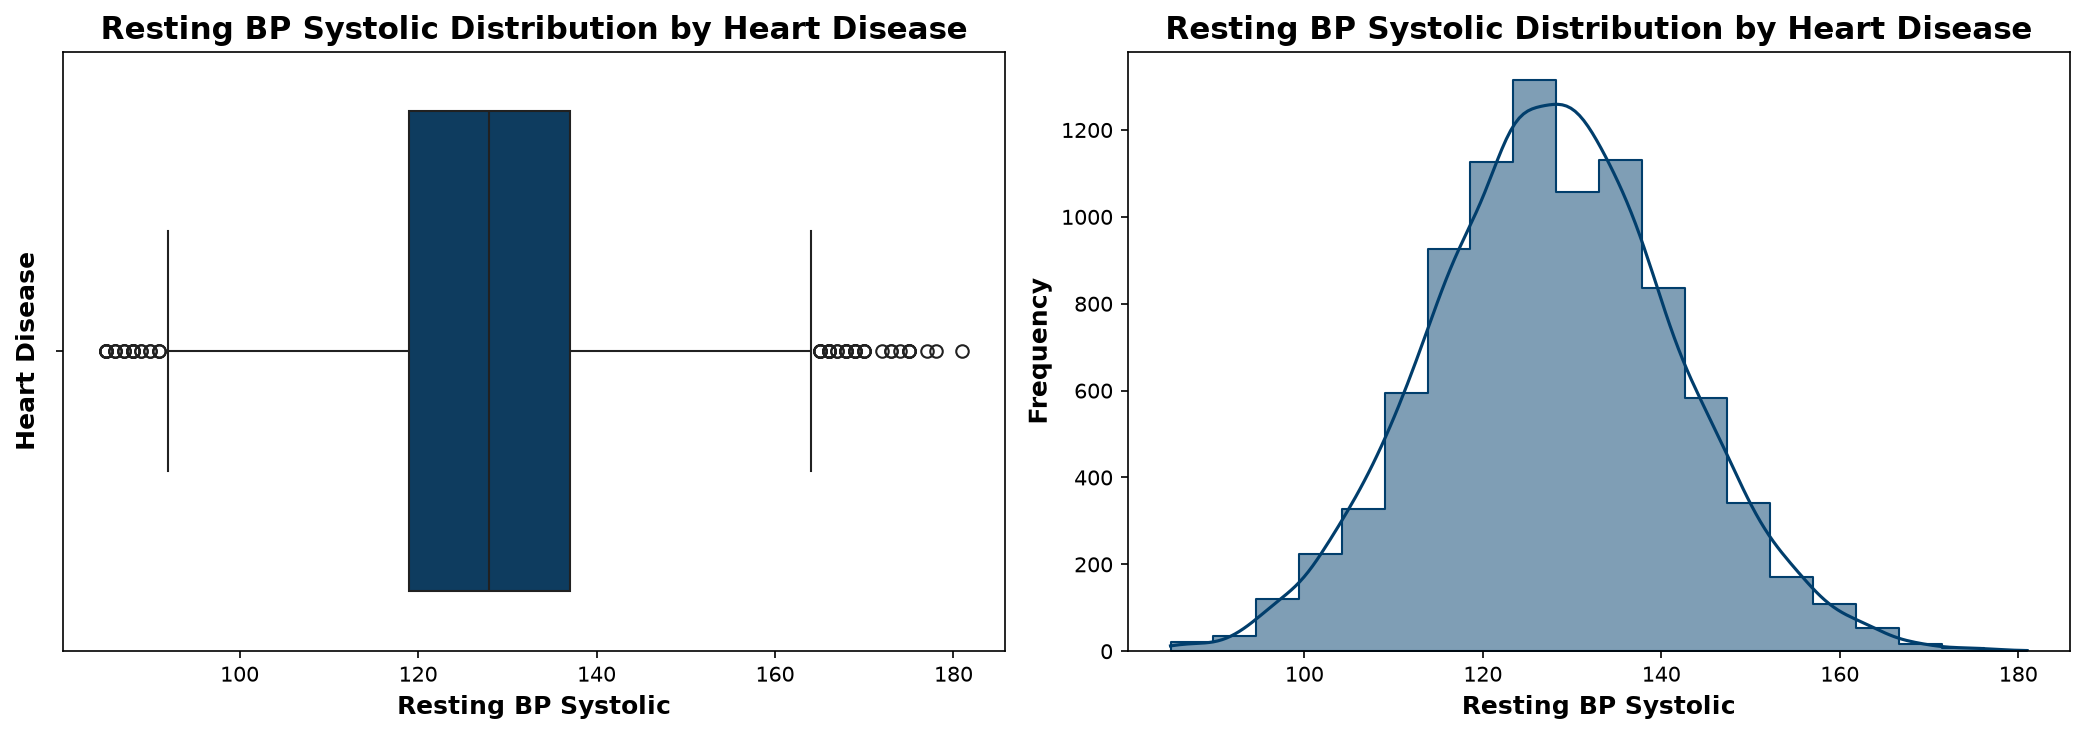

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="resting_bp_systolic", ax=axes[0], color="#013e6c")

axes[0].set_title("Resting BP Systolic Distribution by Heart Disease", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Resting BP Systolic", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="resting_bp_systolic", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Resting BP Systolic Distribution by Heart Disease", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Resting BP Systolic", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [26]:
df["resting_bp_systolic"].skew()

np.float64(0.06768580883603728)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Resting Systolic Blood Pressure distribution is approximately symmetric, with a very slight positive (right) skewness of 0.068. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The Resting BP Systolic of the people varies from 85 mmHg to 181 mmHg, with a mean of 127.84 mmHg and a standard deviation of 13.76. The median value is 128 mmHg.
</p> 
</div>

In [27]:
values = np.array(df['resting_bp_systolic'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 92.0000 or greater than 164.0000
There are 66 outliers.


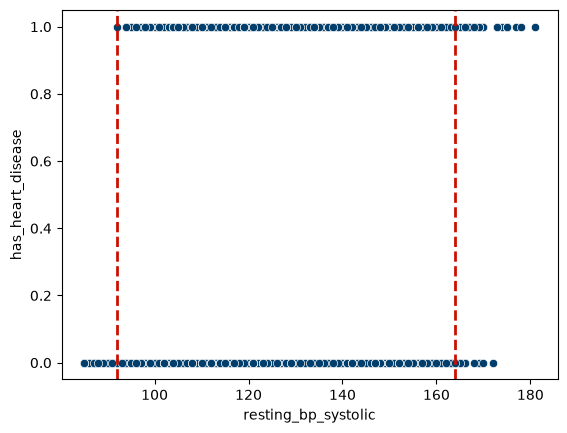

In [28]:
sns.scatterplot(data=data, x="resting_bp_systolic", y="has_heart_disease", color="#013e6c")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Lower: {lower_bound:.2f}", color="#ca1100")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Based on the IQR statistical method, 66 data points were identified as outliers (Outlier). However, these values do not necessarily indicate errors or invalid data; unusual diastolic blood pressure values, whether low or high, may be observed in different individuals and in the real world. Therefore, given the medical nature of the data, these values were not removed and were retained in the analyses.
</p> 
</div>

* #### Resting BP Diastolic

In [29]:
df["resting_bp_diastolic"].describe()

count    9000.000000
mean       80.788778
std        10.939943
min        50.000000
25%        74.000000
50%        81.000000
75%        88.000000
max       126.000000
Name: resting_bp_diastolic, dtype: float64

In [30]:
df["resting_bp_diastolic"].dtype

dtype('int64')

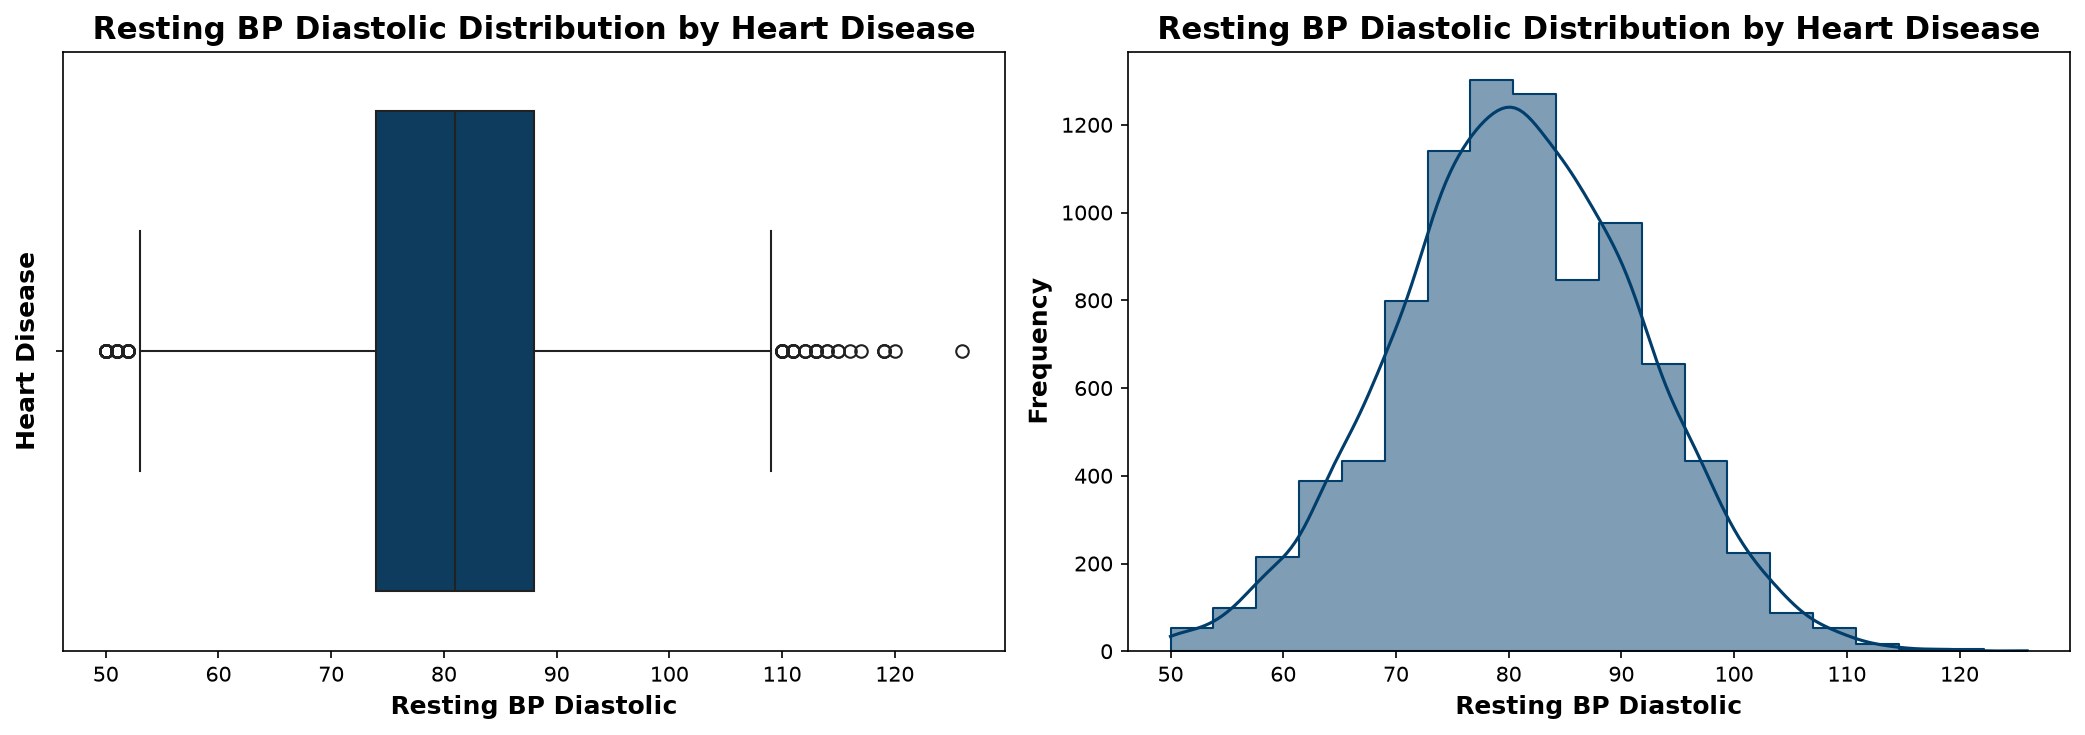

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="resting_bp_diastolic", ax=axes[0], color="#013e6c")

axes[0].set_title("Resting BP Diastolic Distribution by Heart Disease", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Resting BP Diastolic", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="resting_bp_diastolic", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Resting BP Diastolic Distribution by Heart Disease", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Resting BP Diastolic", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [32]:
df["resting_bp_diastolic"].skew()

np.float64(0.008613834944573724)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Resting Diastolic Blood Pressure distribution is approximately symmetric, with a very slight positive (right) skewness of 0.009. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The Resting BP Diastolicof the people varies from 50 mmHg to 126 mmHg, with a mean of 80.78 mmHg and a standard deviation of 10.93. The median value is 81 mmHg.
</p> 
</div>

In [33]:
values = np.array(df['resting_bp_diastolic'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 53.0000 or greater than 109.0000
There are 75 outliers.


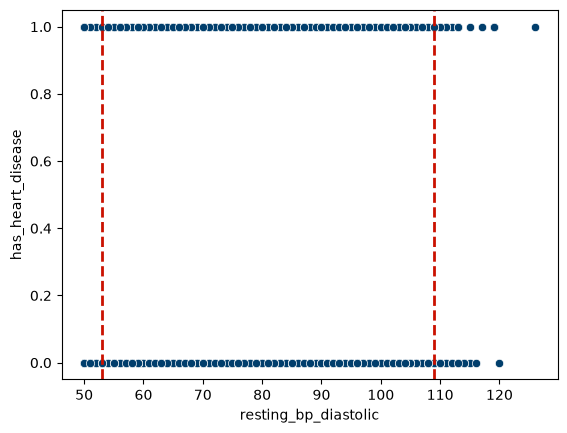

In [34]:
sns.scatterplot(data=data, x="resting_bp_diastolic", y="has_heart_disease", color="#013e6c")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Lower: {lower_bound:.2f}", color="#ca1100")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Based on the IQR statistical method, 75 data points were identified as outliers (Outlier). However, these values do not necessarily indicate errors or invalid data; unusual diastolic blood pressure values, whether low or high, may be observed in different individuals and in the real world. Therefore, given the medical nature of the data, these values were not removed and were retained in the analyses.
</p> 
</div>

In [35]:
def get_bp_category(row):
    systolic = row["resting_bp_systolic"]
    diastolic = row["resting_bp_diastolic"]

    if systolic > 180 or diastolic > 120:
        return "Hypertensive Crisis"

    elif systolic >= 140 or diastolic >= 90:
        return "Hypertension Stage 2"

    elif systolic >= 130 or diastolic >= 80:
        return "Hypertension Stage 1"

    elif systolic >= 120 and diastolic < 80:
        return "Elevated"

    else:
        return "Normal"

In [36]:
bp_category = df.apply(get_bp_category, axis=1)

In [37]:
bp_category.value_counts()

Hypertension Stage 1    3015
Hypertension Stage 2    2525
Normal                  2093
Elevated                1365
Hypertensive Crisis        2
Name: count, dtype: int64

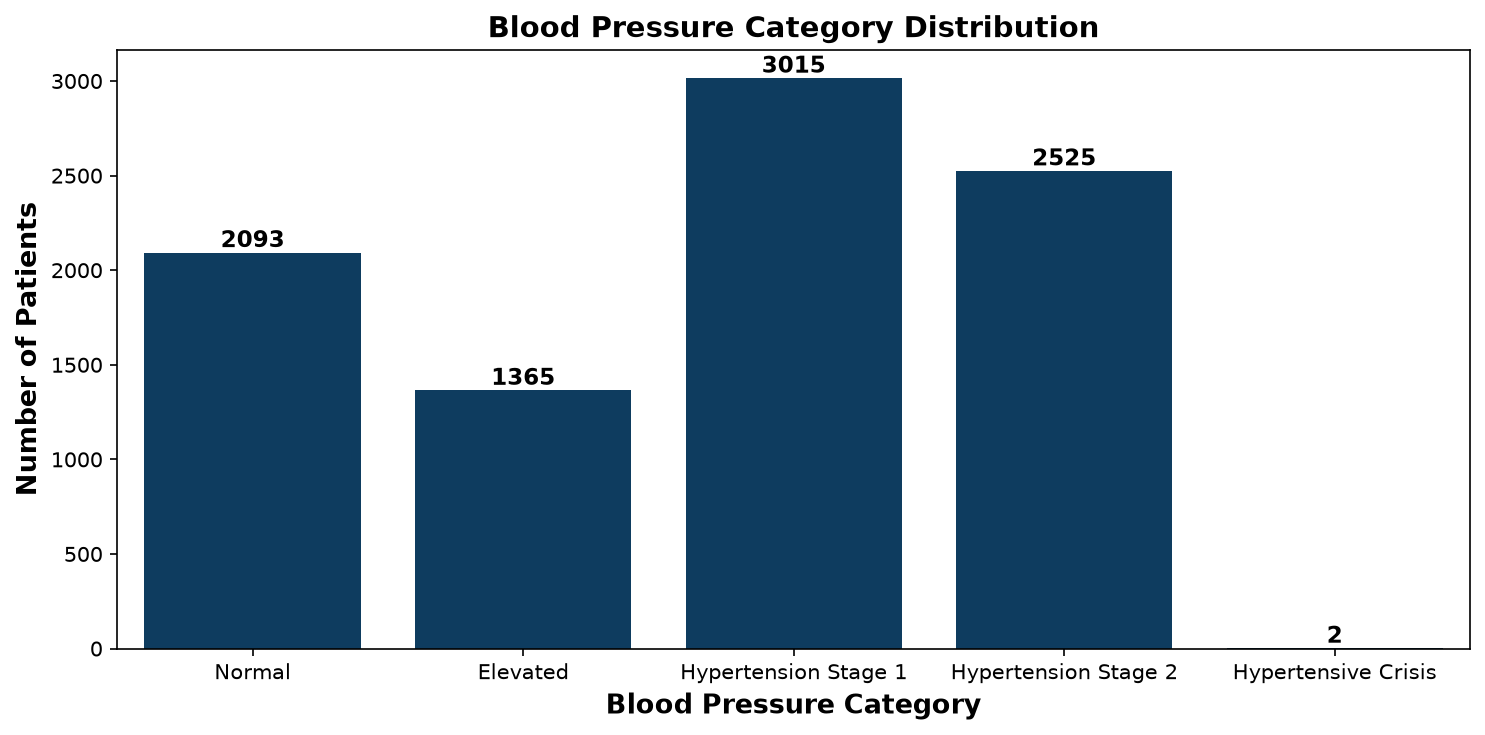

In [38]:
order = ["Normal", "Elevated", "Hypertension Stage 1", "Hypertension Stage 2", "Hypertensive Crisis"]

plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=bp_category, order=order, color="#013e6c")

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold")

plt.xlabel("Blood Pressure Category", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("Blood Pressure Category Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
An examination of the distribution of blood pressure categories shows that the largest number of individuals, with 3015 samples, are in the stage 1 hypertension group. Following this, 2525 samples are in the stage 2 hypertension group. In addition, 2093 samples have normal blood pressure, and 1365 samples fall within the elevated range. Only 2 samples were identified in the hypertensive crisis group, indicating a very low prevalence of this condition in the dataset. Overall, a considerable proportion of the samples fall into the stage 1 and stage 2 hypertension categories, indicating that high blood pressure is relatively common in this dataset.
</p> 
</div>

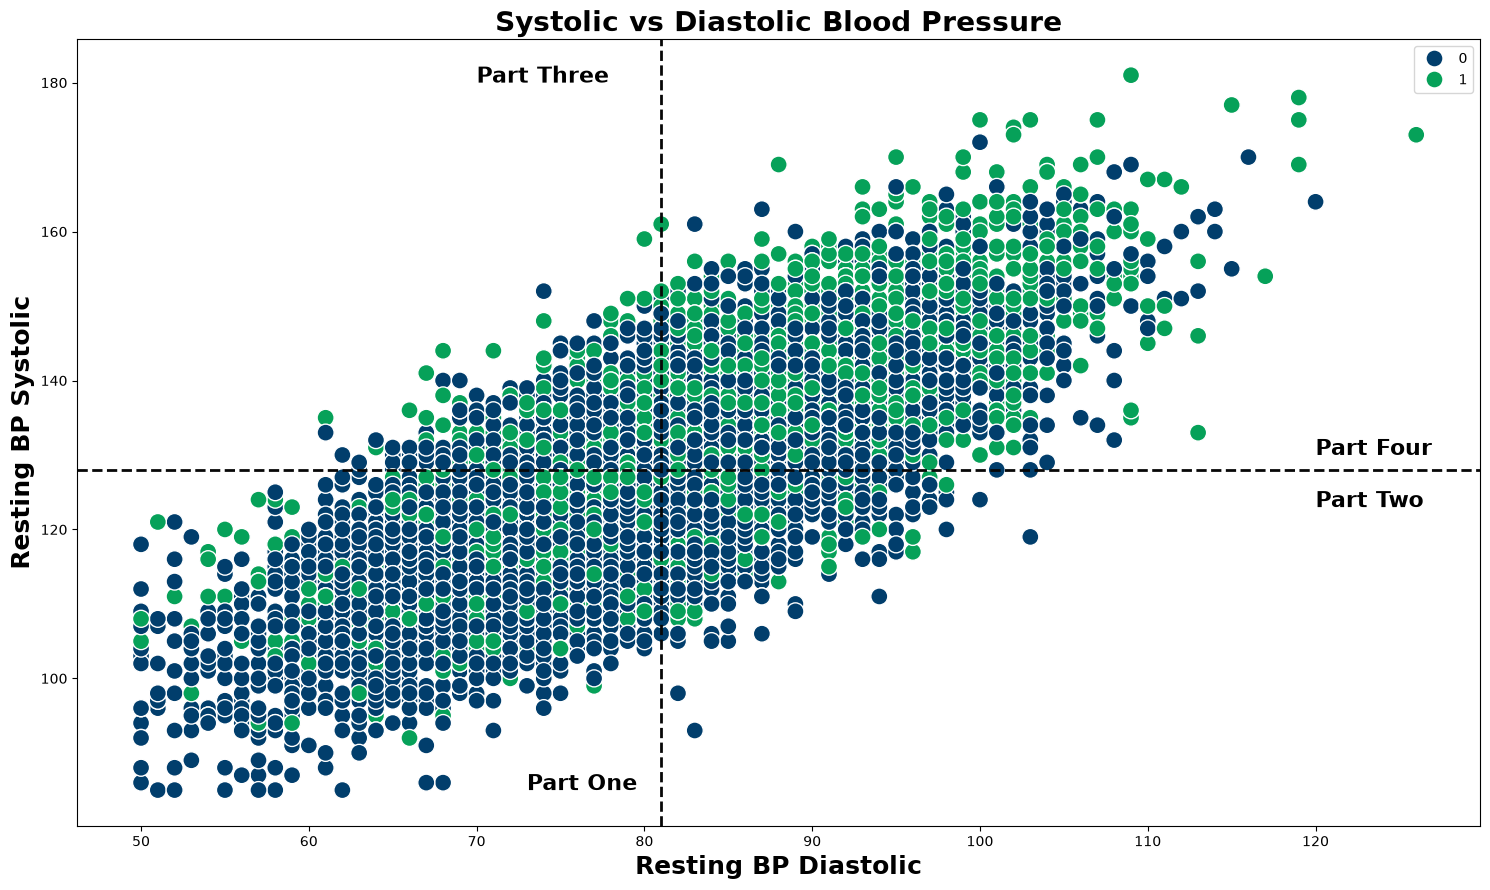

In [39]:
plt.figure(figsize=(15, 9), dpi=100)
sns.scatterplot(data=df, x="resting_bp_diastolic", y="resting_bp_systolic", hue="has_heart_disease", s=150, palette=["#013e6c", "#06A159"])

# Diastolic IQR Bounds
plt.axvline(x= 81, linestyle="--", linewidth=2, color="#070707")

# Systolic IQR Bounds
plt.axhline(y= 128, linestyle="--", linewidth=2, color="#070707")

# text
plt.text(x=73, y=85, s="Part One", color="black", fontsize=16, fontweight="bold")
plt.text(x=120, y=123, s="Part Two", color="black", fontsize=16, fontweight="bold")
plt.text(x=70, y=180, s="Part Three", color="black", fontsize=16, fontweight="bold")
plt.text(x=120, y=130, s="Part Four", color="black", fontsize=16, fontweight="bold")

plt.xlabel("Resting BP Diastolic", fontsize=18, fontweight="bold")
plt.ylabel("Resting BP Systolic", fontsize=18, fontweight="bold")

plt.title("Systolic vs Diastolic Blood Pressure", fontsize=20, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
We divided the chart into four sections using the median of each column.
It was then found that the largest distribution of the data is in sections one and four.
The most important section for us is section four, where we have the highest number of sick individuals, which corresponds to an increase in the values of both features.
</p> 
</div>

* #### lipid_features

In [40]:
lipid_features = ["cholesterol_total", "hdl", "ldl", "triglycerides"]

In [41]:
df[lipid_features].describe()

,cholesterol_total,hdl,ldl,triglycerides
count,9000.000000,9000.000000,9000.000000,9000.000000
mean,188.753556,55.215333,103.275556,152.045000
std,32.271644,12.394400,27.342198,51.448384
min,90.000000,18.000000,35.000000,35.000000
25%,167.000000,47.000000,85.000000,117.000000
50%,189.000000,55.000000,103.000000,151.000000
75%,211.000000,64.000000,122.000000,186.000000
max,314.000000,110.000000,207.000000,390.000000


In [42]:
df[lipid_features].dtypes

cholesterol_total    int64
hdl                  int64
ldl                  int64
triglycerides        int64
dtype: object

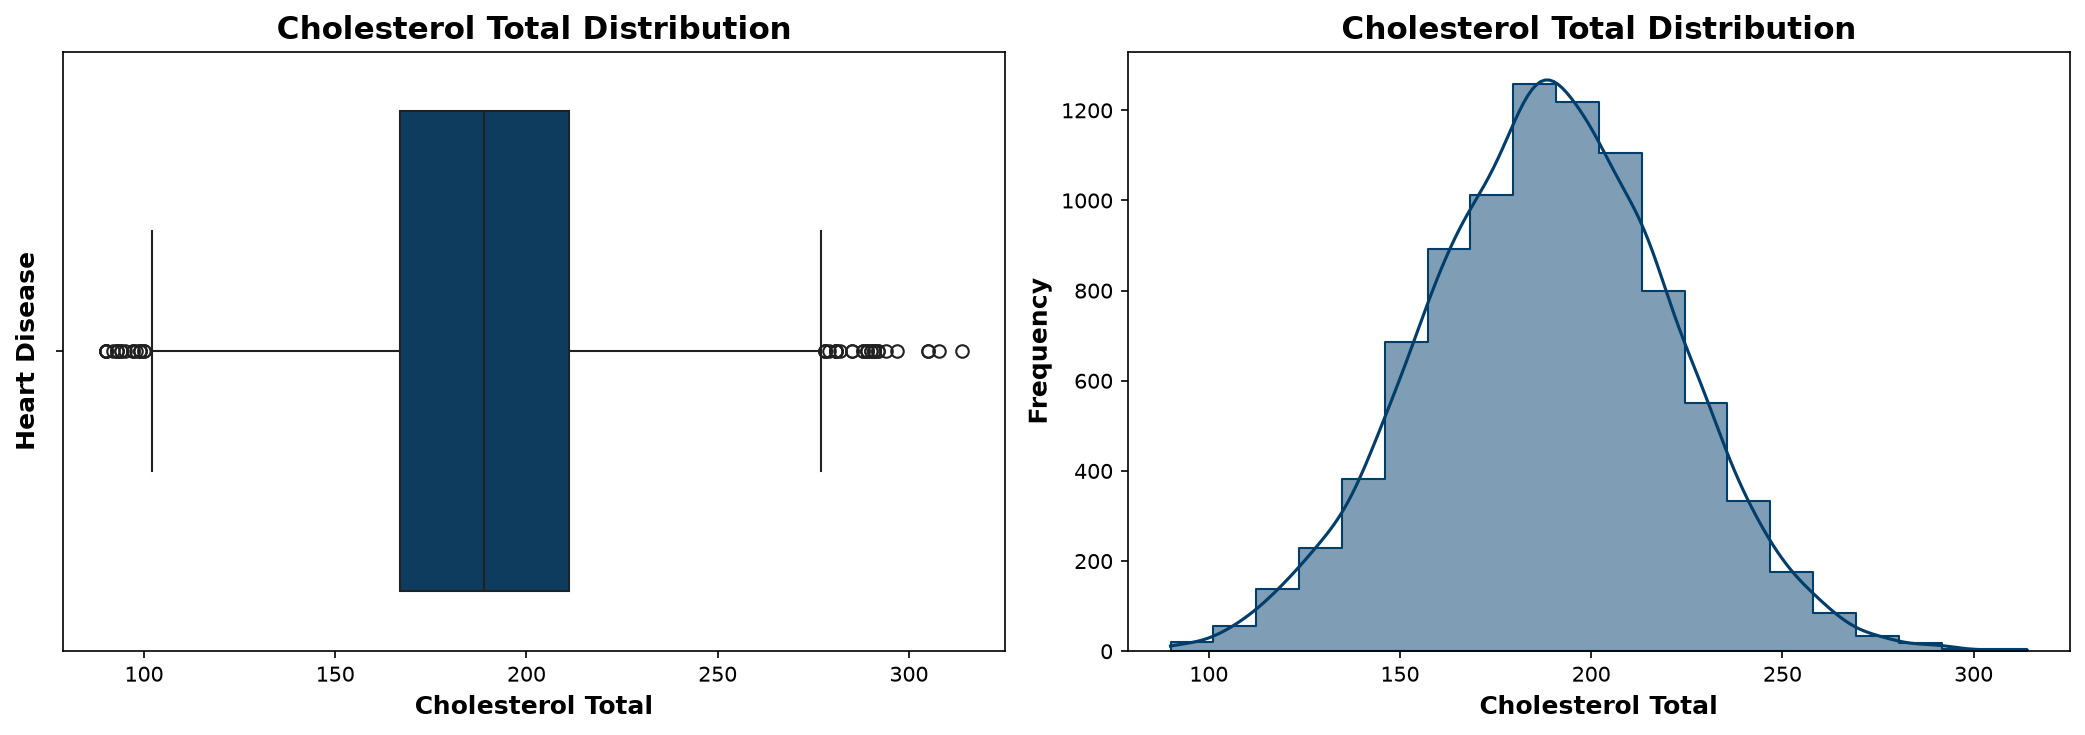

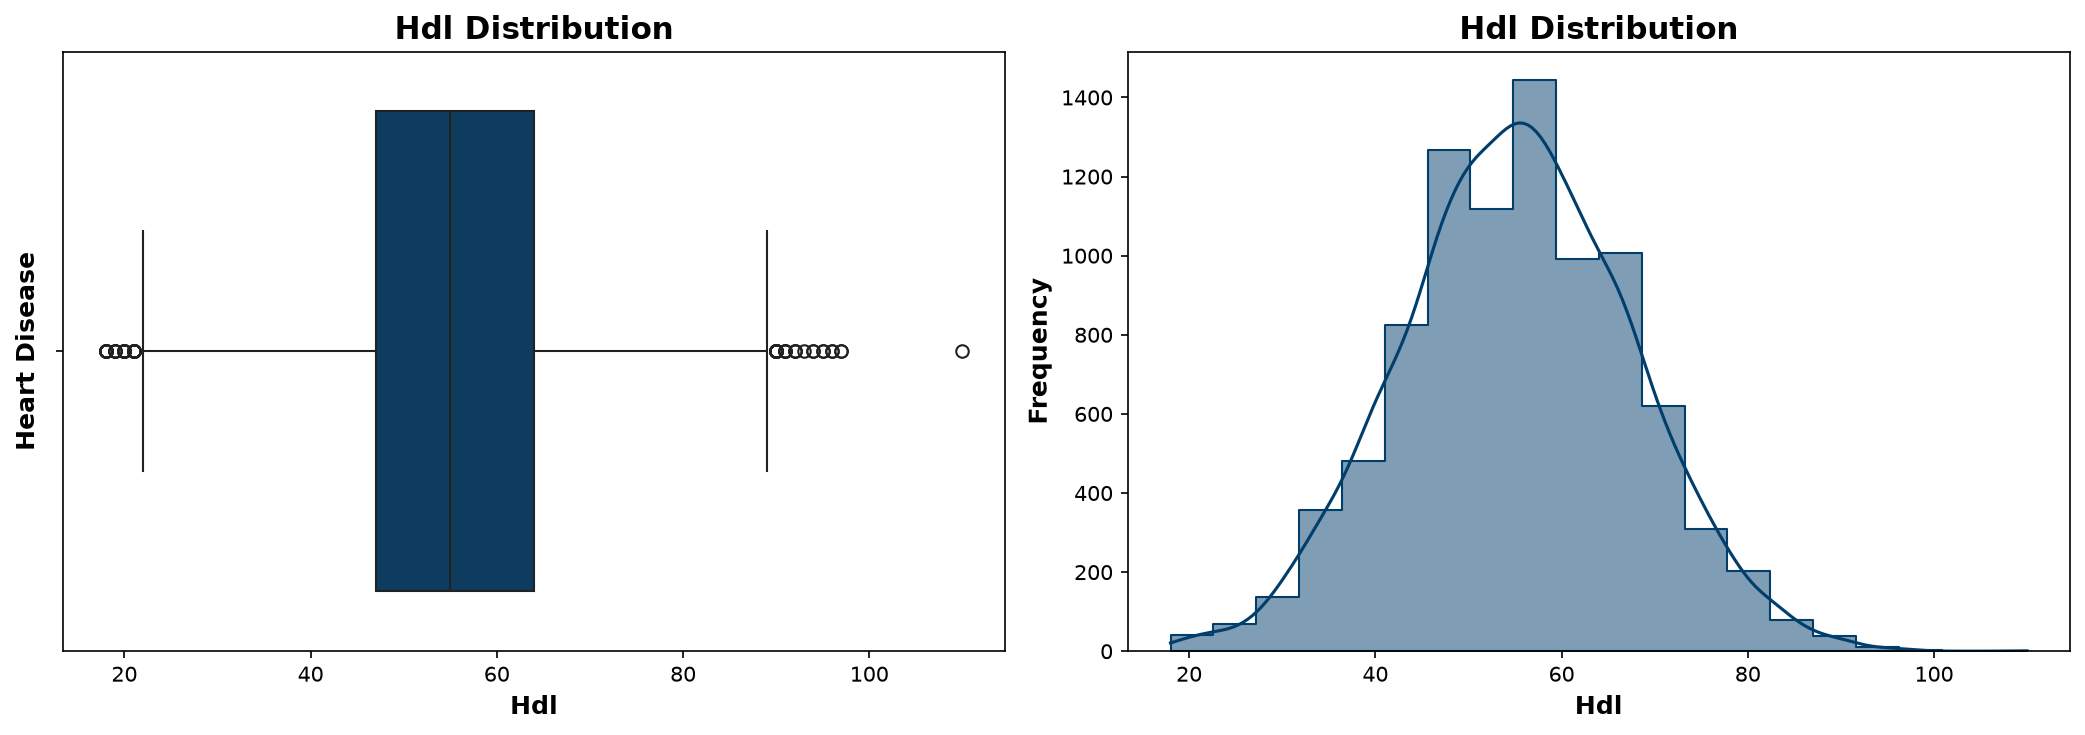

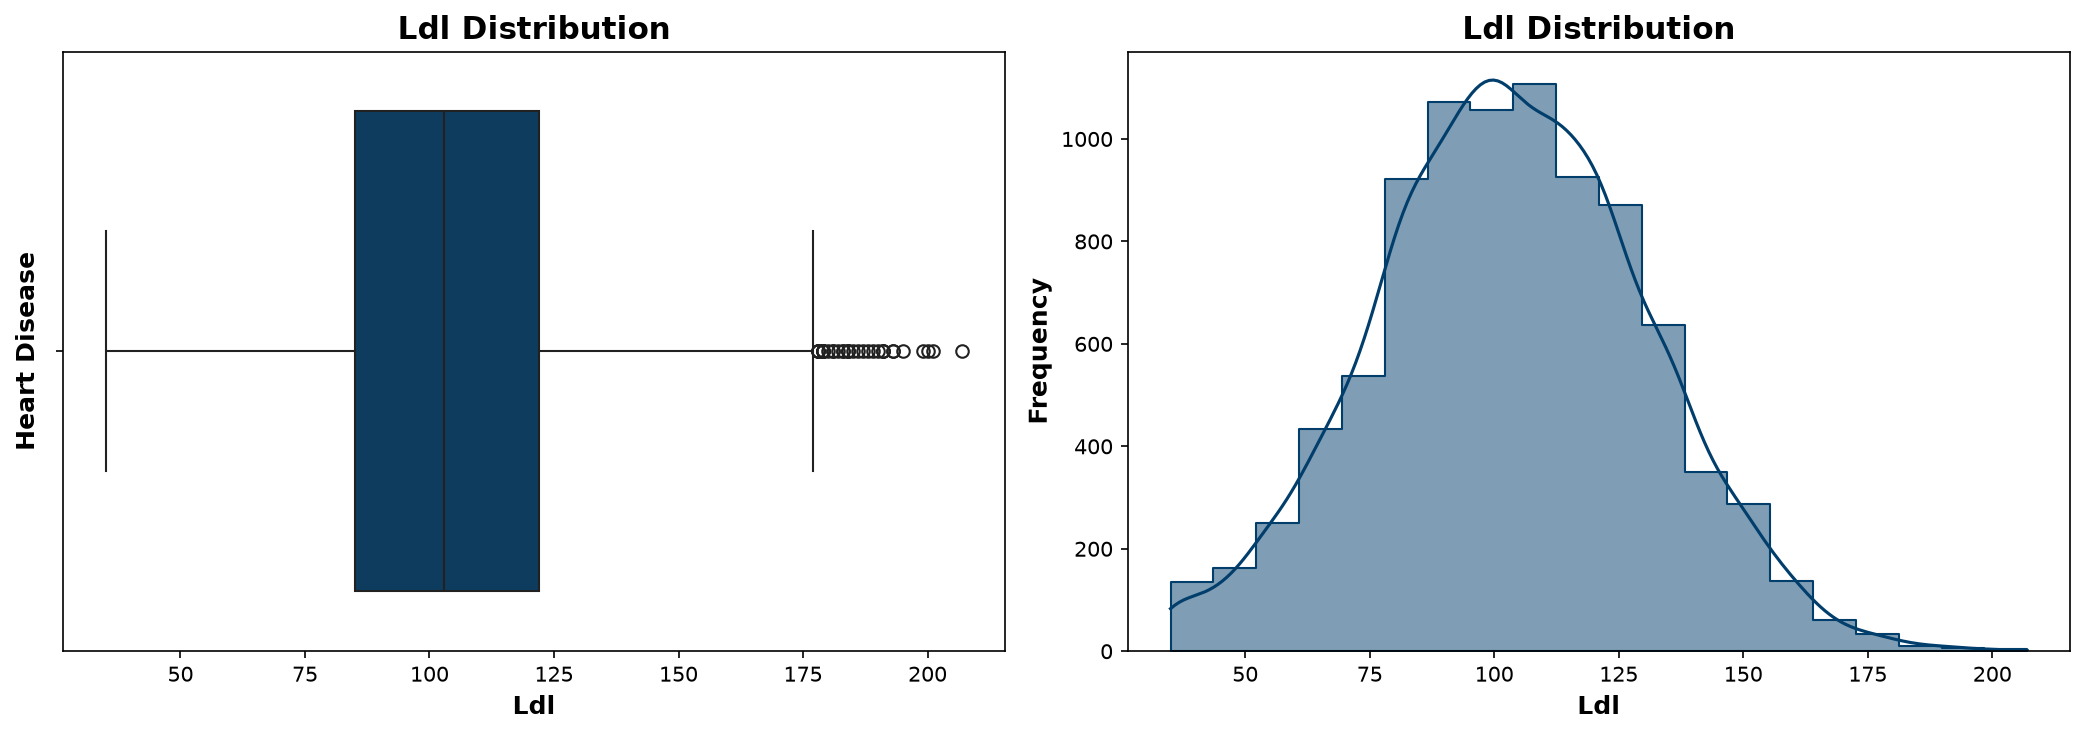

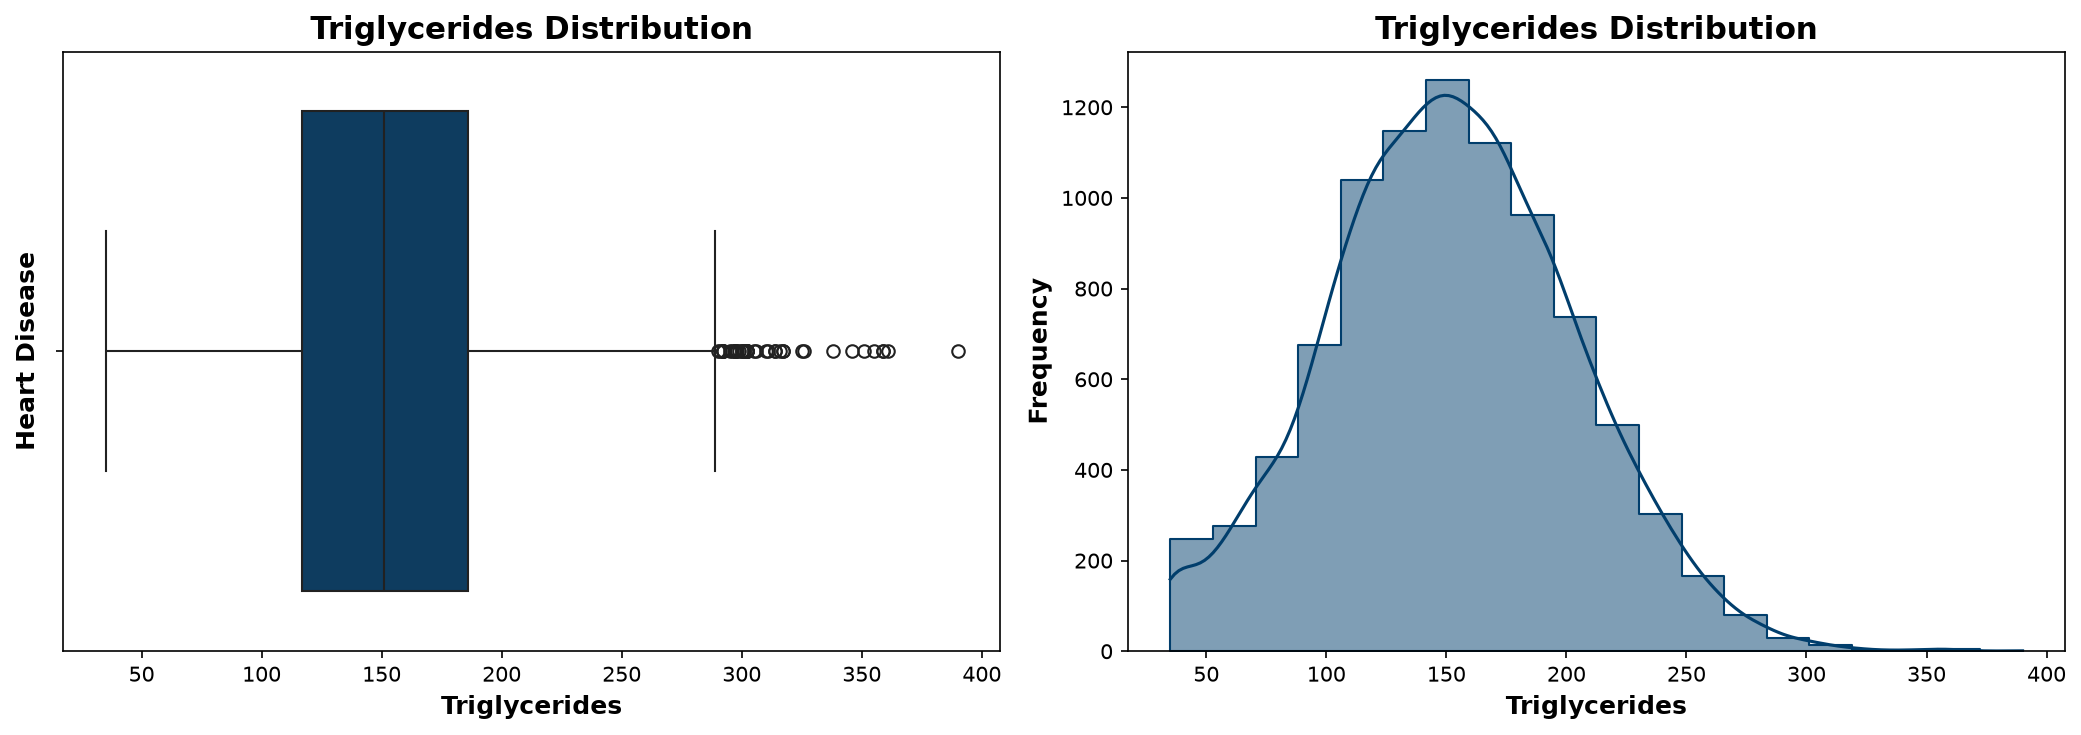

In [43]:
for feature in lipid_features:
    display_name = feature.replace("_", " ").title()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    # ================= Boxplot =================
    sns.boxplot(data=data, x=feature, ax=axes[0], color="#013e6c")

    axes[0].set_title(f"{display_name} Distribution", fontsize=15, fontweight="bold")
    axes[0].set_xlabel(display_name, fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

    # ================= Histogram =================
    sns.histplot(data=data, x=feature, bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

    axes[1].set_title(f"{display_name} Distribution", fontsize=15, fontweight="bold")
    axes[1].set_xlabel(display_name, fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

In [44]:
df[lipid_features].skew()

cholesterol_total    0.003850
hdl                  0.020459
ldl                  0.044963
triglycerides        0.125859
dtype: float64

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
All four lipid-related features have approximately symmetric distributions, with very slight positive skewness.

The cholesterol level of individuals has a mean of 188.75 mg/dL with a standard deviation of 32.27. The minimum is 90 mg/dL and the maximum is 314 mg/dL.

The LDL level of the individuals has a mean of 103.27 mg/dL with a standard deviation of 27.34. The minimum is 35 mg/dL and the maximum is 207 mg/dL.

The HDL level of the individuals has a mean of 55.21 mg/dL with a standard deviation of 12.39. The minimum is 18 mg/dL and the maximum is 110 mg/dL.

The triglycerides level of the individuals has a mean of 152 mg/dL with a standard deviation of 51.44. The minimum is 35 mg/dL and the maximum is 390 mg/dL.
</p> 
</div>

In [45]:
for feature in lipid_features:
    values = df[feature].dropna().to_numpy()
    percentile1, percentile2 = np.percentile(values, [25, 75])
    
    bound = percentile2 - percentile1
    lower_bound = percentile1 - 1.5 * bound
    upper_bound = percentile2 + 1.5 * bound

    outliers = values[(values < lower_bound) |  (values > upper_bound)]

    print("=" * 50)
    print(f"Feature: {feature}")
    print(f"Lower Limit: {lower_bound:.2f}")
    print(f"Upper Limit: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

Feature: cholesterol_total
Lower Limit: 101.00
Upper Limit: 277.00
Number of Outliers: 50
Feature: hdl
Lower Limit: 21.50
Upper Limit: 89.50
Number of Outliers: 63
Feature: ldl
Lower Limit: 29.50
Upper Limit: 177.50
Number of Outliers: 34
Feature: triglycerides
Lower Limit: 13.50
Upper Limit: 289.50
Number of Outliers: 42


<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, outlier values were identified in four lipid indices. In the cholesterol_total column, 50 values, in hdl, 63 values, in ldl, 34 values, and in triglycerides, 42 values were identified as Outliers.

However, identifying these values using the IQR method merely indicates that they are statistically unusual relative to the distribution of the data and does not necessarily mean that the values are incorrect or unrealistic. Lipid indices can fall within different ranges across individuals, and high or low values can also be observed from a medical perspective.

Therefore, given that these values are acceptable in terms of the data range and do not necessarily indicate data entry errors, the outliers were not removed and were retained in the analysis and modeling.
</p> 
</div>

In [46]:
cholesterol_group = pd.cut(data["cholesterol_total"], bins=[-np.inf, 200, 240, np.inf],
    labels=[
        "Desirable\n(< 200 mg/dL)",
        "Borderline High\n(200–239 mg/dL)",
        "High\n(≥ 240 mg/dL)"
    ], right=False)

In [47]:
cholesterol_group.value_counts()

cholesterol_total
Desirable\n(< 200 mg/dL)            5673
Borderline High\n(200–239 mg/dL)    2816
High\n(≥ 240 mg/dL)                  511
Name: count, dtype: int64

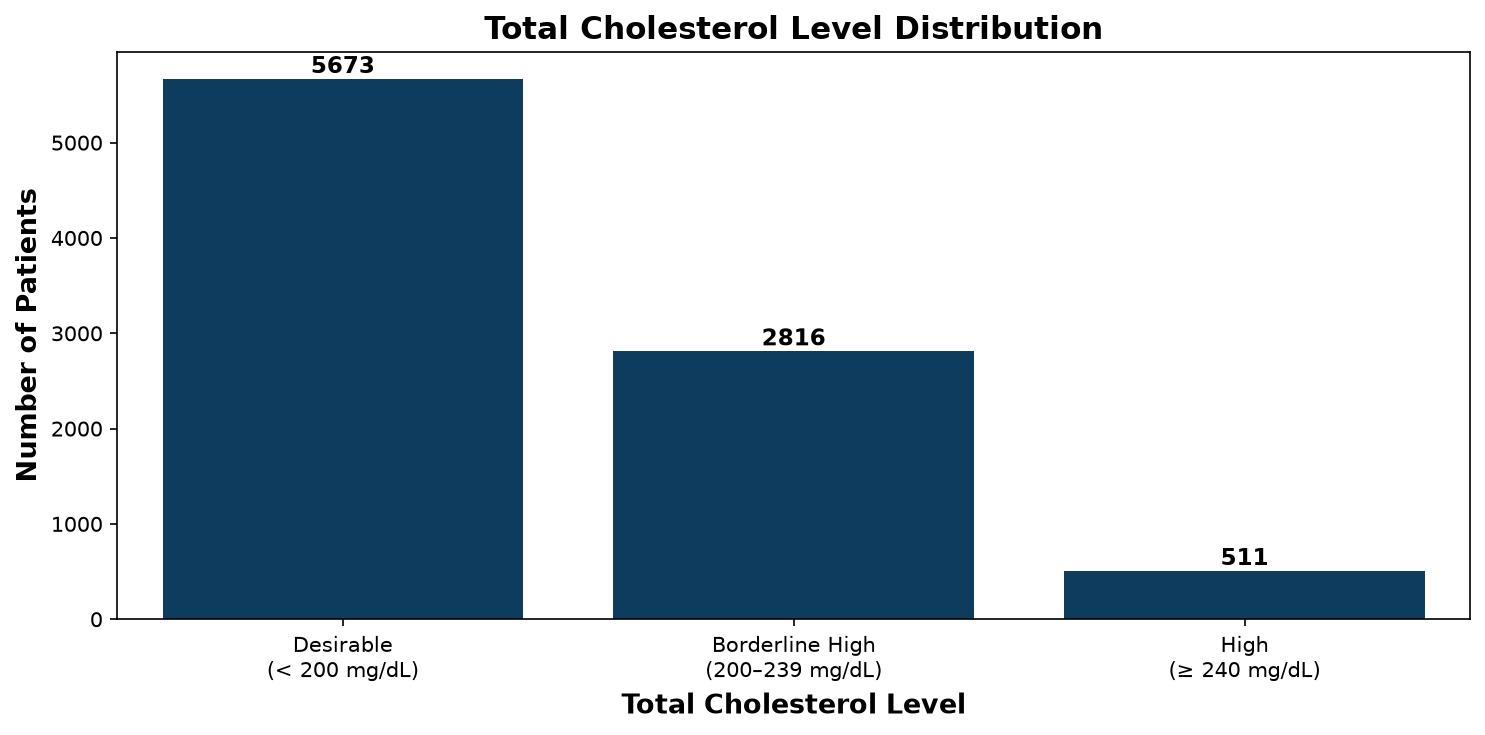

In [48]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=cholesterol_group, color="#013e6c")

plt.xlabel("Total Cholesterol Level", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("Total Cholesterol Level Distribution", fontsize=15, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Of the 9,000 samples:

5673 people (63.0٪) are in the desirable range, meaning less than 200 mg/dL.
2816 people (31.3٪) are in the Borderline High range.
511 people (5.7٪) have Total Cholesterol equal to or greater than 240 mg/dL and are in the High group.

 Most people are in the desirable range, but about 37٪ of the samples are above the desirable range
</p> 
</div>

In [49]:
ldl_group = pd.cut(data["ldl"], bins=[-np.inf, 100, 130, 160, 190, np.inf],
    labels=[
        "Optimal\n(< 100 mg/dL)",
        "Near Optimal\n(100–129 mg/dL)",
        "Borderline High\n(130–159 mg/dL)",
        "High\n(160–189 mg/dL)",
        "Very High\n(≥ 190 mg/dL)"
    ], right=False)

In [50]:
ldl_group.value_counts()

ldl
Optimal\n(< 100 mg/dL)              4052
Near Optimal\n(100–129 mg/dL)       3423
Borderline High\n(130–159 mg/dL)    1347
High\n(160–189 mg/dL)                167
Very High\n(≥ 190 mg/dL)              11
Name: count, dtype: int64

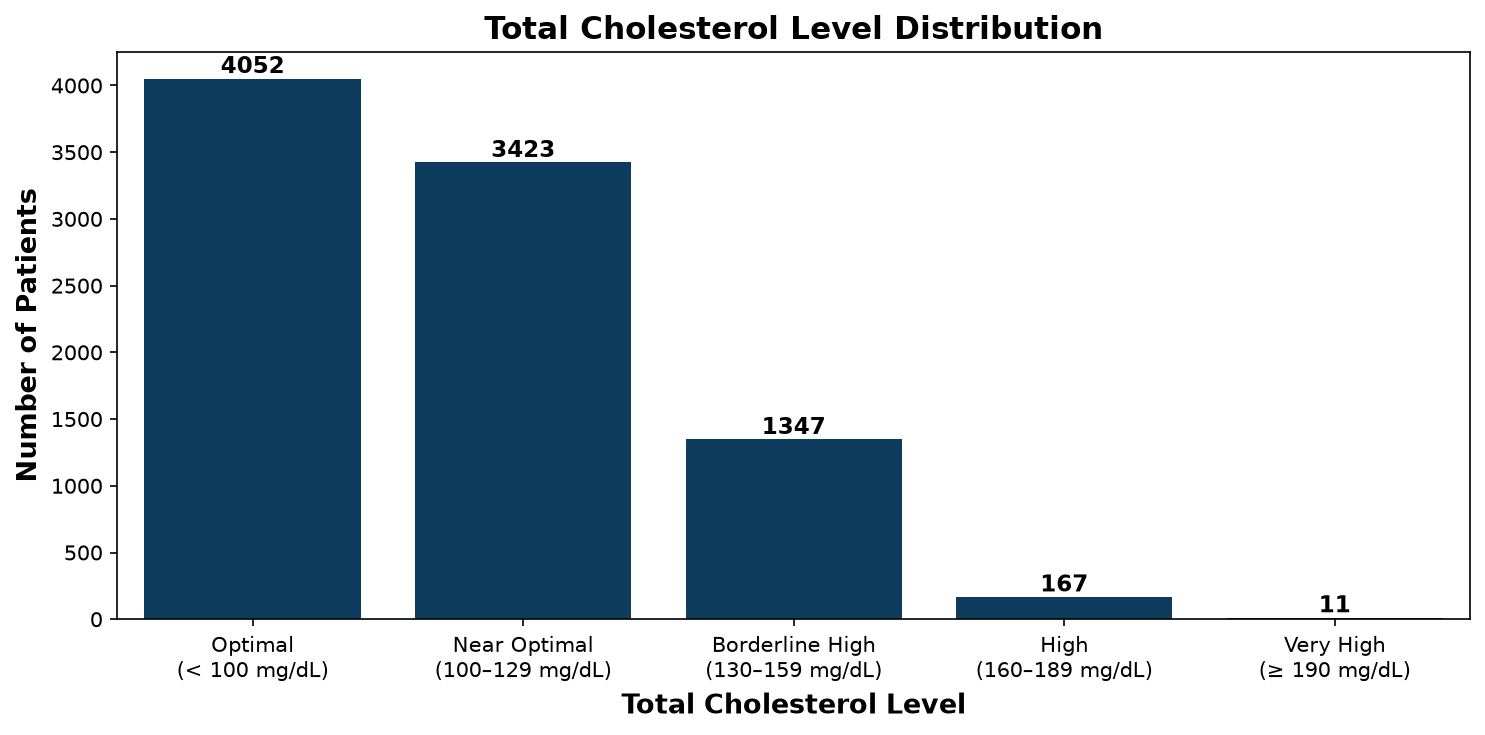

In [51]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=ldl_group, color="#013e6c")

plt.xlabel("Total Cholesterol Level", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("Total Cholesterol Level Distribution", fontsize=15, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
4052 people (45.0٪) are in the Optimal range.

3423 people (38.0٪) are in the Near Optimal range.

1347 people (15.0٪) are in the Borderline High range.

167 people (1.9٪) are in the High range.

11 people (0.1٪) are in the Very High range.

About 83٪ of the individuals fall into the Optimal and Near Optimal groups. Only a small portion of the samples have very high LDL.
</p> 
</div>

In [52]:
def hdl_category(row):
    hdl = row["hdl"]
    sex = row["sex"]

    if sex == "Male":  
        if hdl < 40:
            return "Low"
        elif hdl < 60:
            return "Acceptable"
        else:
            return "Optimal"

    elif sex == "Female":  
        if hdl < 50:
            return "Low"
        elif hdl < 60:
            return "Acceptable"
        else:
            return "Optimal"

In [53]:
hdl_group = data.apply(hdl_category, axis=1)
print(pd.crosstab(data["sex"], hdl_group))

col_0   Acceptable   Low  Optimal
sex                              
Female        1318  1005     1946
Male          2769   647     1315


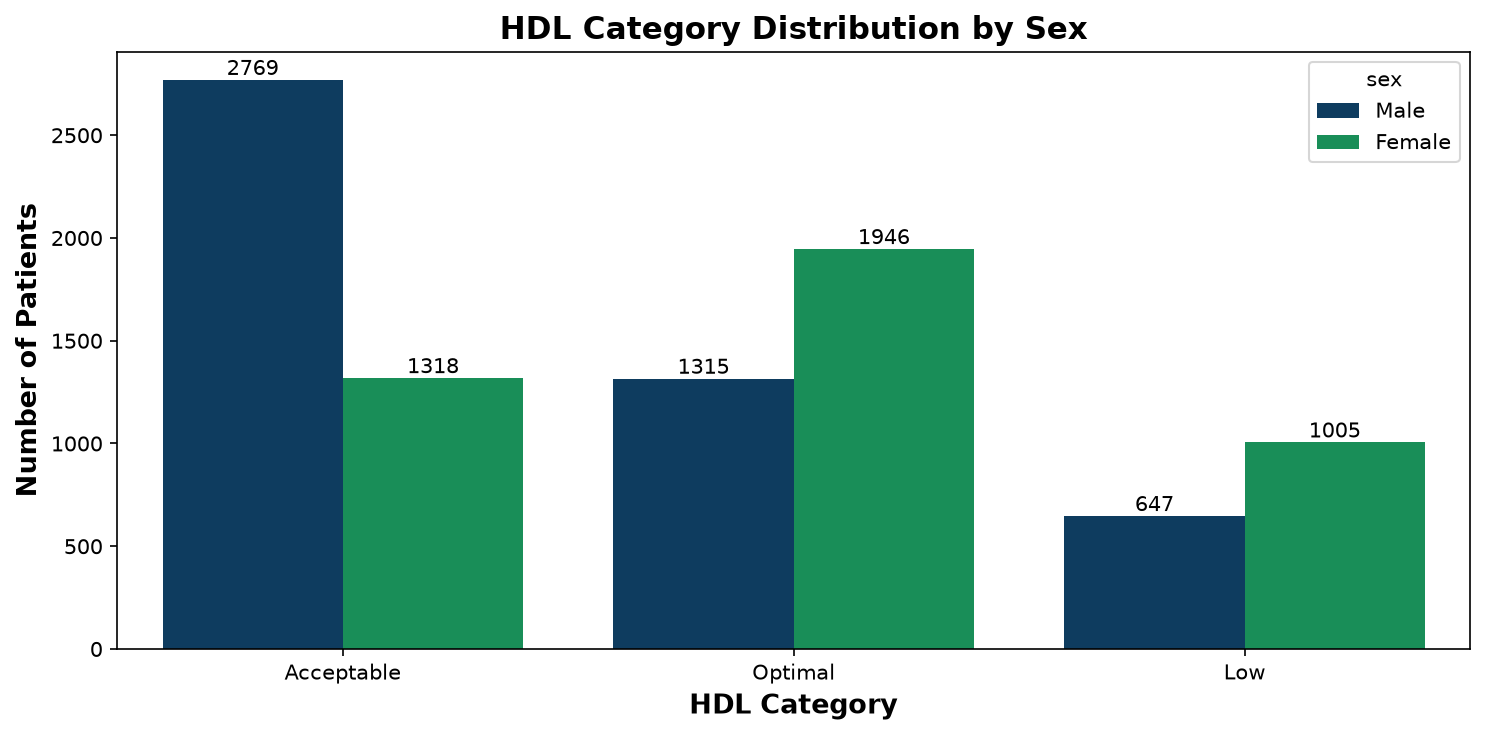

In [54]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=hdl_group, hue=data["sex"].map({"Female": "Female", "Male": "Male"}), palette=["#013e6c", "#06A159"])

plt.xlabel("HDL Category", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("HDL Category Distribution by Sex", fontsize=15, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The results show that HDL status follows a different pattern in women and men. A substantial proportion of women are within the desirable HDL range, but the number of women with low HDL is also considerable. Among men, most samples fall within the acceptable range. Therefore, in analyzing HDL, it is better to consider sex as an important factor in interpreting this variable.
</p> 
</div>

In [55]:
triglycerides_group = pd.cut(
    data["triglycerides"],
    bins=[-np.inf, 150, 200, 500, np.inf],
    labels=[
        "Normal\n(< 150 mg/dL)",
        "Borderline High\n(150–199 mg/dL)",
        "High\n(200–499 mg/dL)",
        "Very High\n(≥ 500 mg/dL)"
    ],
    right=False
)

In [56]:
triglycerides_group.value_counts()

triglycerides
Normal\n(< 150 mg/dL)               4372
Borderline High\n(150–199 mg/dL)    3048
High\n(200–499 mg/dL)               1580
Very High\n(≥ 500 mg/dL)               0
Name: count, dtype: int64

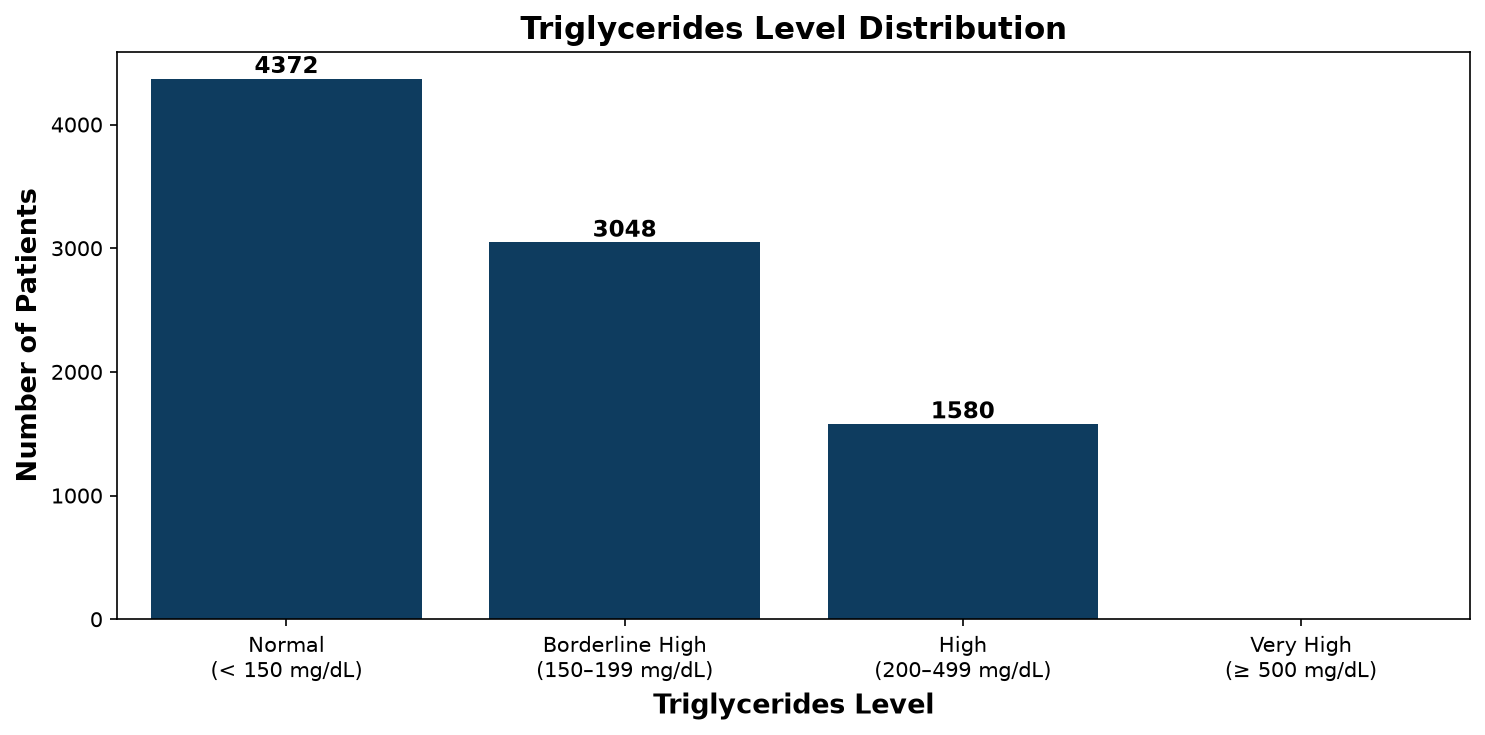

In [57]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(x=triglycerides_group, color="#013e6c")

plt.xlabel("Triglycerides Level", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("Triglycerides Level Distribution", fontsize=15, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Out of a total of 9,000 samples:

4372 people (48.6٪) are in the Normal (< 150 mg/dL) range.

3048 people (33.9٪) are in the Borderline High (150–199 mg/dL) range.

1580 people (17.6٪) are in the High (200–499 mg/dL) range.

0 people are in the Very High (≥ 500 mg/dL) range.

Approximately half of the individuals studied (48.6٪) have triglyceride levels in the normal range. However, 33.9٪ of individuals are in the Borderline High range and 17.6٪ are in the High range. No sample with triglycerides ≥500 mg/dL was observed in this dataset. Therefore, although a considerable proportion of individuals have triglyceride levels above the desirable range, very high values are not present in these data.
</p> 
</div>

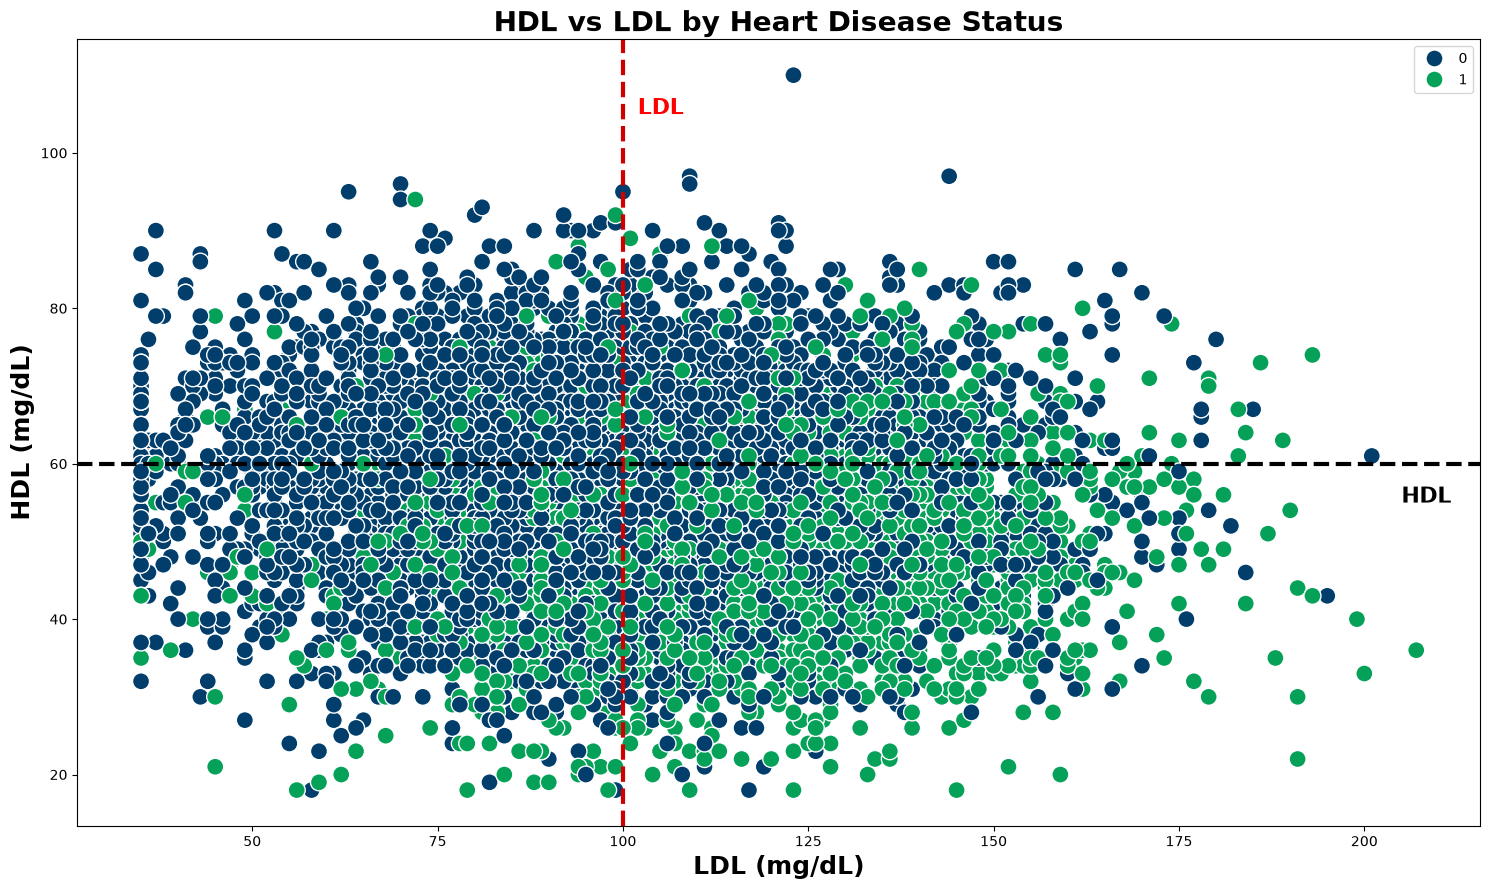

In [58]:
plt.figure(figsize=(15, 9), dpi=100)
sns.scatterplot(data=df, x="ldl", y="hdl", hue="has_heart_disease", s=150, palette=["#013e6c", "#06A159"])


plt.axvline(x= 100, linestyle="--", linewidth=3, color="#D10000")
plt.axhline(y= 60, linestyle="--", linewidth=3, color="#000000")

# text
plt.text(x=205, y=55, s="HDL", color="black", fontsize=16, fontweight="bold")
plt.text(x=102, y=105, s="LDL", color="red", fontsize=16, fontweight="bold")


plt.xlabel("LDL (mg/dL)", fontsize=18, fontweight="bold")
plt.ylabel("HDL (mg/dL)", fontsize=18, fontweight="bold")

plt.title("HDL vs LDL by Heart Disease Status", fontsize=20, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Individuals with heart disease in the dataset are more commonly observed in the low HDL and high LDL region; however, there is considerable overlap between the two groups, and these two variables alone are not sufficient to diagnose heart disease.
</p> 
</div>

* #### Fasting Blood Sugar

In [59]:
df["fasting_blood_sugar"].describe()

count    9000.000000
mean      119.470444
std        22.778082
min        60.000000
25%       104.000000
50%       119.000000
75%       135.000000
max       204.000000
Name: fasting_blood_sugar, dtype: float64

In [60]:
df["fasting_blood_sugar"].dtype

dtype('int64')

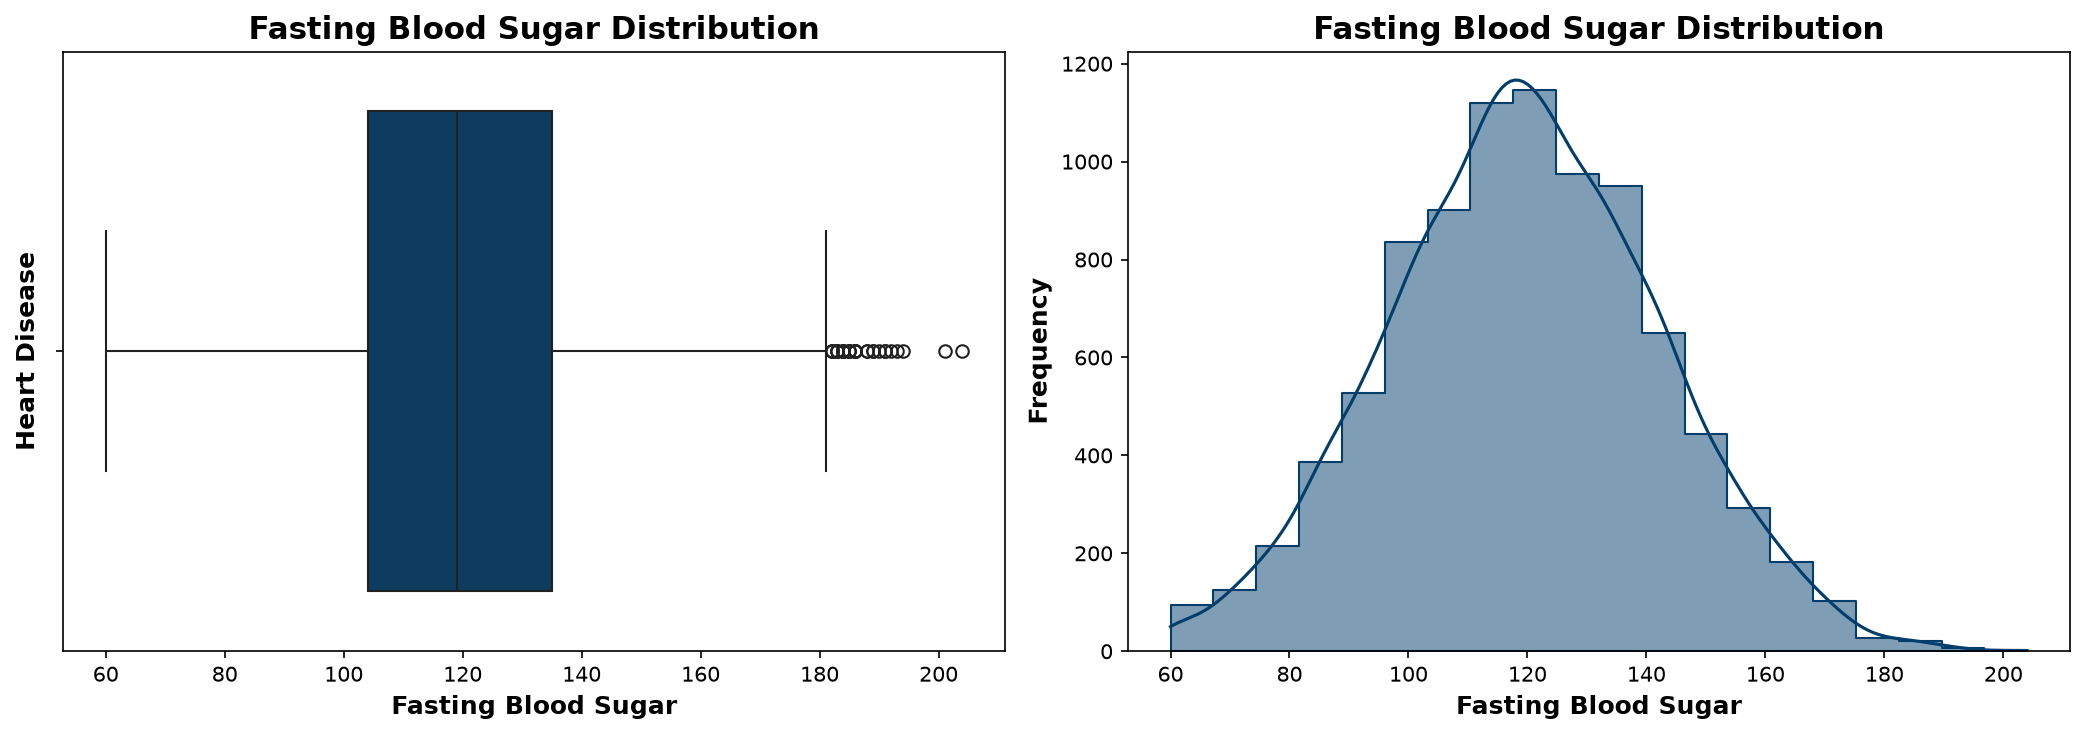

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="fasting_blood_sugar", ax=axes[0], color="#013e6c")

axes[0].set_title("Fasting Blood Sugar Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Fasting Blood Sugar", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="fasting_blood_sugar", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Fasting Blood Sugar Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Fasting Blood Sugar", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [62]:
df["fasting_blood_sugar"].skew()

np.float64(0.04087004068986801)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The distribution of fasting blood glucose levels is approximately normal. The mean fasting blood glucose level is 119.47 mg/dL, with a standard deviation of 22.77 mg/dL. The minimum and maximum values are 60 mg/dL and 204 mg/dL, respectively.
</p> 
</div>

In [63]:
values = np.array(df['fasting_blood_sugar'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 57.5000 or greater than 181.5000
There are 32 outliers.


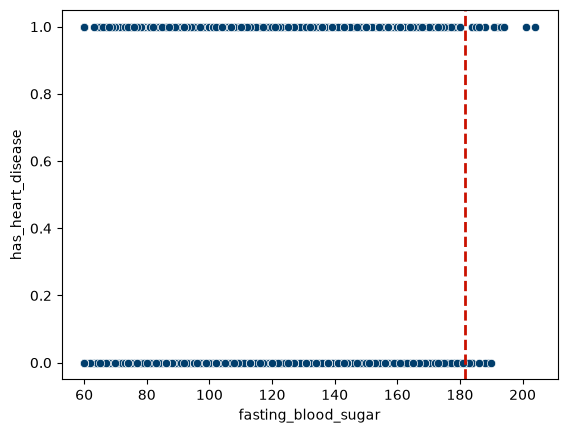

In [64]:
sns.scatterplot(data=data, x="fasting_blood_sugar", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The IQR method identified 32 statistically outlying values. Since unusual blood glucose values can in the real world indicate different metabolic conditions among individuals, being statistically an outlier does not necessarily mean that the data are incorrect. Therefore, these observations were retained in the dataset without removal.
</p> 
</div>

In [65]:
def glucose_category(value):
    if value < 100:
        return "Normal"
    elif value < 126:
        return "Prediabetes"
    else:
        return "Diabetes Range"

glucose_group = data["fasting_blood_sugar"].apply(glucose_category)

print(pd.crosstab(data["has_heart_disease"], glucose_group))

fasting_blood_sugar  Diabetes Range  Normal  Prediabetes
has_heart_disease                                       
0                              2105    1433         2735
1                              1390     290         1047


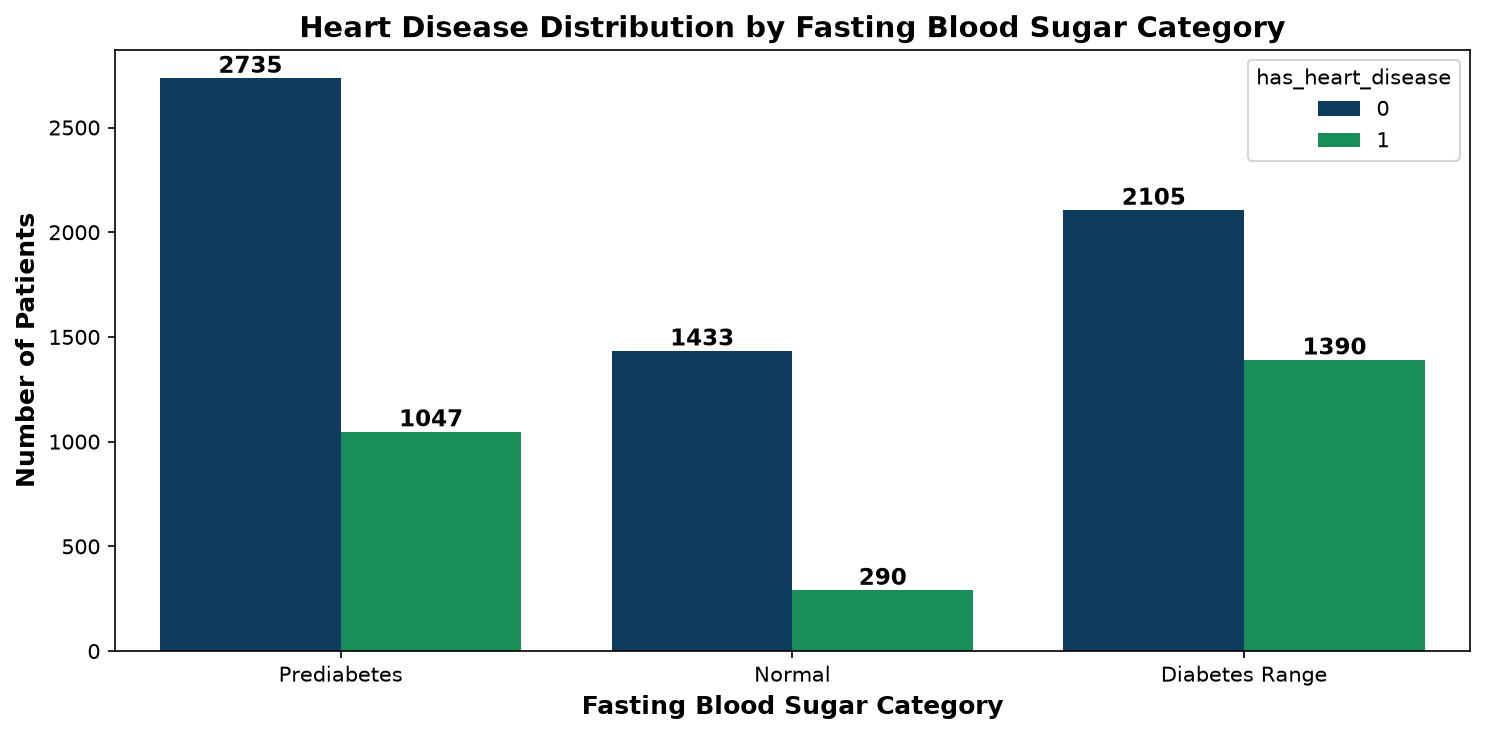

In [66]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(data=data, x=glucose_group, hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Fasting Blood Sugar Category", fontsize=12, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=12, fontweight="bold")
plt.title("Heart Disease Distribution by Fasting Blood Sugar Category", fontsize=14, fontweight="bold")

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Examining the distribution of heart disease across different blood sugar groups shows that in all three groups, Normal, Prediabetes, and Diabetes Range, there are both individuals with and without heart disease. However, in the Diabetes Range group, the number of individuals with heart disease is considerable.

In the Normal group, 290 people had heart disease, while this number reached 1,047 in the Prediabetes group and 1,390 in the Diabetes Range group. This pattern suggests that higher blood sugar levels may be associated with an increased prevalence of heart disease in the dataset.
</p> 
</div>

* #### hba1c

In [67]:
df["hba1c"].describe()

count    9000.000000
mean        5.791633
std         0.692645
min         4.000000
25%         5.300000
50%         5.800000
75%         6.300000
max         8.600000
Name: hba1c, dtype: float64

In [68]:
df["hba1c"].dtype

dtype('float64')

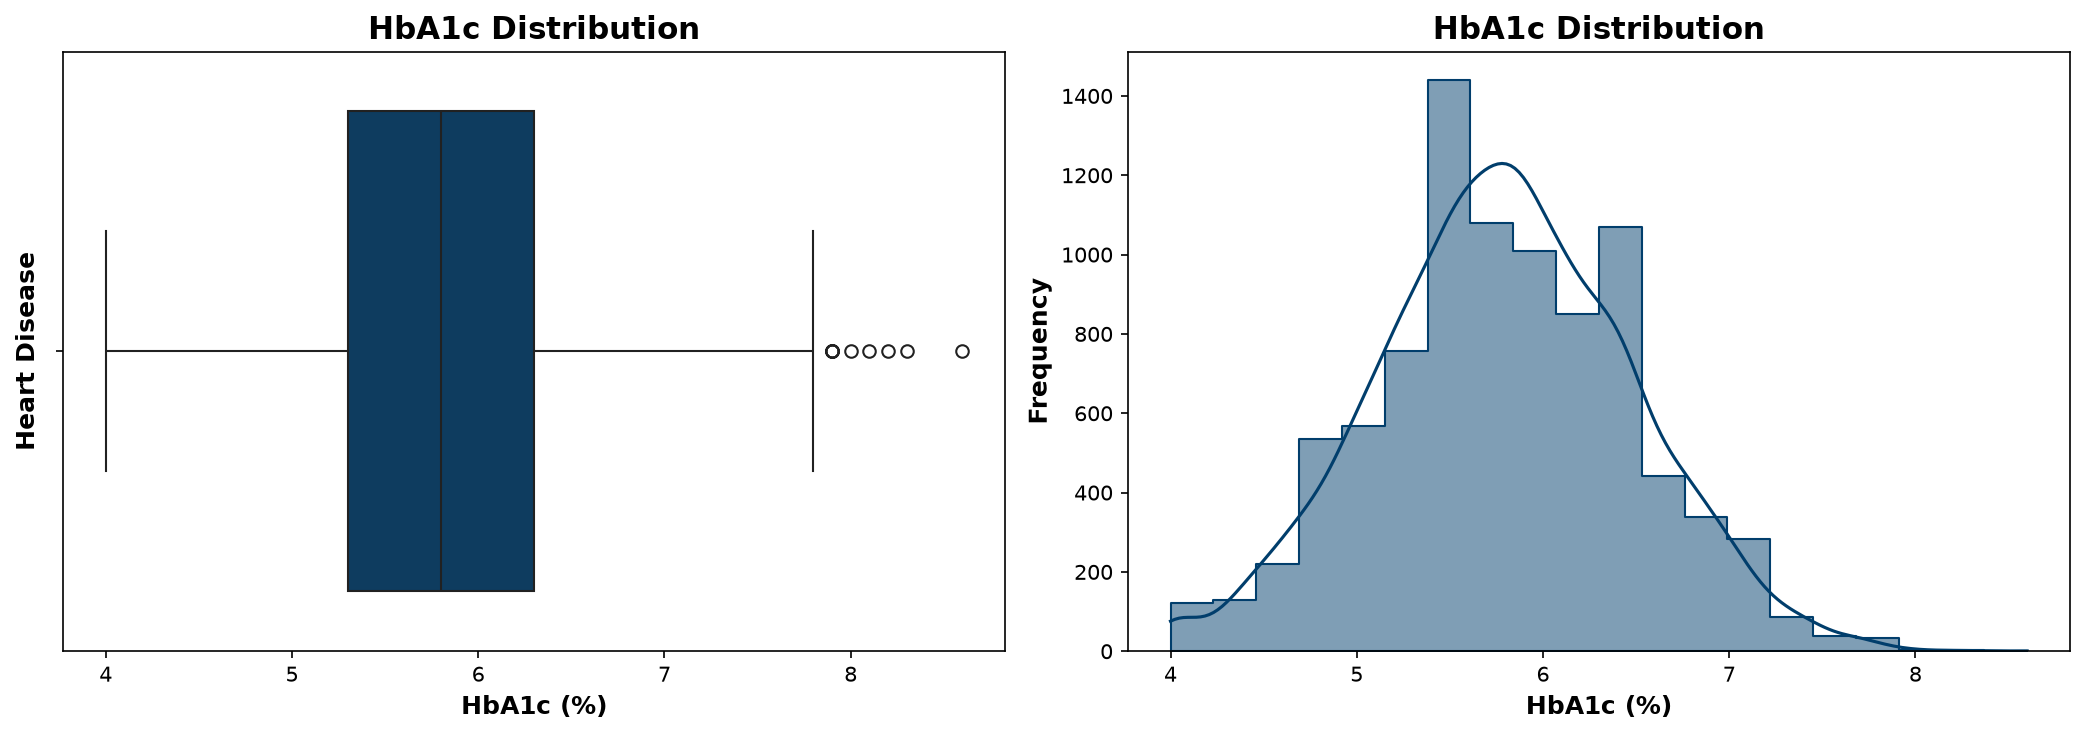

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="hba1c", ax=axes[0], color="#013e6c")

axes[0].set_title("HbA1c Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("HbA1c (%)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="hba1c", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("HbA1c Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("HbA1c (%)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [70]:
df["hba1c"].skew()

np.float64(0.02918248601681103)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The HbA1c distribution is approximately symmetric, with a very slight positive (right) skewness of 0.0291.

The mean HbA1c level among the individuals studied was 5.79% with a standard deviation of 0.69%. The minimum HbA1c value was 4% and the maximum was reported as 8.6%.
</p> 
</div>

In [71]:
values = np.array(df['hba1c'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 3.8000 or greater than 7.8000
There are 10 outliers.


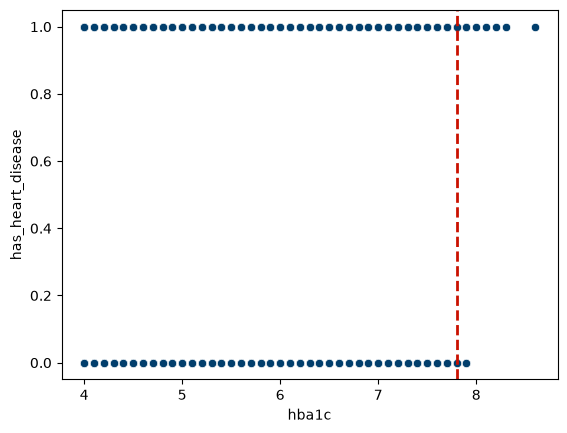

In [72]:
sns.scatterplot(data=data, x="hba1c", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 10 statistical outliers were identified, with values below 3.8 mg/dL or above 7.8 mg/dL. These values were retained as they may represent real variations rather than data errors.
</p> 
</div>

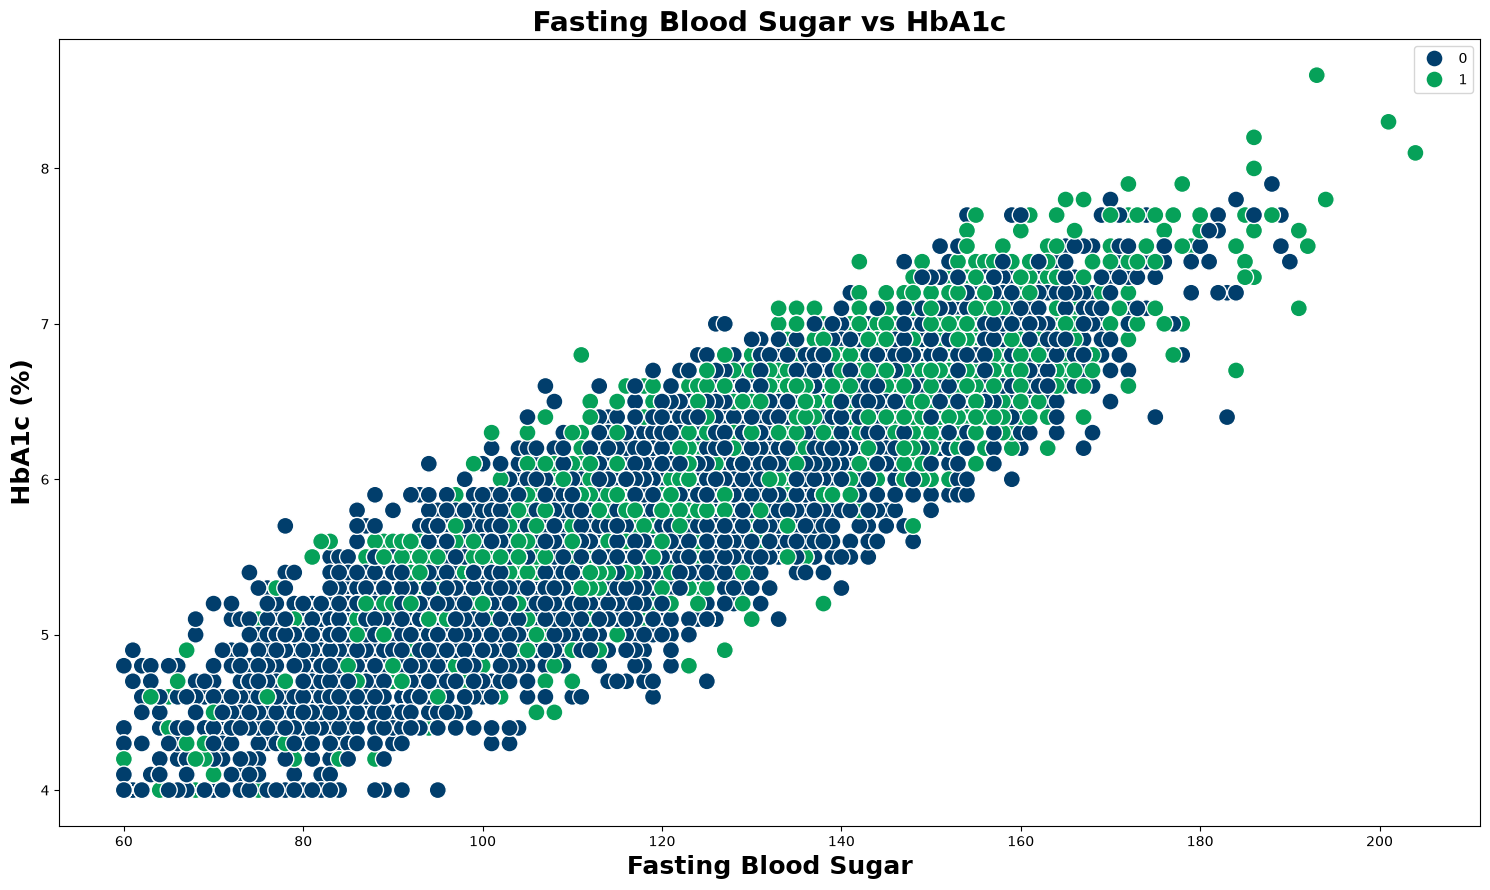

In [73]:
plt.figure(figsize=(15, 9), dpi=100)
sns.scatterplot(data=df, x="fasting_blood_sugar", y="hba1c", hue="has_heart_disease", s=150, palette=["#013e6c", "#06A159"])

plt.xlabel("Fasting Blood Sugar", fontsize=18, fontweight="bold")
plt.ylabel("HbA1c (%)", fontsize=18, fontweight="bold")

plt.title("Fasting Blood Sugar vs HbA1c", fontsize=20, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The scatter plot suggests that heart disease cases become more concentrated as fasting blood glucose levels increase. A similar pattern can be observed for HbA1c, where heart disease cases appear to be more concentrated at higher HbA1c levels. However, there is considerable overlap between individuals with and without heart disease, so these variables alone cannot clearly distinguish the two groups.
</p> 
</div>

* #### BMI

In [74]:
df["bmi"].describe()

count    9000.000000
mean       25.264922
std         4.371525
min        15.000000
25%        22.300000
50%        25.300000
75%        28.200000
max        43.300000
Name: bmi, dtype: float64

In [75]:
df["bmi"].dtype

dtype('float64')

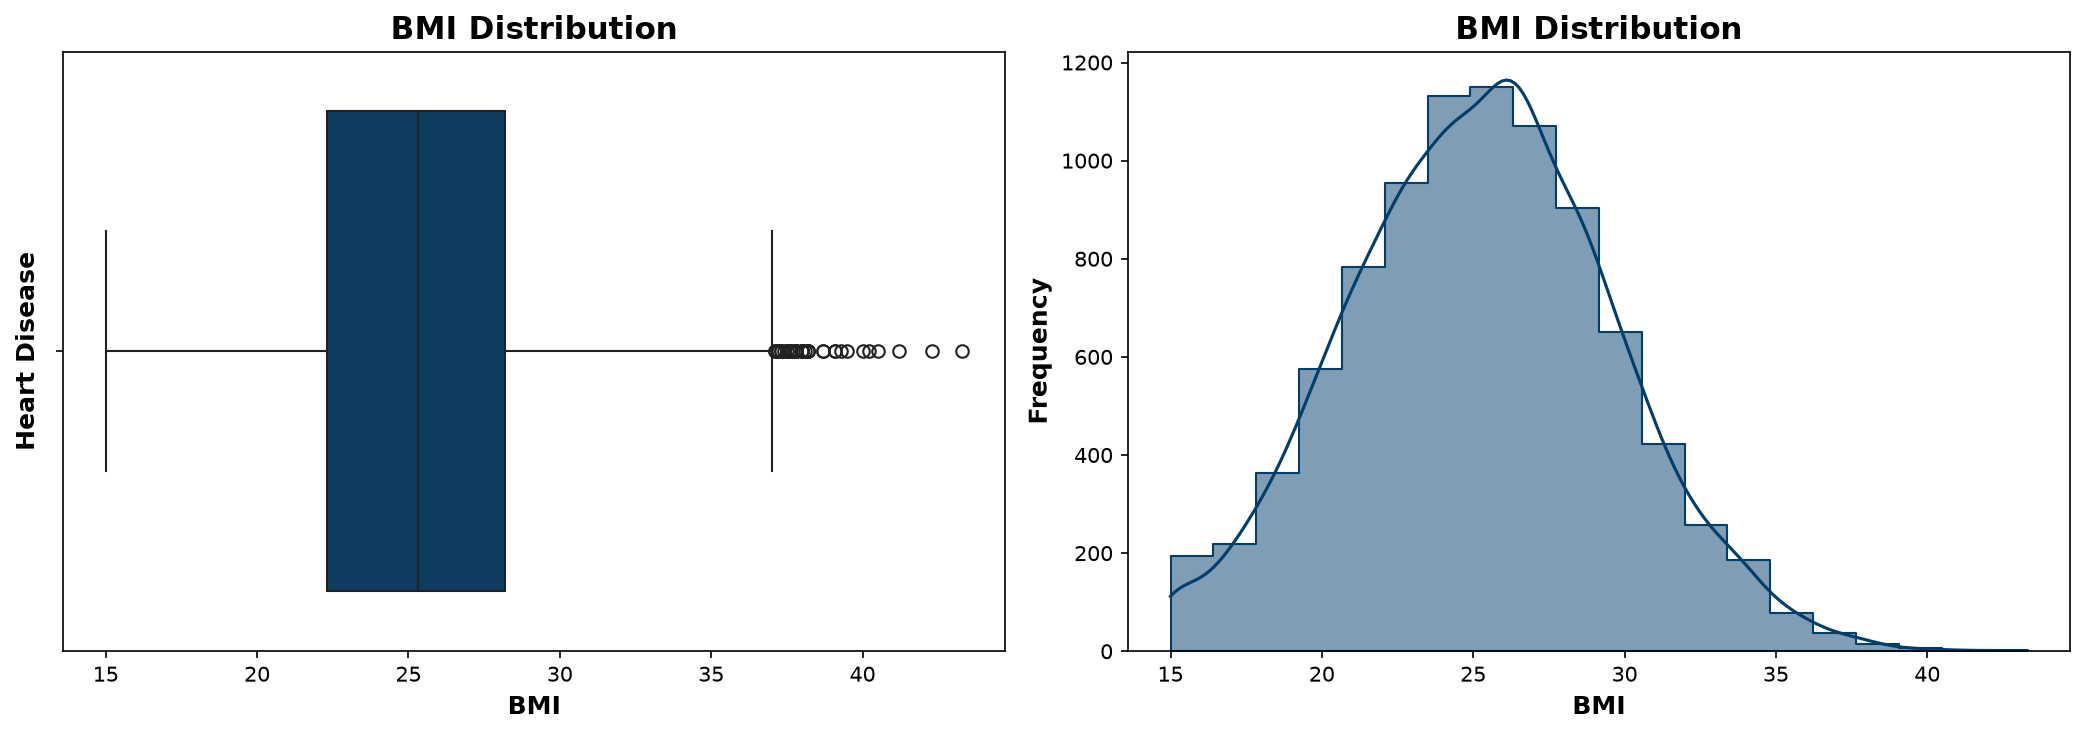

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="bmi", ax=axes[0], color="#013e6c")

axes[0].set_title("BMI Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("BMI", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="bmi", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("BMI Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("BMI", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [77]:
df["bmi"].skew()

np.float64(0.09172164789414236)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The BMI distribution is approximately symmetric, with a very slight positive (right) skewness (0.092). Since the skewness value is close to zero, the distribution can be considered approximately symmetric.

The mean BMI among the individuals studied was 25.26, with a standard deviation of 4.37. The minimum BMI value was 15, while the maximum was 43.
</p> 
</div>

In [78]:
values = np.array(df['bmi'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 13.4500 or greater than 37.0500
There are 39 outliers.


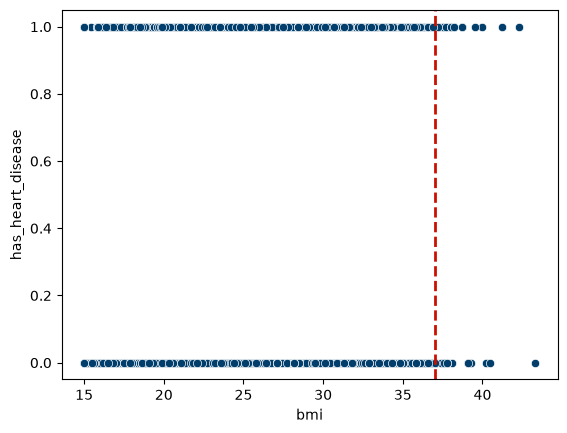

In [79]:
sns.scatterplot(data=data, x="bmi", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 39 BMI values were identified as statistical outliers. However, these observations were not considered erroneous because extreme BMI values can occur in real-world populations and may represent individuals who are underweight or have obesity. Therefore, the identified outliers were retained for further analysis.
</p> 
</div>

* #### Resting Heart Rate

In [80]:
df["resting_heart_rate"].describe()

count    9000.000000
mean       80.912667
std         8.604685
min        48.000000
25%        75.000000
50%        81.000000
75%        87.000000
max       111.000000
Name: resting_heart_rate, dtype: float64

In [81]:
df["resting_heart_rate"].dtype

dtype('int64')

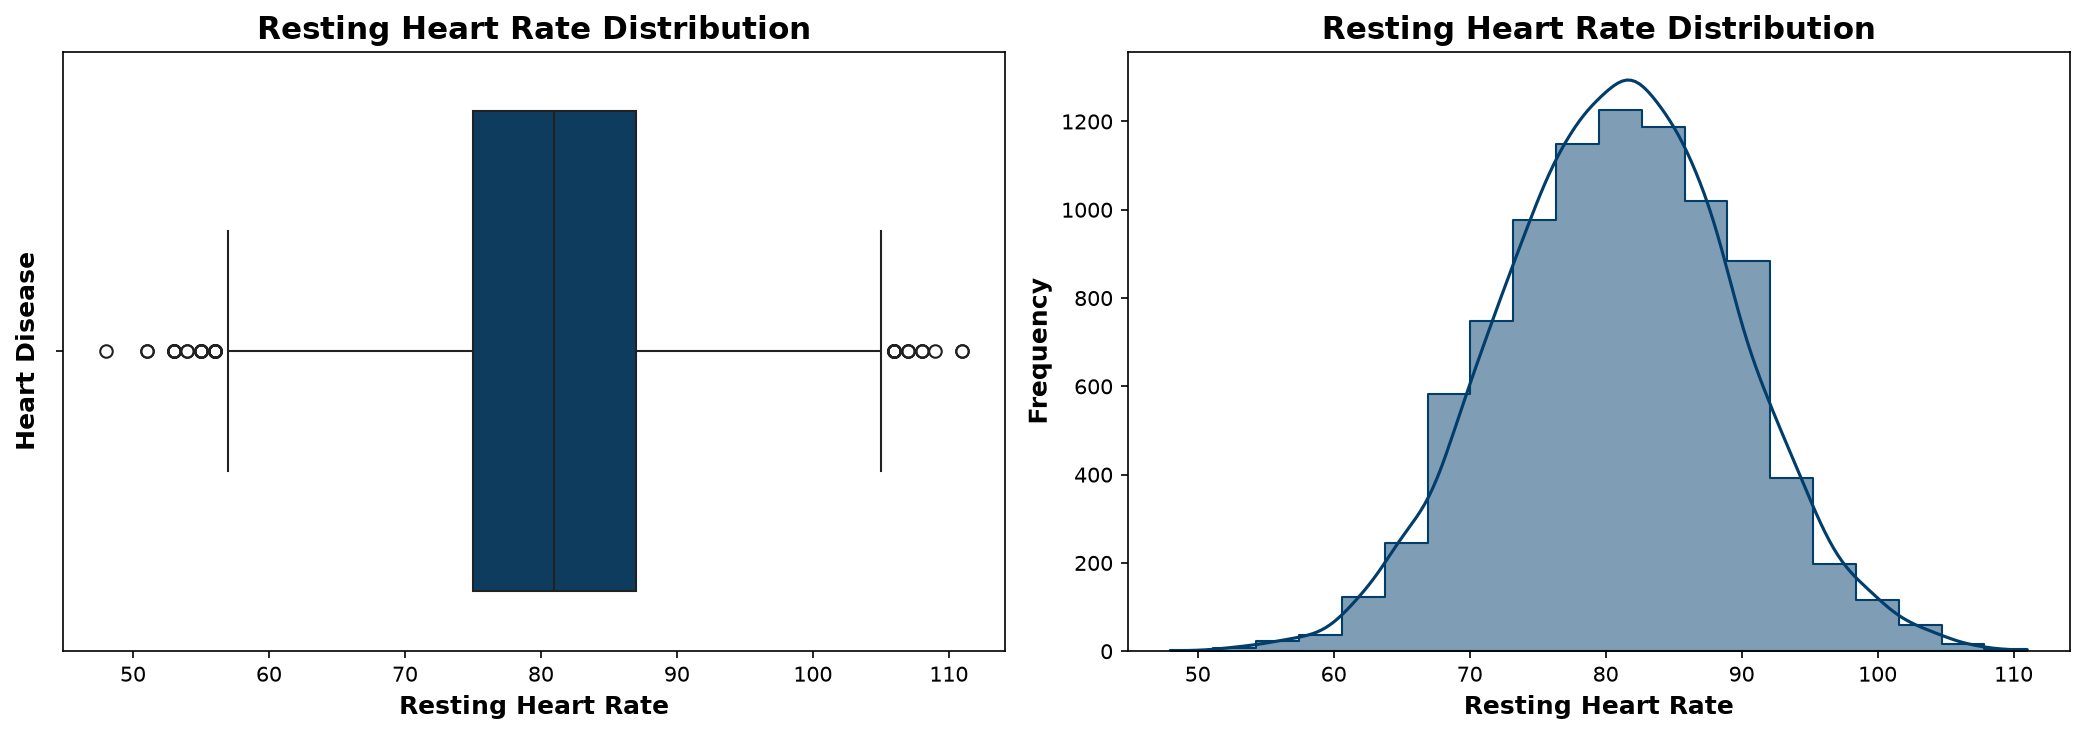

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="resting_heart_rate", ax=axes[0], color="#013e6c")

axes[0].set_title("Resting Heart Rate Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Resting Heart Rate", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="resting_heart_rate", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Resting Heart Rate Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Resting Heart Rate", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [83]:
df["resting_heart_rate"].skew()

np.float64(-0.018912169982314642)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The mean resting heart rate among the individuals studied was 80.91 bpm, with a standard deviation of 8.6 bpm. The minimum resting heart rate was 48 bpm, while the maximum was 111 bpm. The distribution was approximately symmetric, with a very slight negative skewness (-0.019).

</p> 
</div>

In [84]:
values = np.array(df['resting_heart_rate'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 57.0000 or greater than 105.0000
There are 42 outliers.


In [85]:
low_rhr = df[df["resting_heart_rate"] < lower_bound]
high_rhr = df[df["resting_heart_rate"] > upper_bound]
print("Low RHR Outliers:", len(low_rhr))
print("High RHR Outliers:", len(high_rhr))

Low RHR Outliers: 25
High RHR Outliers: 17


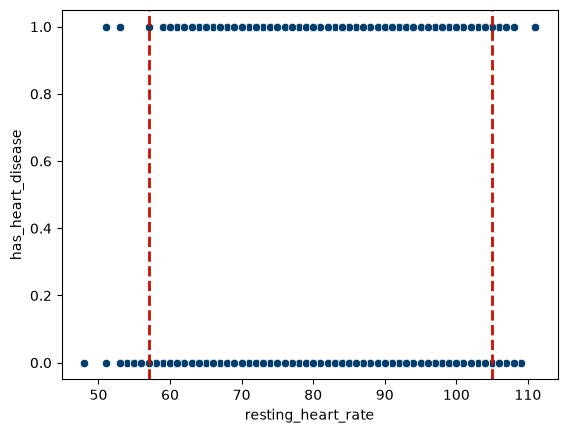

In [86]:
sns.scatterplot(data=data, x="resting_heart_rate", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {lower_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
Using the IQR method, 42 statistical outliers in resting heart rate were identified, including 25 low outliers and 17 high outliers. However, these values were not considered erroneous observations, as variations in resting heart rate can naturally occur among individuals. Lower values may be observed in individuals with high physical fitness, while higher values may be associated with factors such as stress, physical condition, or other physiological changes. Therefore, the identified outliers were retained for further analysis.

</p> 
</div>

* #### Max Heart Rate Achieved

In [87]:
df["max_heart_rate_achieved"].describe()

count    9000.000000
mean      164.838333
std        21.290773
min        93.000000
25%       150.000000
50%       166.000000
75%       180.000000
max       210.000000
Name: max_heart_rate_achieved, dtype: float64

In [88]:
df["max_heart_rate_achieved"].dtype

dtype('int64')

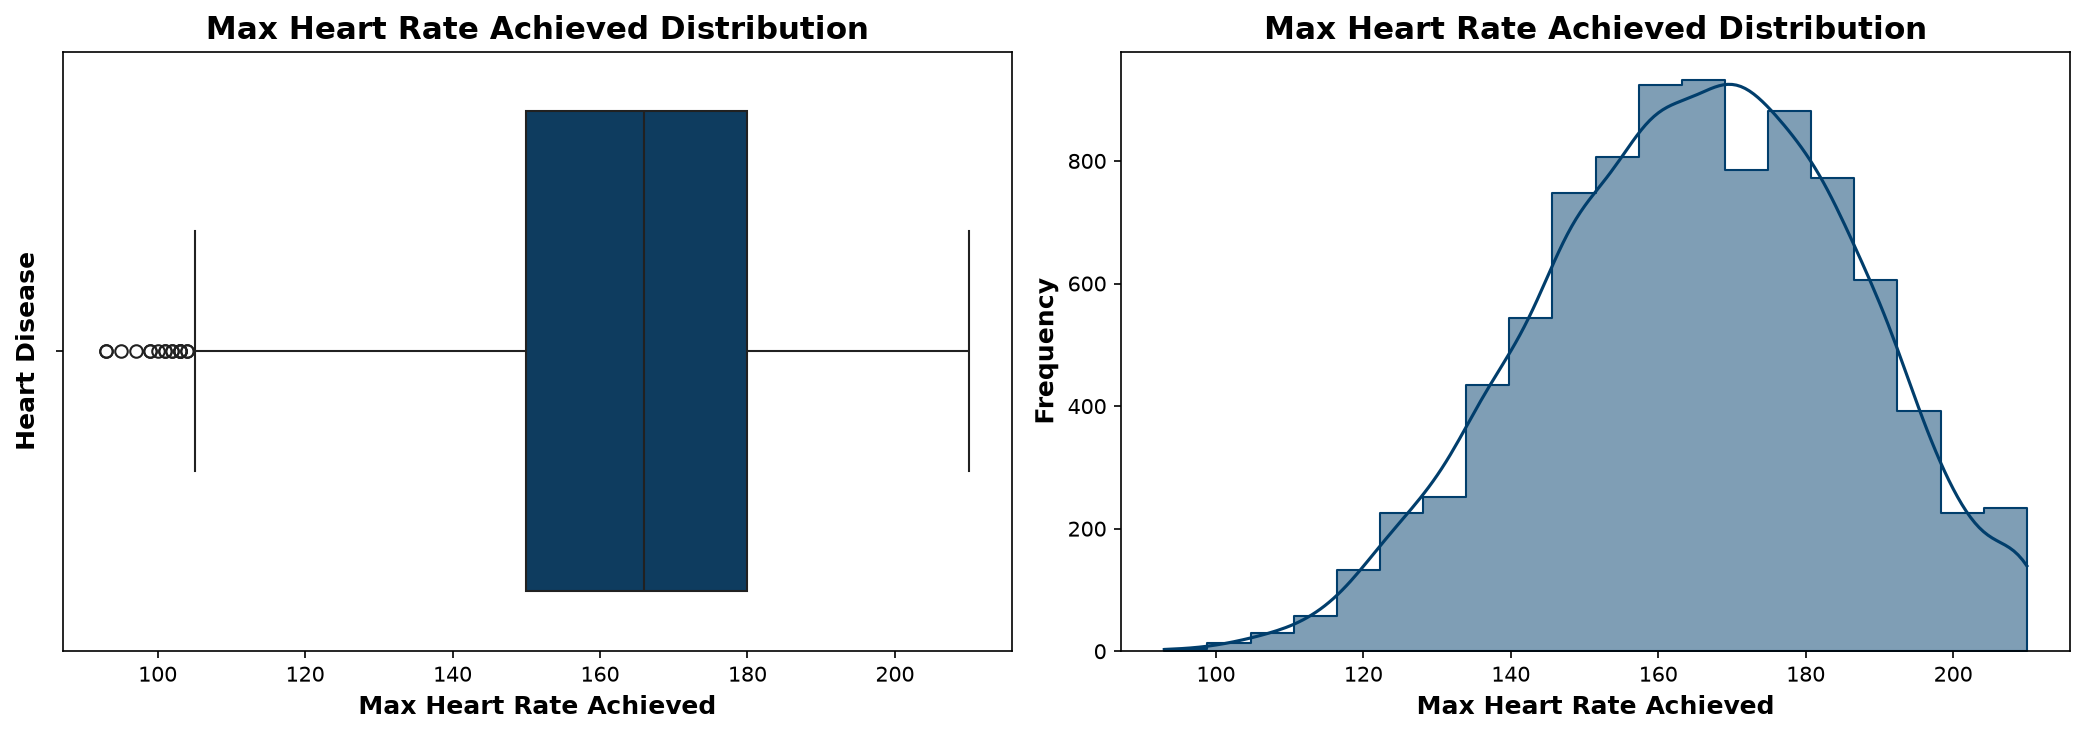

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="max_heart_rate_achieved", ax=axes[0], color="#013e6c")

axes[0].set_title("Max Heart Rate Achieved Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Max Heart Rate Achieved", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="max_heart_rate_achieved", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Max Heart Rate Achieved Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Max Heart Rate Achieved", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [90]:
df["max_heart_rate_achieved"].skew()

np.float64(-0.18466205029389743)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Max Heart Rate Achieved distribution is approximately symmetric, with a very slight negative (left) skewness (-0.1846). Since the skewness value is close to zero, the distribution can be considered approximately symmetric.

The mean Max Heart Rate Achieved among the individuals studied was 164.83 bpm, with a standard deviation of 21.29 bpm. The minimum Max Heart Rate Achieved value was 93 bpm, while the maximum was 210 bpm.

</p> 
</div>

In [91]:
values = np.array(df['max_heart_rate_achieved'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 105.0000 or greater than 225.0000
There are 17 outliers.


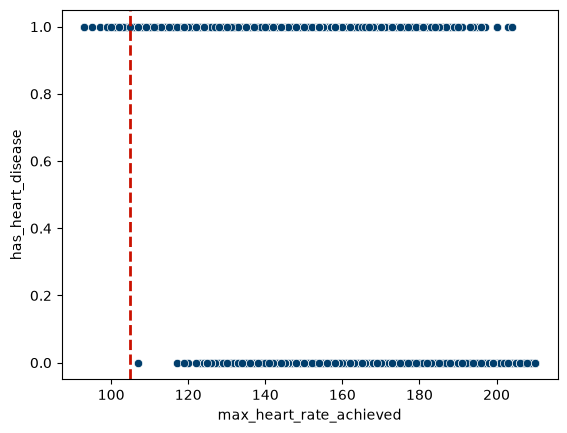

In [92]:
sns.scatterplot(data=data, x="max_heart_rate_achieved", y="has_heart_disease", color="#013e6c")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {lower_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 17 low statistical outliers were identified in the Max Heart Rate Achieved variable. These values were retained because unusually low maximum heart rates may occur due to individual physiological differences, age, physical fitness, exercise capacity, or differences in exercise intensity. Therefore, these observations were not considered erroneous solely based on the statistical outlier criterion and were retained for further analysis.

</p> 
</div>

In [93]:
max_hr_group = pd.cut(
    data["max_heart_rate_achieved"],
    bins=[90, 109, 129, 149, 169, 189, 210],
    labels=[
        "90-109",
        "110-129",
        "130-149",
        "150-169",
        "170-189",
        "190-210"
    ]
)

In [94]:
print(pd.crosstab(data["has_heart_disease"], max_hr_group))

max_heart_rate_achieved  90-109  110-129  130-149  150-169  170-189  190-210
has_heart_disease                                                           
0                             1       37      562     2017     2530     1126
1                            43      428     1108      907      223       18


In [95]:
max_hr_group = pd.cut(
    data["max_heart_rate_achieved"],
    bins=[90, 109, 129, 149, 169, 189, 210],
    labels=[
        "90-109",
        "110-129",
        "130-149",
        "150-169",
        "170-189",
        "190-210"
    ]
)

heart_disease_rate = (
    data.groupby(max_hr_group, observed=True)["has_heart_disease"]
    .mean()
    .mul(100)
)

print(heart_disease_rate)

max_heart_rate_achieved
90-109     97.727273
110-129    92.043011
130-149    66.347305
150-169    31.019152
170-189     8.100254
190-210     1.573427
Name: has_heart_disease, dtype: float64


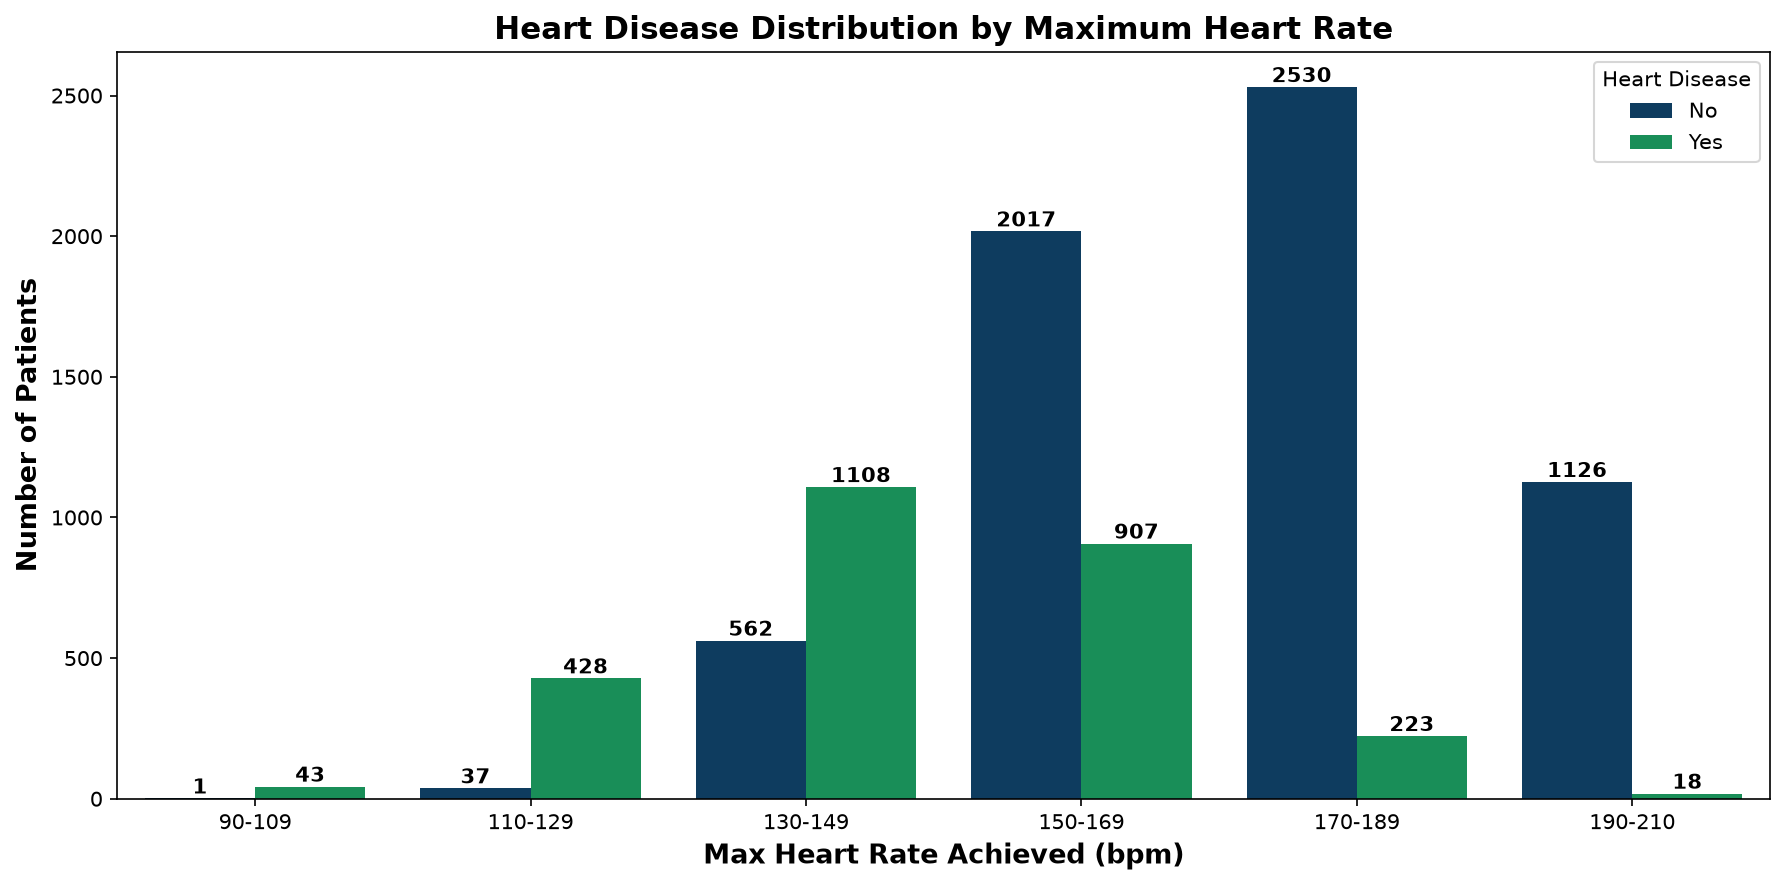

In [96]:
plt.figure(figsize=(12, 6), dpi=150)

ax = sns.countplot(x=max_hr_group, hue=data["has_heart_disease"], palette=["#013e6c", "#06A159"])

plt.xlabel("Max Heart Rate Achieved (bpm)", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("Heart Disease Distribution by Maximum Heart Rate", fontsize=15, fontweight="bold")
plt.legend(title="Heart Disease", labels=["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The analysis reveals a strong inverse pattern between maximum heart rate achieved and heart disease prevalence. The proportion of individuals with heart disease decreases substantially as maximum heart rate increases, from 97.7% in the 90–109 bpm group to only 1.6% in the 190–210 bpm group. The prevalence of heart disease was 92.0% among individuals with a maximum heart rate of 110–129 bpm, 66.3% in the 130–149 bpm group, and 31.0% in the 150–169 bpm group. This pattern suggests that a lower maximum heart rate achieved during exercise is strongly associated with the presence of heart disease in this dataset. However, this finding represents an association rather than causation, and maximum heart rate is influenced by factors such as age, physical fitness, medications, and individual physiological characteristics.


</p> 
</div>

* #### ST Depression

In [97]:
df["st_depression"].describe()

count    9000.000000
mean        1.012911
std         0.957090
min         0.000000
25%         0.400000
50%         0.700000
75%         1.400000
max         6.500000
Name: st_depression, dtype: float64

In [98]:
df["st_depression"].dtype

dtype('float64')

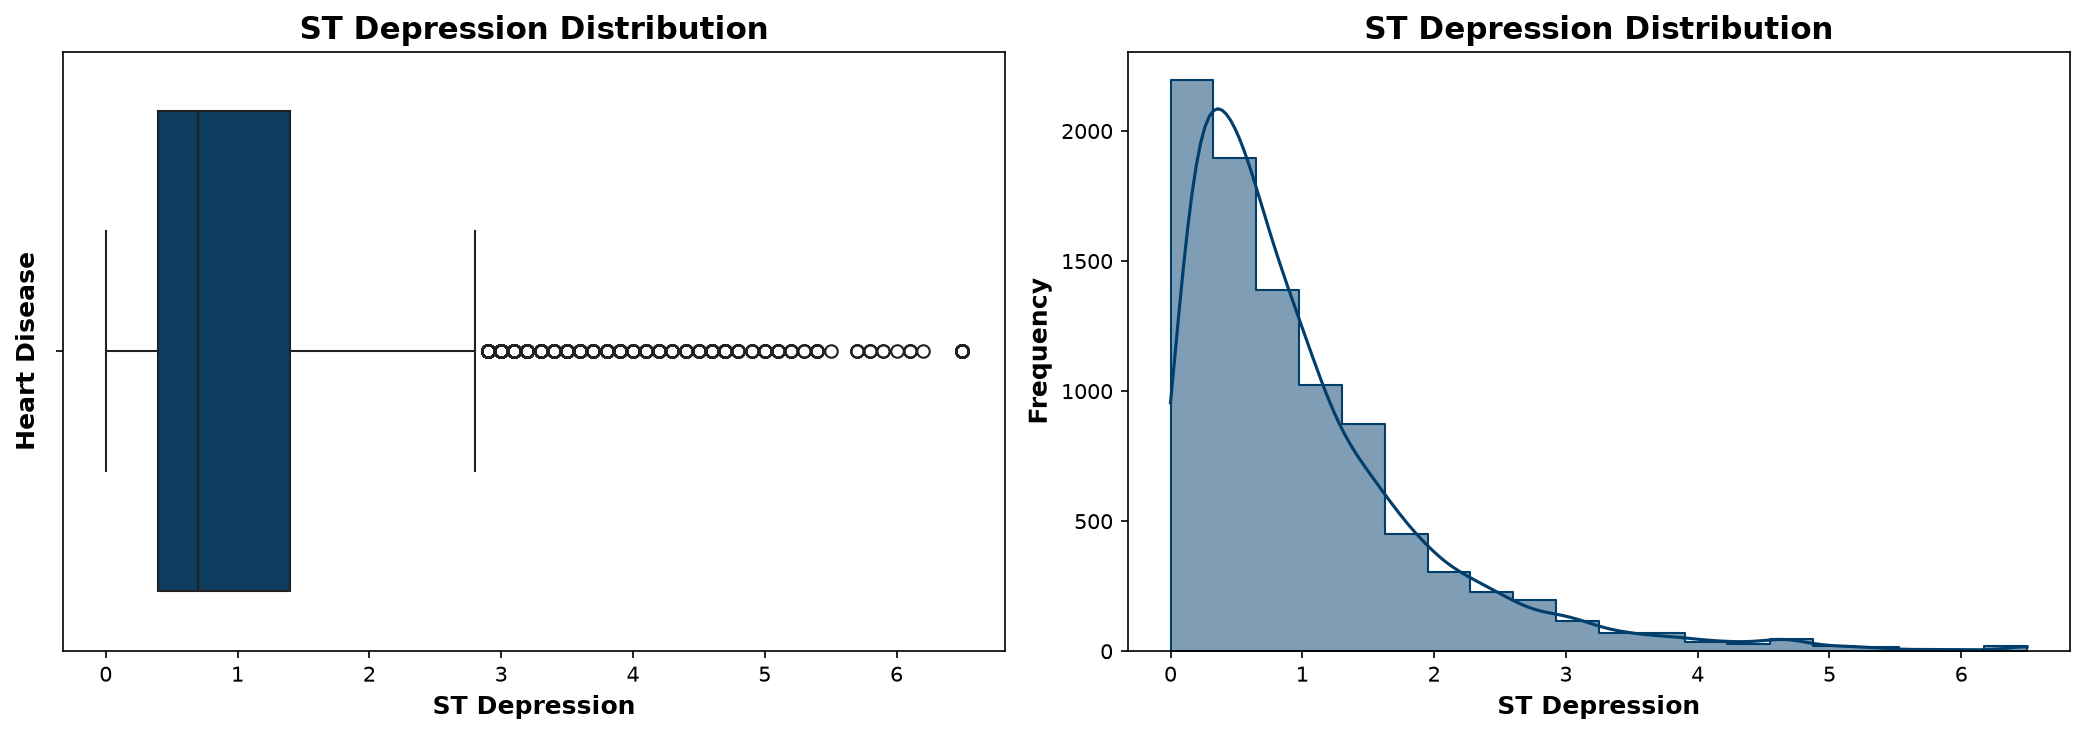

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="st_depression", ax=axes[0], color="#013e6c")

axes[0].set_title("ST Depression Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("ST Depression", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="st_depression", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("ST Depression Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("ST Depression", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [100]:
df["st_depression"].skew()

np.float64(2.0409107320218776)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The ST Depression distribution is strongly positively skewed (right-skewed), with a skewness of 2.040. Since the skewness value is substantially greater than zero, the distribution cannot be considered approximately symmetric.

The mean ST Depression among the individuals studied was 1.01, with a standard deviation of 0.95. The minimum ST Depression value was 0, while the maximum was 6.5.


</p> 
</div>

In [101]:
values = np.array(df['st_depression'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than -1.1000 or greater than 2.9000
There are 485 outliers.


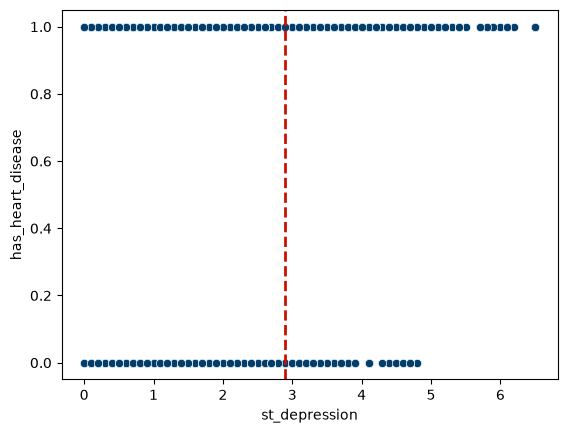

In [102]:
sns.scatterplot(data=data, x="st_depression", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 485 high statistical outliers were identified in the ST Depression variable. However, these observations were not considered erroneous because a statistically extreme ST depression value does not necessarily represent a data error. Clinically, ST-segment depression, particularly during exercise testing, can be associated with myocardial ischemia and coronary artery disease. Therefore, these high values may represent clinically meaningful observations rather than invalid data. The outliers were consequently retained for further analysis. However, ST depression should not be interpreted as a standalone diagnostic indicator of heart disease.
</p> 
</div>


In [103]:
st_group = pd.cut(
    data["st_depression"],
    bins=[-0.01, 1, data["st_depression"].max()],
    labels=[
        "No Significant ST Depression",
        "ST Depression ≥ 1 mm"
    ]
)

In [104]:
print(pd.crosstab(data["has_heart_disease"], st_group))

st_depression      No Significant ST Depression  ST Depression ≥ 1 mm
has_heart_disease                                                    
0                                          4645                  1628
1                                          1234                  1493


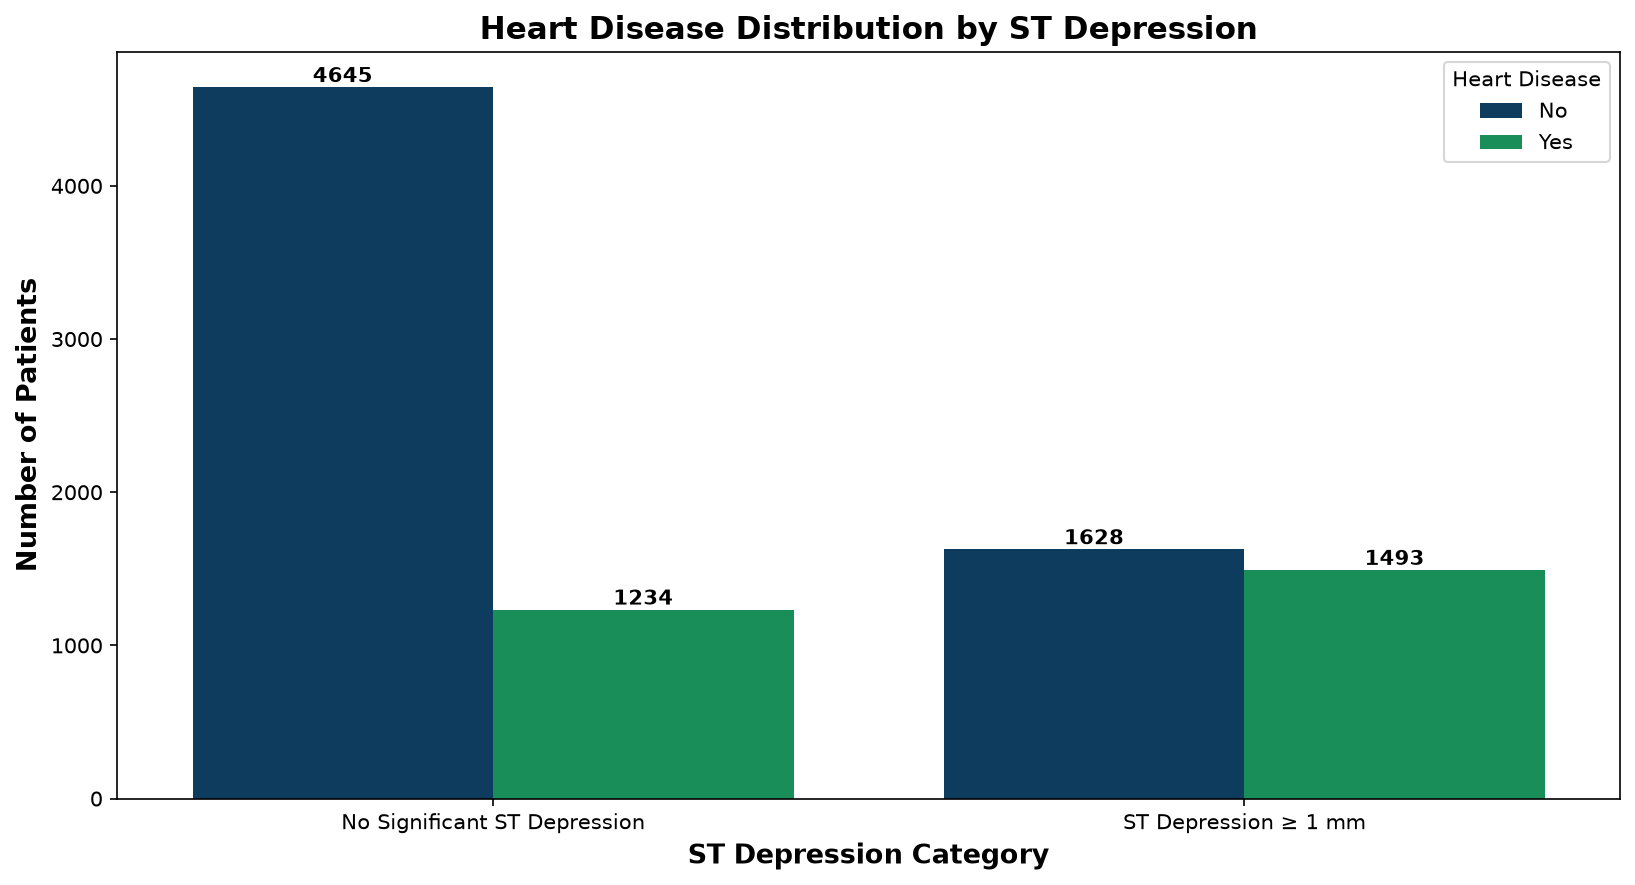

In [105]:
plt.figure(figsize=(11, 6), dpi=150)

ax = sns.countplot(x=st_group, hue=data["has_heart_disease"], palette=["#013e6c", "#06A159"])

plt.xlabel("ST Depression Category", fontsize=13, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=13, fontweight="bold")
plt.title("Heart Disease Distribution by ST Depression", fontsize=15, fontweight="bold")

plt.legend(title="Heart Disease", labels=["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The analysis shows a clear association between ST depression and heart disease in the dataset. Among individuals with no significant ST depression (<1 mm), 21.0% had heart disease, whereas 47.8% of individuals with ST depression ≥1 mm had heart disease. This indicates that heart disease was substantially more prevalent among individuals with ST depression of 1 mm or greater. The observed pattern is consistent with the clinical significance of exercise-induced ST-segment depression as a potential indicator of myocardial ischemia. However, ST depression alone is not sufficient to diagnose heart disease and should be interpreted alongside other clinical and ECG findings.
</p> 
</div>



* #### Alcohol Units Per Week

In [106]:
df["alcohol_units_per_week"].describe()

count    9000.000000
mean        5.708733
std         5.070642
min         0.000000
25%         2.200000
50%         4.200000
75%         7.700000
max        45.900000
Name: alcohol_units_per_week, dtype: float64

In [107]:
df["alcohol_units_per_week"].dtype

dtype('float64')

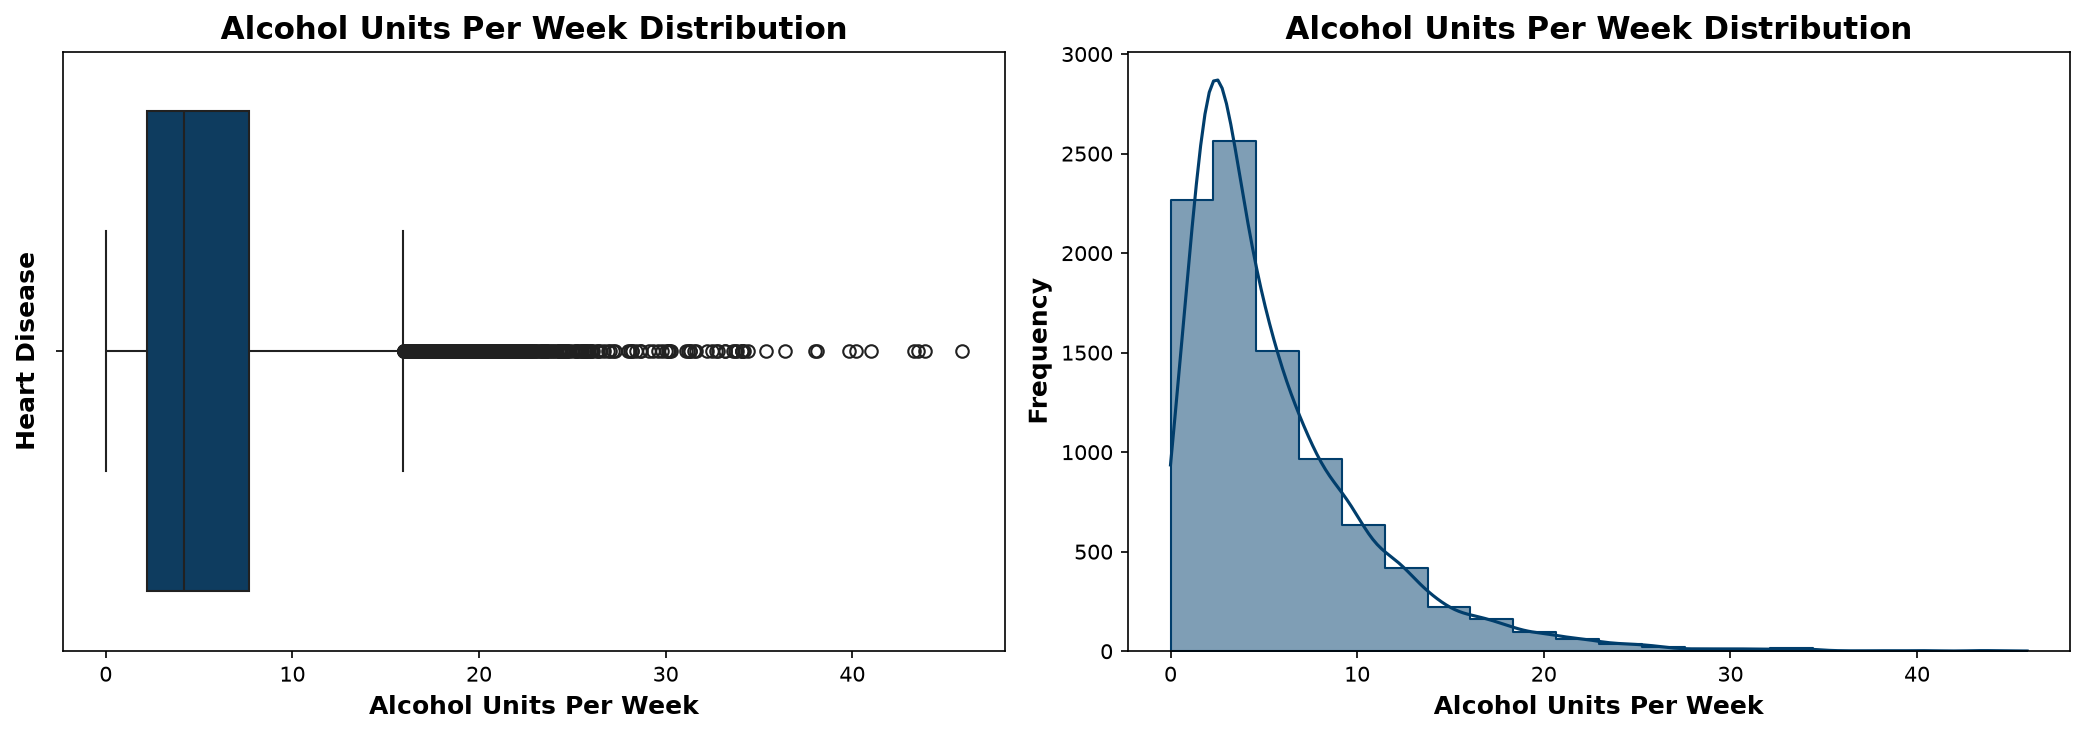

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="alcohol_units_per_week", ax=axes[0], color="#013e6c")

axes[0].set_title("Alcohol Units Per Week Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Alcohol Units Per Week", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="alcohol_units_per_week", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")

axes[1].set_title("Alcohol Units Per Week Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Alcohol Units Per Week", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [109]:
df["alcohol_units_per_week"].skew()

np.float64(2.027234164852369)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Alcohol Units Per Week distribution is strongly positively skewed (right-skewed), with a skewness of 2.027. Since the skewness value is substantially greater than zero, the distribution cannot be considered approximately symmetric.

The mean Alcohol Units Per Week among the individuals studied was 5.70, with a standard deviation of 5.07. The minimum value was 0 units per week, while the maximum was 45.9 units per week.



</p> 
</div>

In [110]:
values = np.array(df['alcohol_units_per_week'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than -6.0500 or greater than 15.9500
There are 431 outliers.


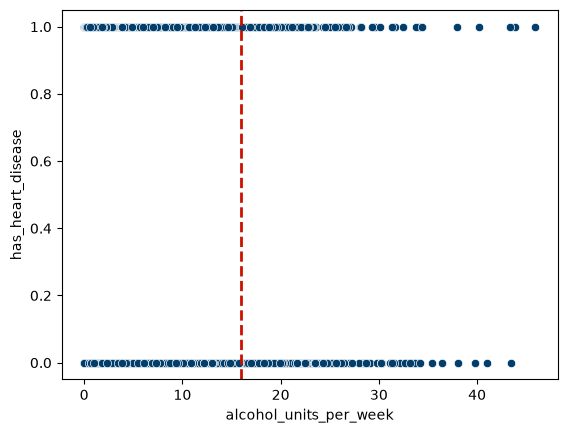

In [111]:
sns.scatterplot(data=data, x="alcohol_units_per_week", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 431 high statistical outliers were identified in the Alcohol Units Per Week variable. All of these outliers were above the upper IQR limit of 15.95 units per week. These values were retained because a statistically high value does not necessarily indicate a data error. Higher alcohol consumption can occur in real-world populations and may represent genuine individual differences in drinking patterns. Therefore, the identified high values were considered potentially valid observations and were retained for further analysis.
</p> 
</div>


* #### Exercise Minutes Per Week

In [112]:
df["exercise_minutes_per_week"].describe()

count    9000.000000
mean      139.493444
std        63.660433
min         0.000000
25%        96.000000
50%       139.000000
75%       183.000000
max       366.000000
Name: exercise_minutes_per_week, dtype: float64

In [113]:
df["exercise_minutes_per_week"].dtype

dtype('int64')

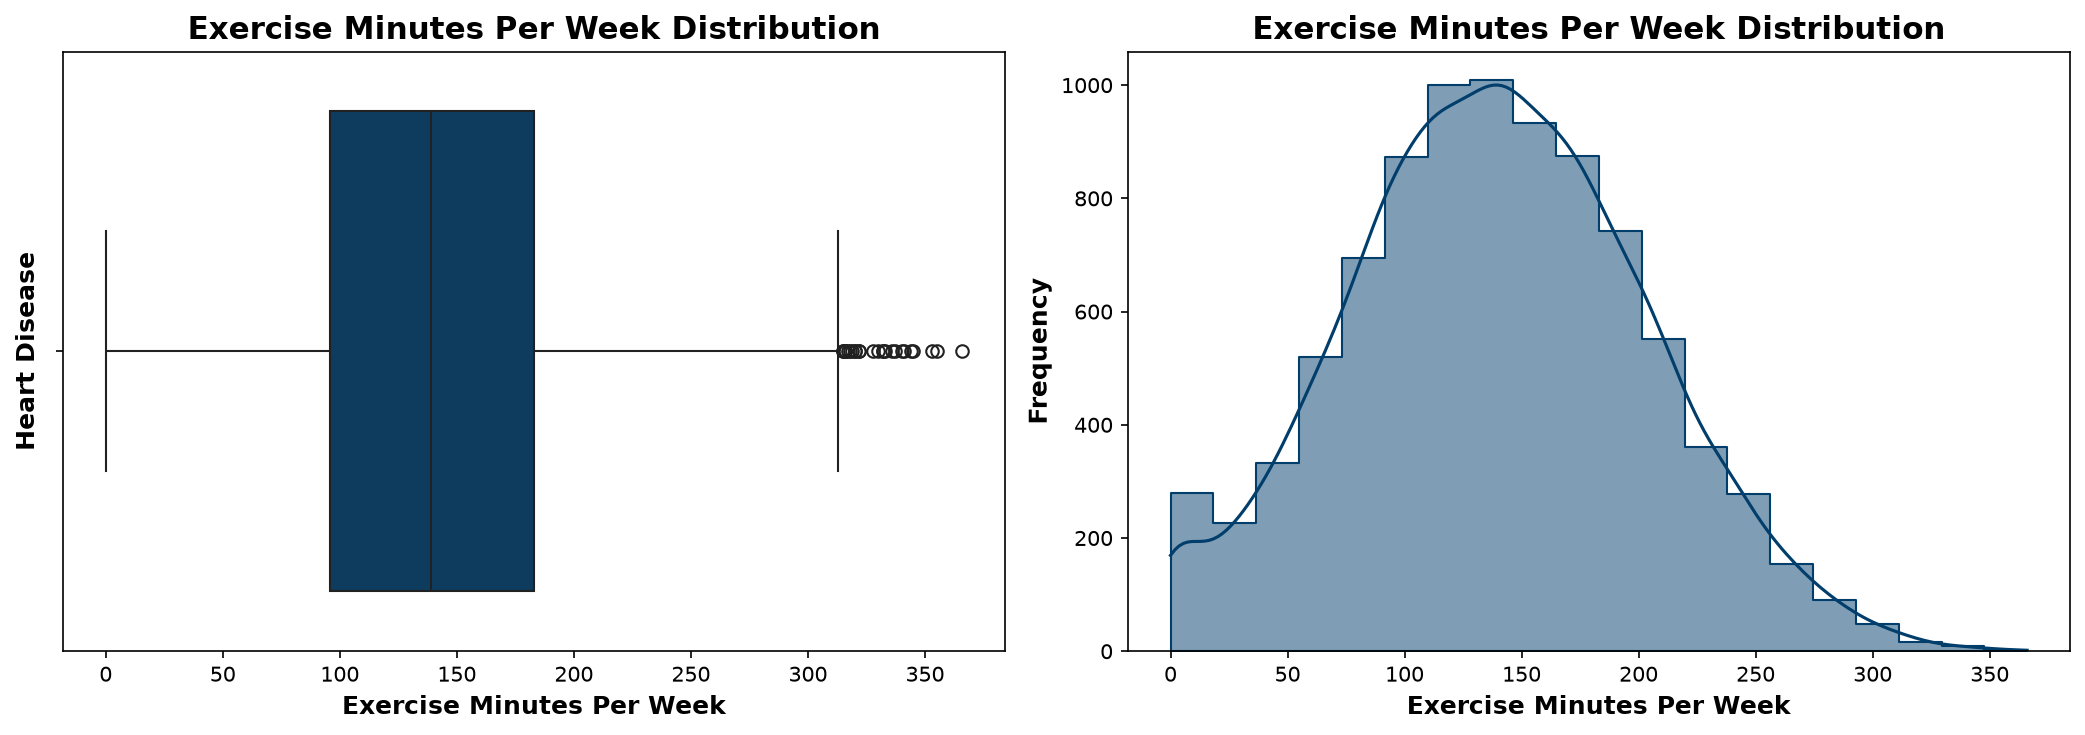

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="exercise_minutes_per_week", ax=axes[0], color="#013e6c")

axes[0].set_title("Exercise Minutes Per Week Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Exercise Minutes Per Week", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="exercise_minutes_per_week", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")
axes[1].set_title("Exercise Minutes Per Week Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Exercise Minutes Per Week", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [115]:
df["exercise_minutes_per_week"].skew()

np.float64(0.09364702247072827)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Exercise Minutes Per Week distribution is approximately symmetric, with a very slight positive (right) skewness of 0.093. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The mean Exercise Minutes Per Week among the individuals studied was 139.49 minutes per week, with a standard deviation of 63.66 minutes. The minimum value was 0 minutes per week, while the maximum was 366 minutes per week.




</p> 
</div>

In [116]:
values = np.array(df['exercise_minutes_per_week'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than -34.5000 or greater than 313.5000
There are 27 outliers.


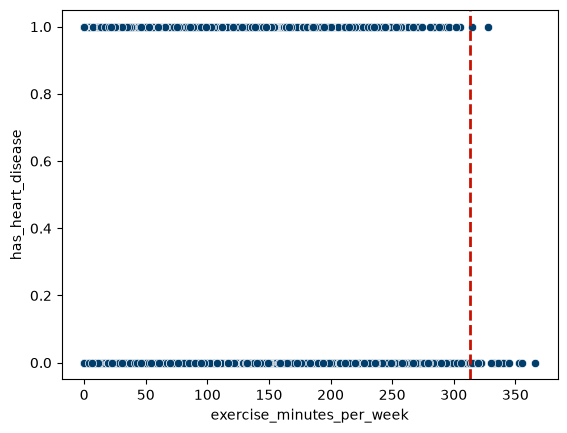

In [117]:
sns.scatterplot(data=data, x="exercise_minutes_per_week", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 27 high statistical outliers were identified in the Exercise Minutes Per Week variable. All of these observations were above the upper IQR limit of 313.5 minutes per week. However, these values were retained because statistically unusual observations do not necessarily represent data errors. Higher levels of physical activity can occur naturally in individuals who exercise frequently or have highly active lifestyles. Therefore, these observations were considered potentially valid and were retained for further analysis.
</p> 
</div>

* #### Sleep Hours

In [118]:
df["sleep_hours"].describe()

count    9000.000000
mean        6.994578
std         1.104215
min         3.100000
25%         6.300000
50%         7.000000
75%         7.700000
max        11.000000
Name: sleep_hours, dtype: float64

In [119]:
df["sleep_hours"].dtype

dtype('float64')

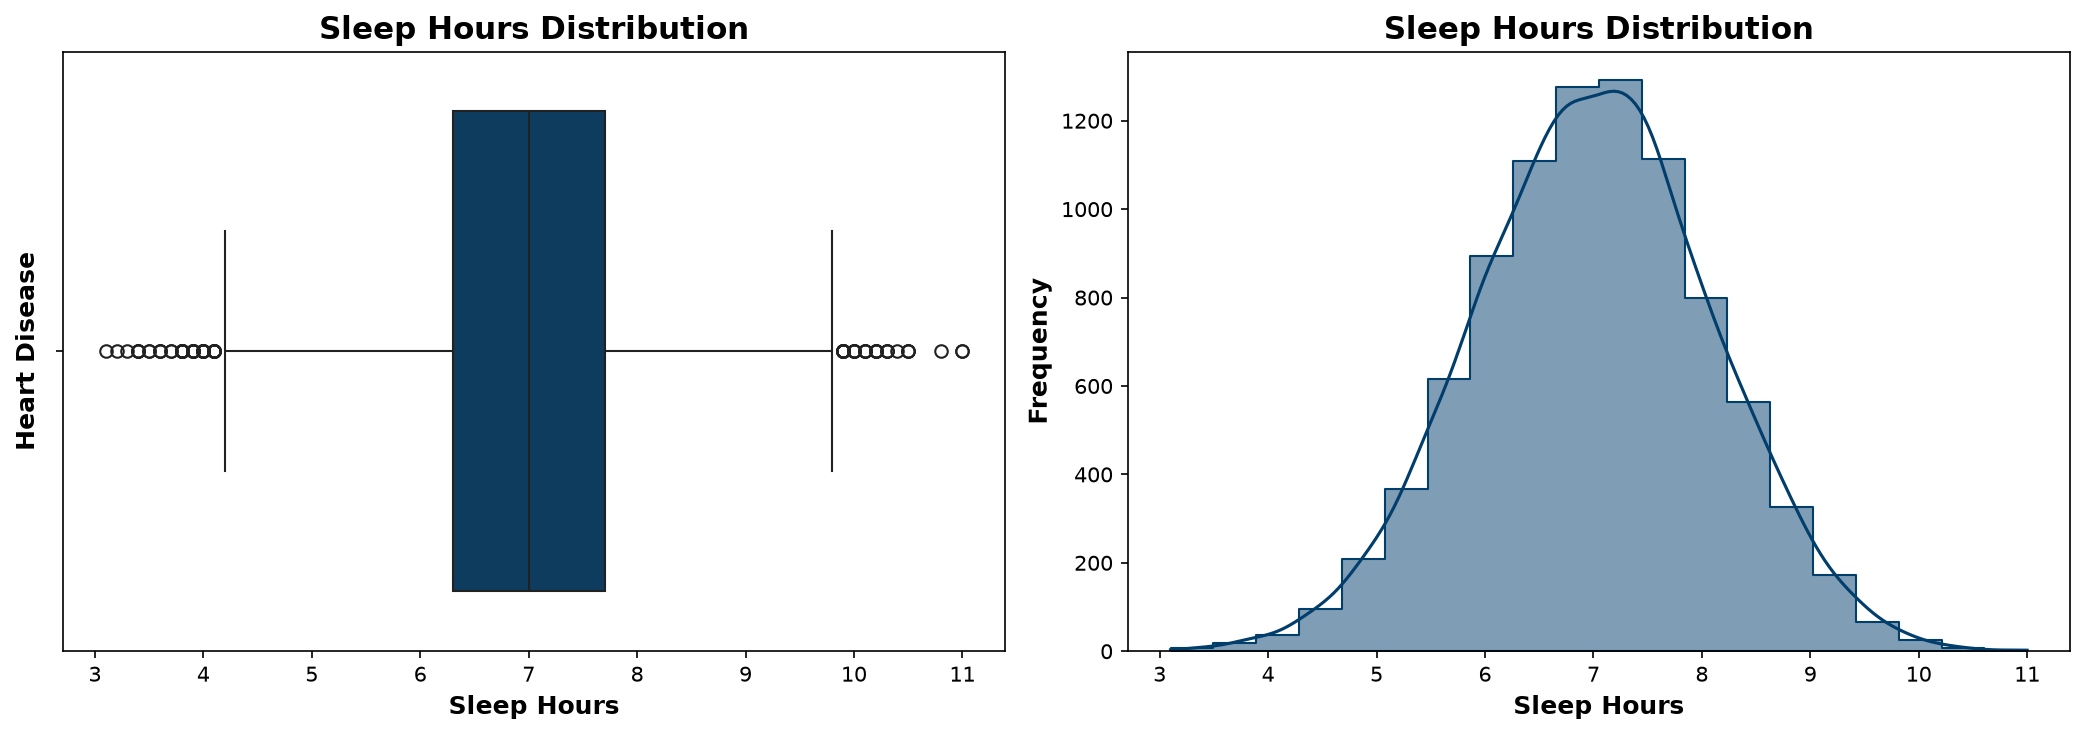

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="sleep_hours", ax=axes[0], color="#013e6c")

axes[0].set_title("Sleep Hours Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Sleep Hours", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="sleep_hours", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")
axes[1].set_title("Sleep Hours Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Sleep Hours", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [121]:
df["sleep_hours"].skew()

np.float64(-0.042455395252959674)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Sleep Hours distribution is approximately symmetric, with a very slight negative (left) skewness of -0.0424. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The mean sleep duration among the individuals studied was 6.99 hours per night, with a standard deviation of 1.10 hours. The minimum sleep duration was 3.10 hours per night, while the maximum was 11 hours per night.
</p> 
</div>

In [122]:
values = np.array(df['sleep_hours'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 4.2000 or greater than 9.8000
There are 86 outliers.


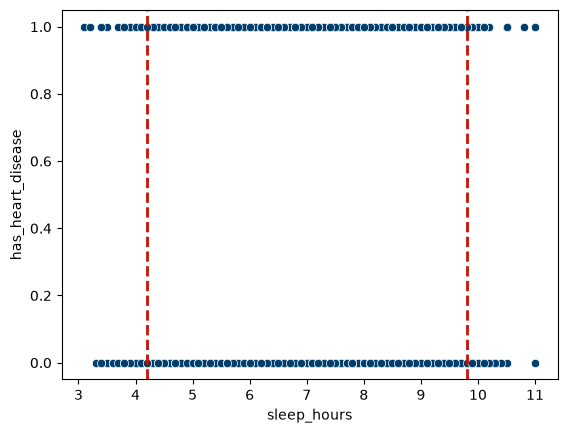

In [123]:
sns.scatterplot(data=data, x="sleep_hours", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {lower_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 86 statistical outliers were identified in the Sleep Hours variable. These outliers include observations with sleep durations below 4.2 hours and above 9.8 hours per night.

However, these values were not considered erroneous observations, as unusually short or long sleep durations can occur in real-world populations. Therefore, the identified outliers were retained for further analysis rather than being removed solely based on the IQR criterion.
</p> 
</div>


* #### Stress Score

In [124]:
df["stress_score"].describe()

count    9000.000000
mean       47.968033
std        16.162484
min         0.000000
25%        37.100000
50%        48.100000
75%        58.900000
max       100.000000
Name: stress_score, dtype: float64

In [125]:
df["stress_score"].dtype

dtype('float64')

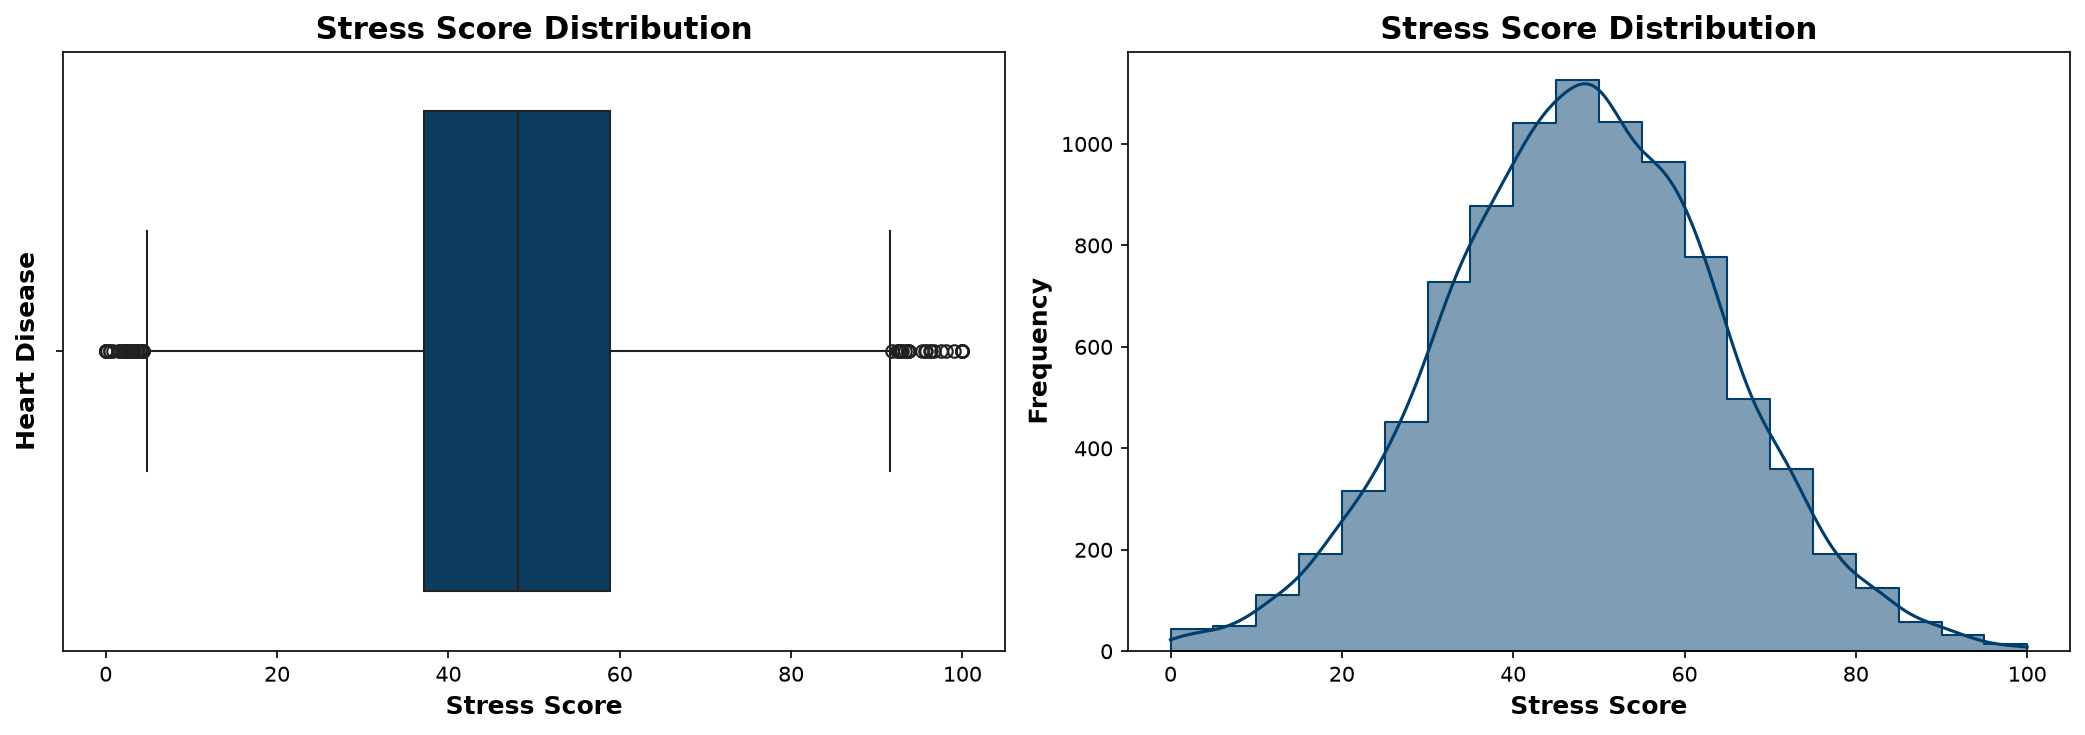

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="stress_score", ax=axes[0], color="#013e6c")

axes[0].set_title("Stress Score Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Stress Score", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="stress_score", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")
axes[1].set_title("Stress Score Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Stress Score", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [127]:
df["stress_score"].skew()

np.float64(-0.01298728507486007)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Stress Score distribution is approximately symmetric, with a very slight negative (left) skewness of -0.0129. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The mean Stress Score among the individuals studied was 47.96, with a standard deviation of 16.16. The minimum Stress Score was 0, while the maximum Stress Score was 100.

</p> 
</div>

In [128]:
values = np.array(df['stress_score'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 4.4000 or greater than 91.6000
There are 71 outliers.


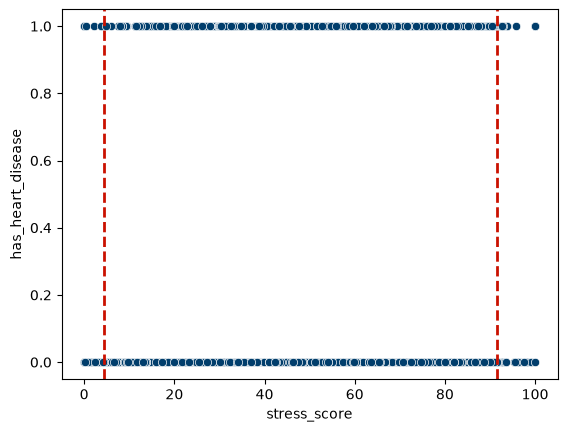

In [129]:
sns.scatterplot(data=data, x="stress_score", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {lower_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 71 statistical outliers were identified in the Stress Score variable. These observations include values below 4.4 and values above 91.6. However, these statistically unusual values were not considered erroneous observations, as very low or very high stress scores can occur naturally among individuals. Therefore, the identified outliers were retained for further analysis rather than being removed solely based on the IQR criterion.

</p> 
</div>


* #### Daily Steps

In [130]:
df["daily_steps"].describe()

count     9000.000000
mean      6163.659333
std       2170.685995
min        500.000000
25%       4658.000000
50%       6178.000000
75%       7632.750000
max      13950.000000
Name: daily_steps, dtype: float64

In [131]:
df["daily_steps"].dtype

dtype('int64')

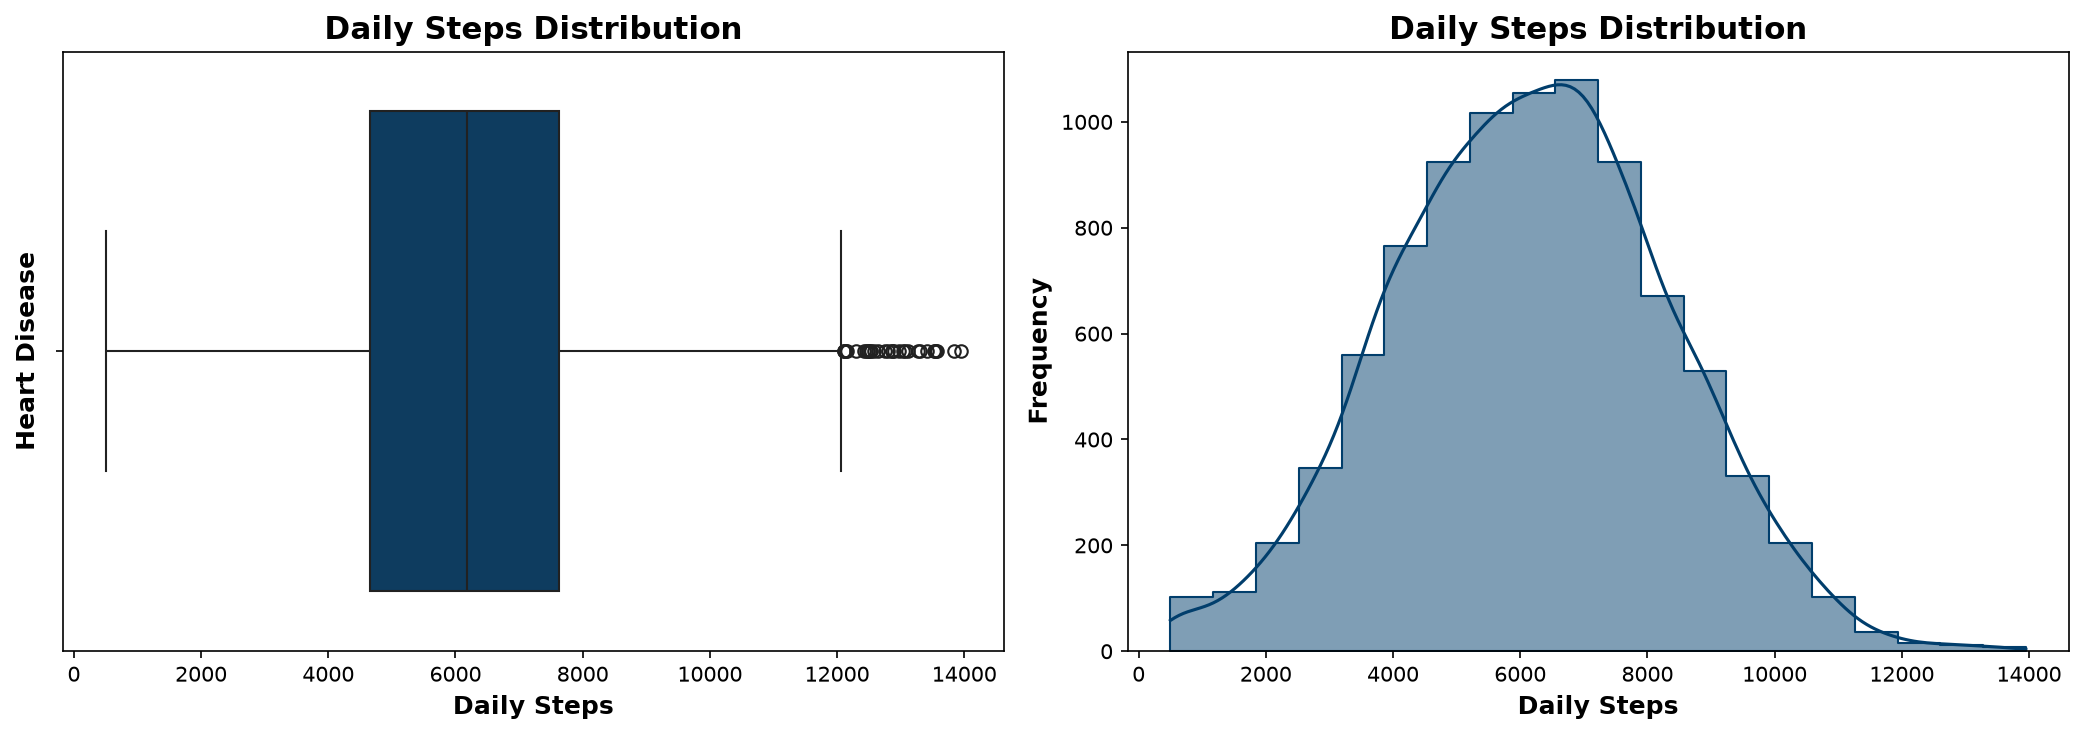

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="daily_steps", ax=axes[0], color="#013e6c")

axes[0].set_title("Daily Steps Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Daily Steps", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="daily_steps", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")
axes[1].set_title("Daily Steps Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Daily Steps", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [133]:
df["daily_steps"].skew()

np.float64(0.02488993129134241)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Daily Steps distribution is approximately symmetric, with a very slight positive (right) skewness of 0.0248. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The mean Daily Steps among the individuals studied was 6,163.65 steps, with a standard deviation of 2,170.68 steps. The minimum number of daily steps was 500, while the maximum was 13,950.


</p> 
</div>

In [134]:
values = np.array(df['daily_steps'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 195.8750 or greater than 12094.8750
There are 32 outliers.


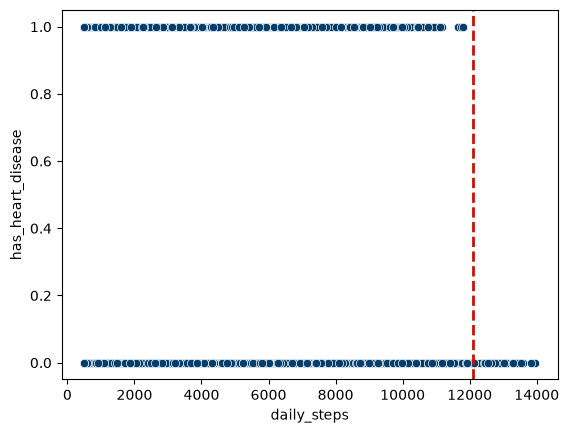

In [135]:
sns.scatterplot(data=data, x="daily_steps", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 32 high statistical outliers were identified in the Daily Steps variable. All of these observations were above the upper IQR limit. These values were retained because statistically unusual observations do not necessarily represent data errors. Higher daily step counts may reflect individuals with higher levels of physical activity or more active lifestyles. Therefore, the identified high outliers were considered potentially valid observations and were retained for further analysis.

Despite the presence of 32 high statistical outliers, the overall distribution of Daily Steps remains approximately symmetric, with a very slight positive skewness of 0.0248.
</p> 
</div>

* #### Diet Quality Score

In [136]:
df["diet_quality_score"].describe()

count    9000.000000
mean       59.467400
std        14.476064
min         4.800000
25%        49.700000
50%        59.600000
75%        69.100000
max       100.000000
Name: diet_quality_score, dtype: float64

In [137]:
df["diet_quality_score"].dtype

dtype('float64')

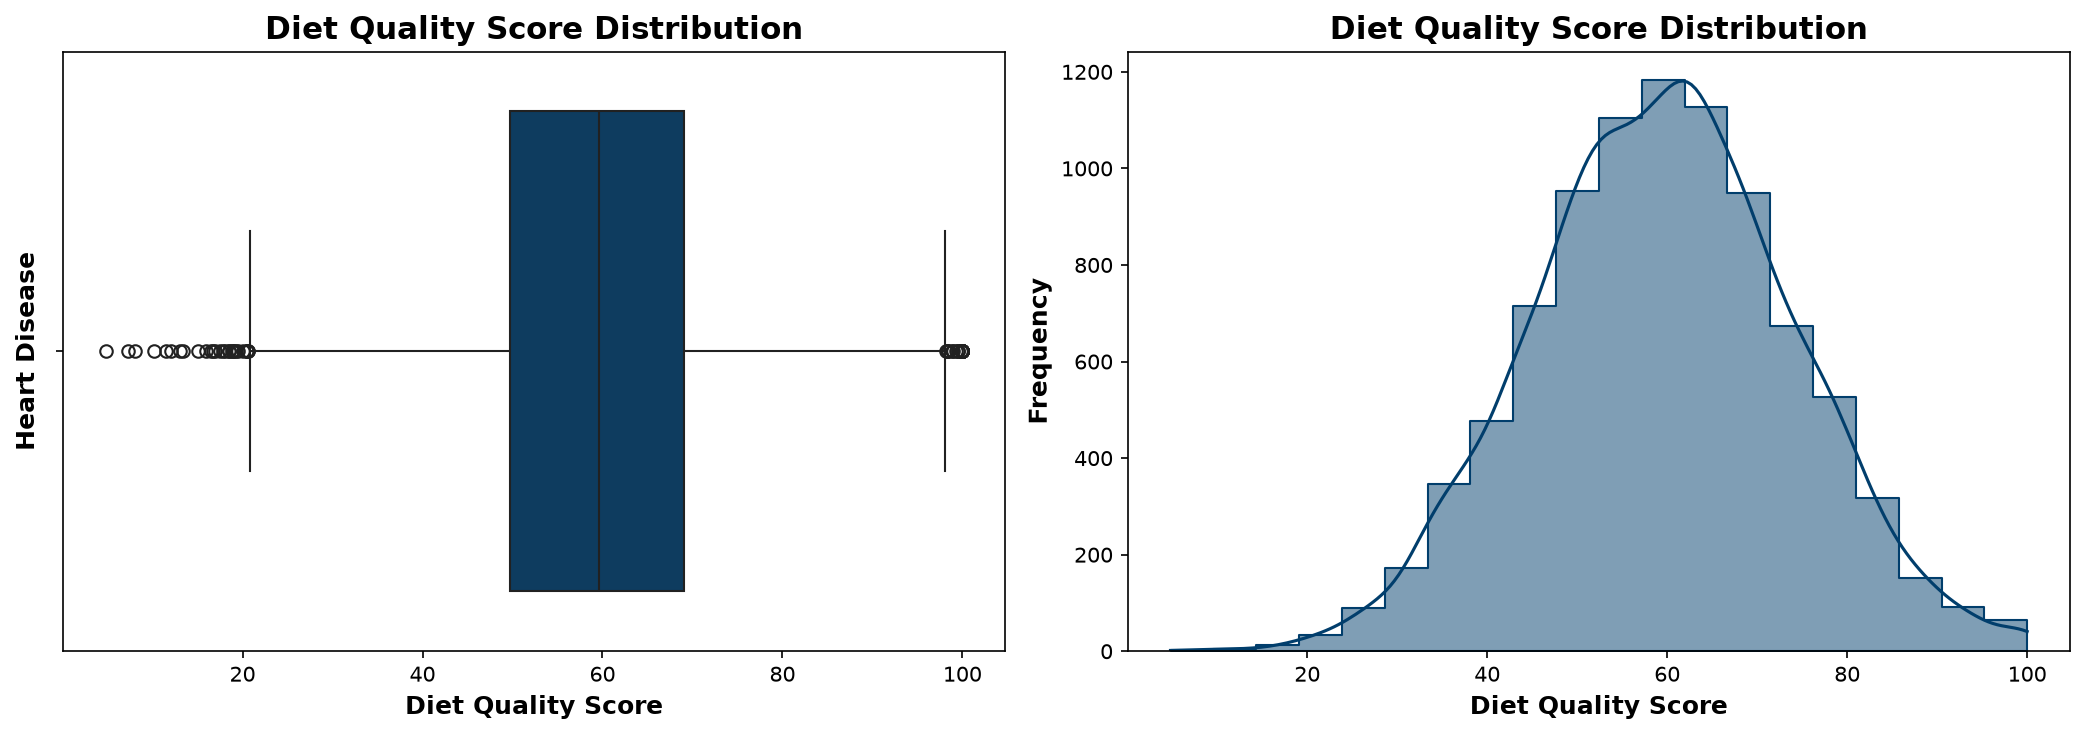

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ================= Boxplot =================
sns.boxplot(data=data, x="diet_quality_score", ax=axes[0], color="#013e6c")

axes[0].set_title("Diet Quality Score Distribution", fontsize=15, fontweight="bold")
axes[0].set_xlabel("Diet Quality Score", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Heart Disease", fontsize=12, fontweight="bold")

# ================= Histogram =================
sns.histplot(data=data, x="diet_quality_score", bins=20, kde=True, element="step", ax=axes[1], color="#013e6c")
axes[1].set_title("Diet Quality Score Distribution", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Diet Quality Score", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [139]:
df["diet_quality_score"].skew()

np.float64(0.0012270268120296553)

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The Diet Quality Score distribution is approximately symmetric, with a very slight positive (right) skewness of 0.0012. Since the skewness value is very close to zero, the distribution can be considered approximately symmetric.

The mean Diet Quality Score among the individuals studied was 59.46, with a standard deviation of 14.74. The minimum Diet Quality Score was 4.8, while the maximum was 100.



</p> 
</div>

In [140]:
values = np.array(df['diet_quality_score'])

percentile1, percentile2 = np.percentile(values, [25, 75])

bounds = percentile2 - percentile1
lower_bound = percentile1 - 1.5 * bounds
upper_bound = percentile2 + 1.5 * bounds

outliers = values[(values < lower_bound) | (values > upper_bound)]

print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 20.6000 or greater than 98.2000
There are 69 outliers.


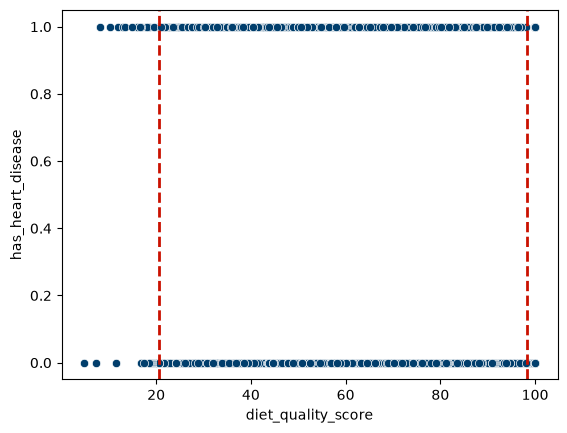

In [141]:
sns.scatterplot(data=data, x="diet_quality_score", y="has_heart_disease", color="#013e6c")
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {upper_bound:.2f}", color="#ca1100")
plt.axvline(lower_bound, linestyle="--", linewidth=2, label=f"DBP Upper: {lower_bound:.2f}", color="#ca1100")

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Using the IQR method, 69 statistical outliers were identified in the Diet Quality Score variable. These outliers include observations with scores below 20.6 and above 98.2. The presence of outliers on both sides of the distribution indicates that some individuals have unusually low or unusually high diet quality scores compared with the majority of the dataset.

However, these observations were retained because statistically unusual values do not necessarily represent data errors. Very low or very high diet quality scores can occur naturally due to differences in individuals' dietary habits. Therefore, the identified outliers were considered potentially valid observations and were retained for further analysis.
</p> 
</div>


### Categoricall Features

* #### SEX

In [142]:
df["sex"].describe()

count     9000
unique       2
top       Male
freq      4731
Name: sex, dtype: object

In [143]:
print(df["sex"].dtype)

str


In [144]:
print(df["sex"].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [145]:
print(df["sex"].value_counts())

sex
Male      4731
Female    4269
Name: count, dtype: int64


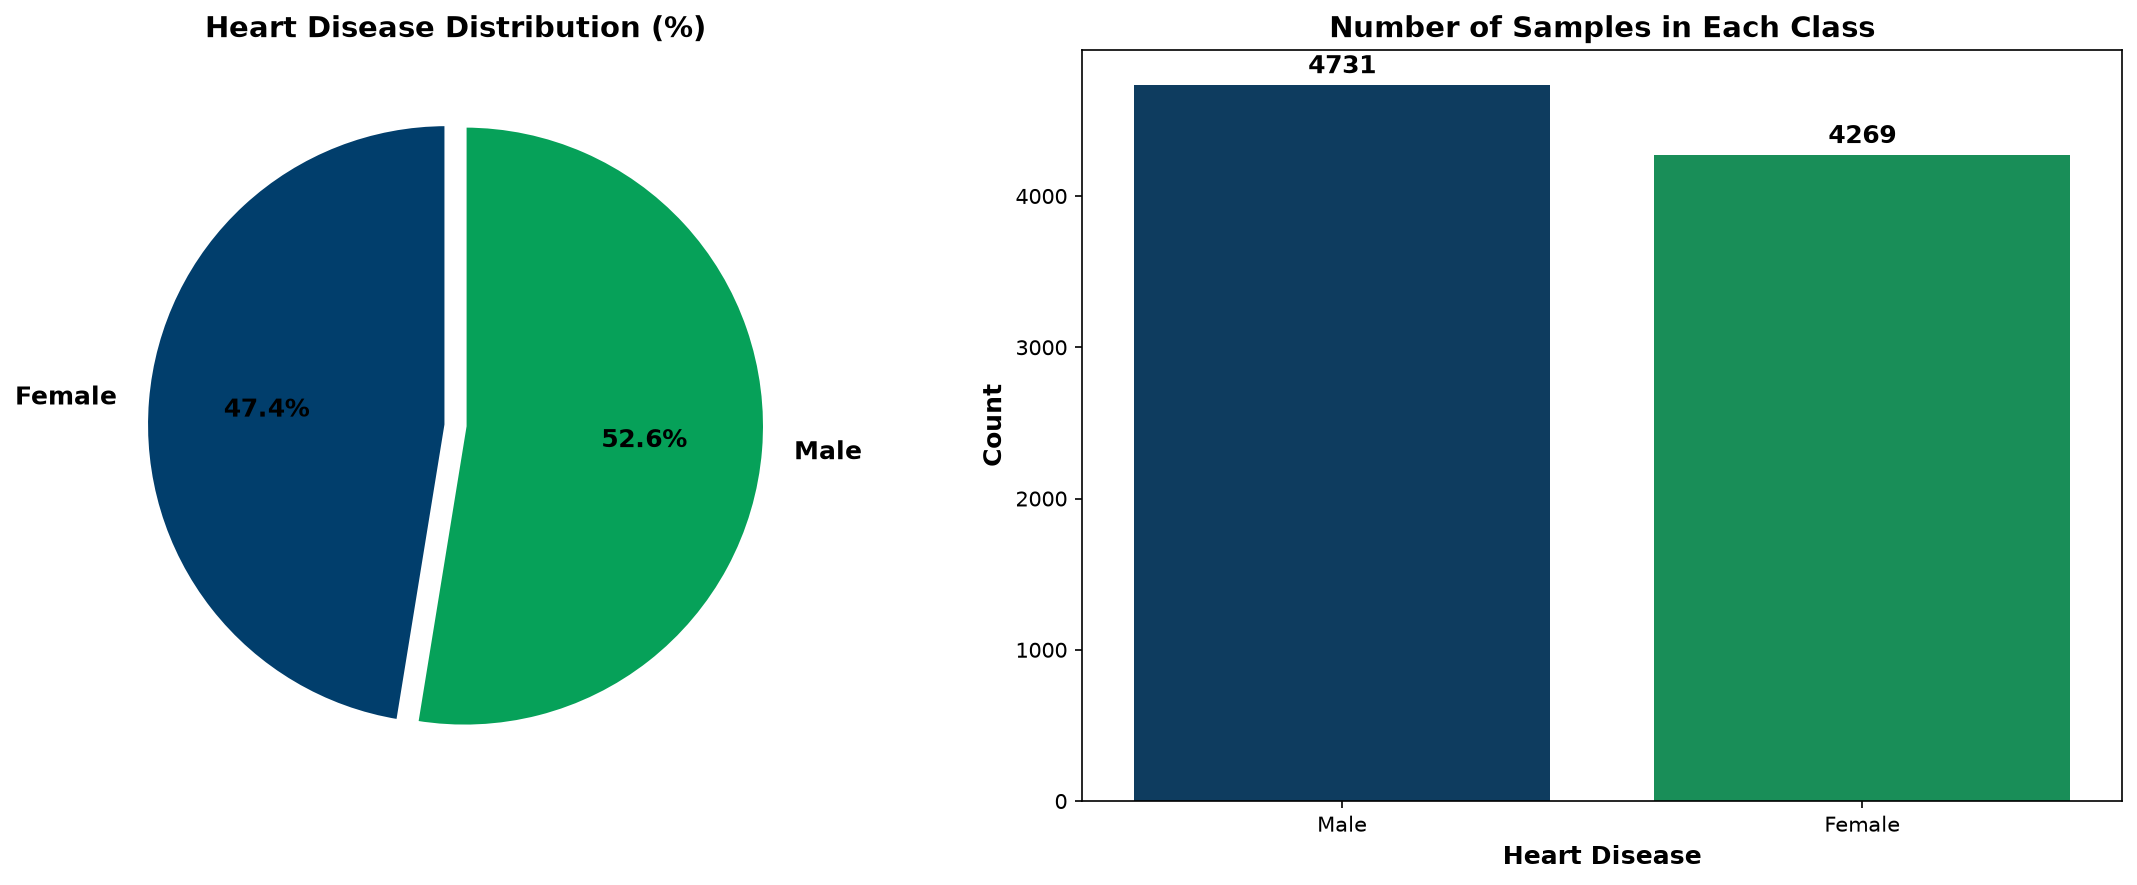

In [146]:
column = "sex"

counts = data[column].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"{i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=column, hue=column, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

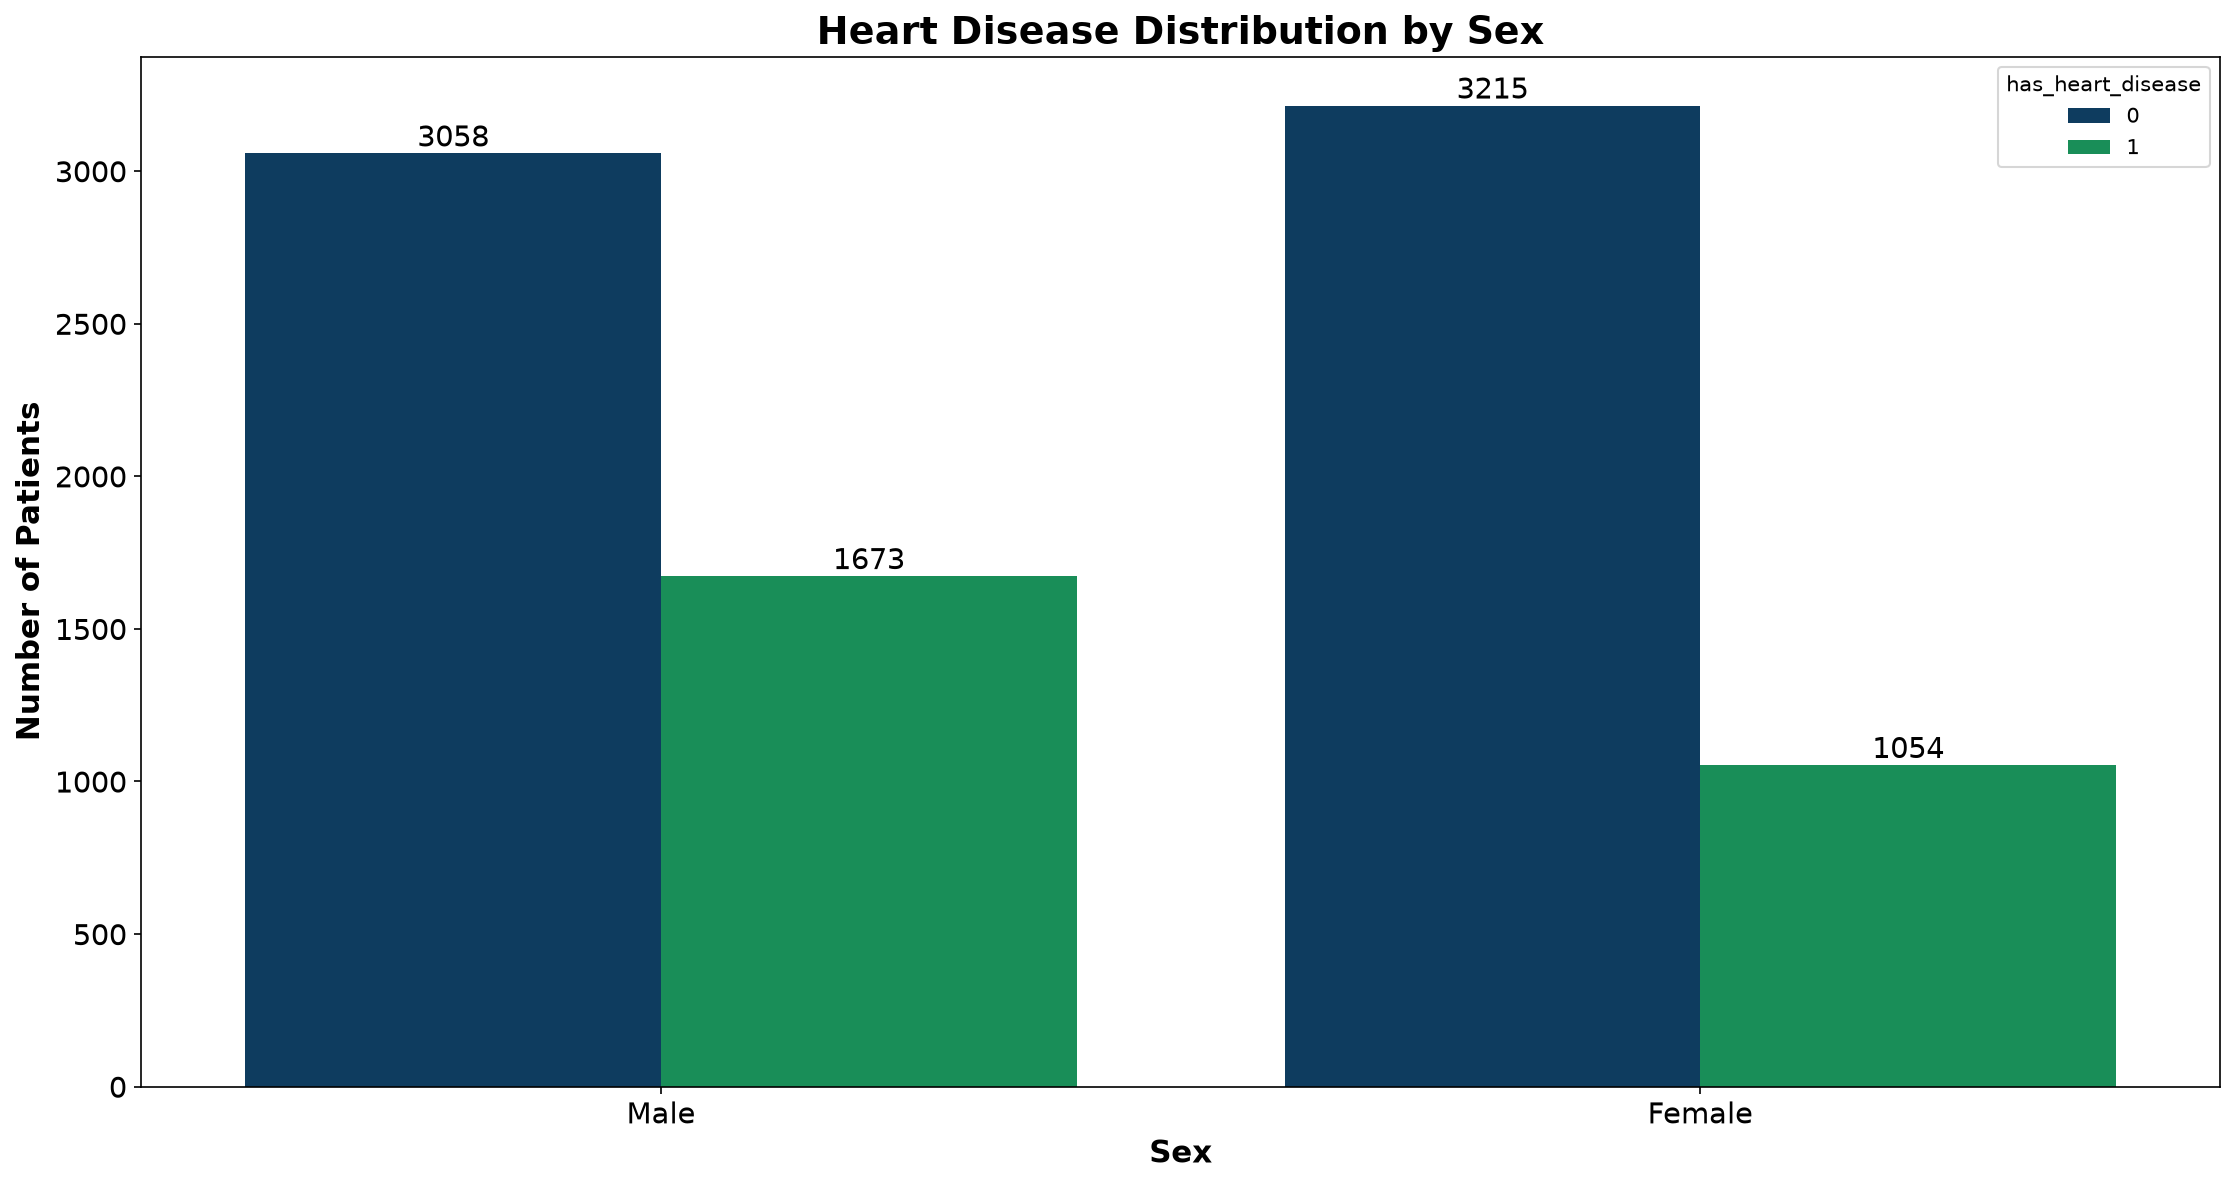

In [147]:
plt.figure(figsize=(15, 8), dpi=150)

ax = sns.countplot(data=df, x="sex", hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Sex", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=15, fontweight="bold")
plt.title("Heart Disease Distribution by Sex", fontsize=18, fontweight="bold")
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The sex feature contains two categories: Male and Female. Male participants represent the majority of the dataset, with 4,731 individuals (52.57%), while Female participants account for 4,269 individuals (47.43%). The data type of this feature is string.

</p> 
</div>

* #### Chest Pain Type

In [148]:
df["chest_pain_type"].describe()

count             9000
unique               4
top       Asymptomatic
freq              4265
Name: chest_pain_type, dtype: object

In [149]:
print(df["chest_pain_type"].dtype)

str


In [150]:
print(df["chest_pain_type"].unique())

<StringArray>
['Asymptomatic', 'Non-Anginal Pain', 'Atypical Angina', 'Typical Angina']
Length: 4, dtype: str


In [151]:
print(df["chest_pain_type"].value_counts())

chest_pain_type
Asymptomatic        4265
Non-Anginal Pain    2141
Atypical Angina     1576
Typical Angina      1018
Name: count, dtype: int64


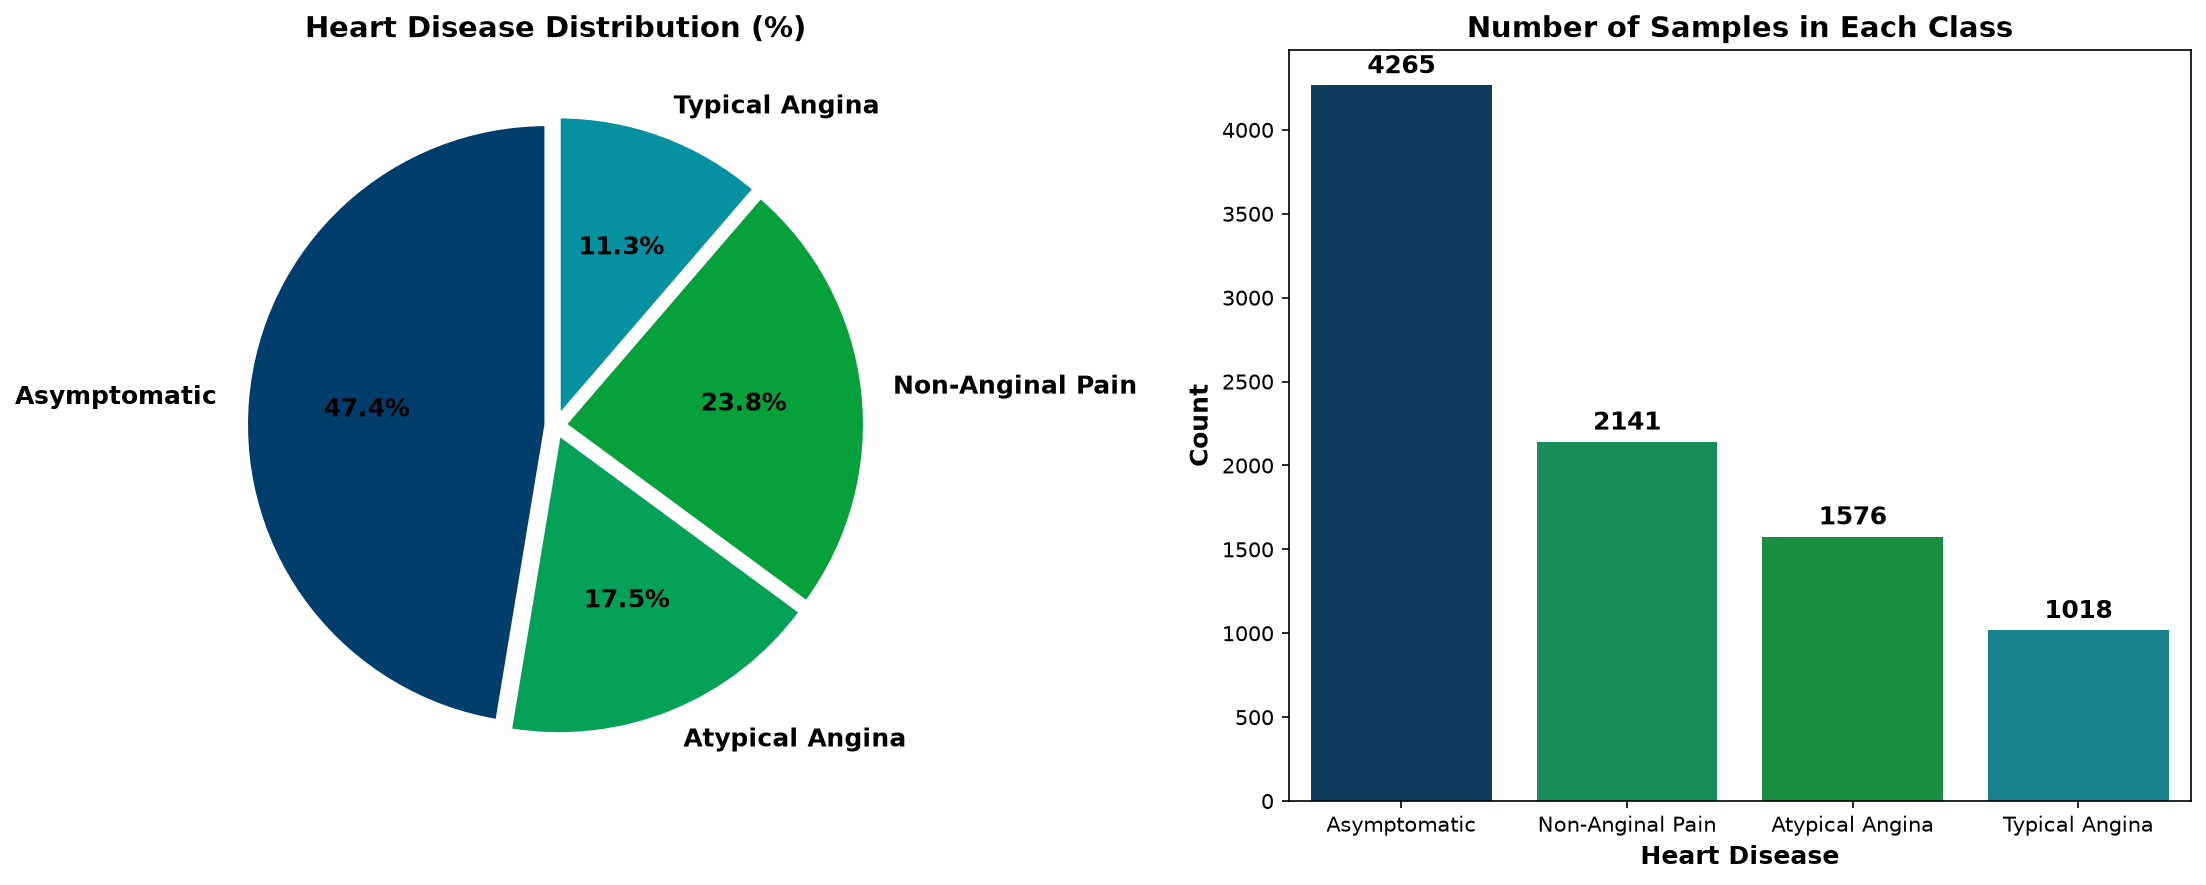

In [152]:
column = "chest_pain_type"

counts = data[column].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159", "#06A13A", "#0691A1"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"{i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=column, hue=column, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

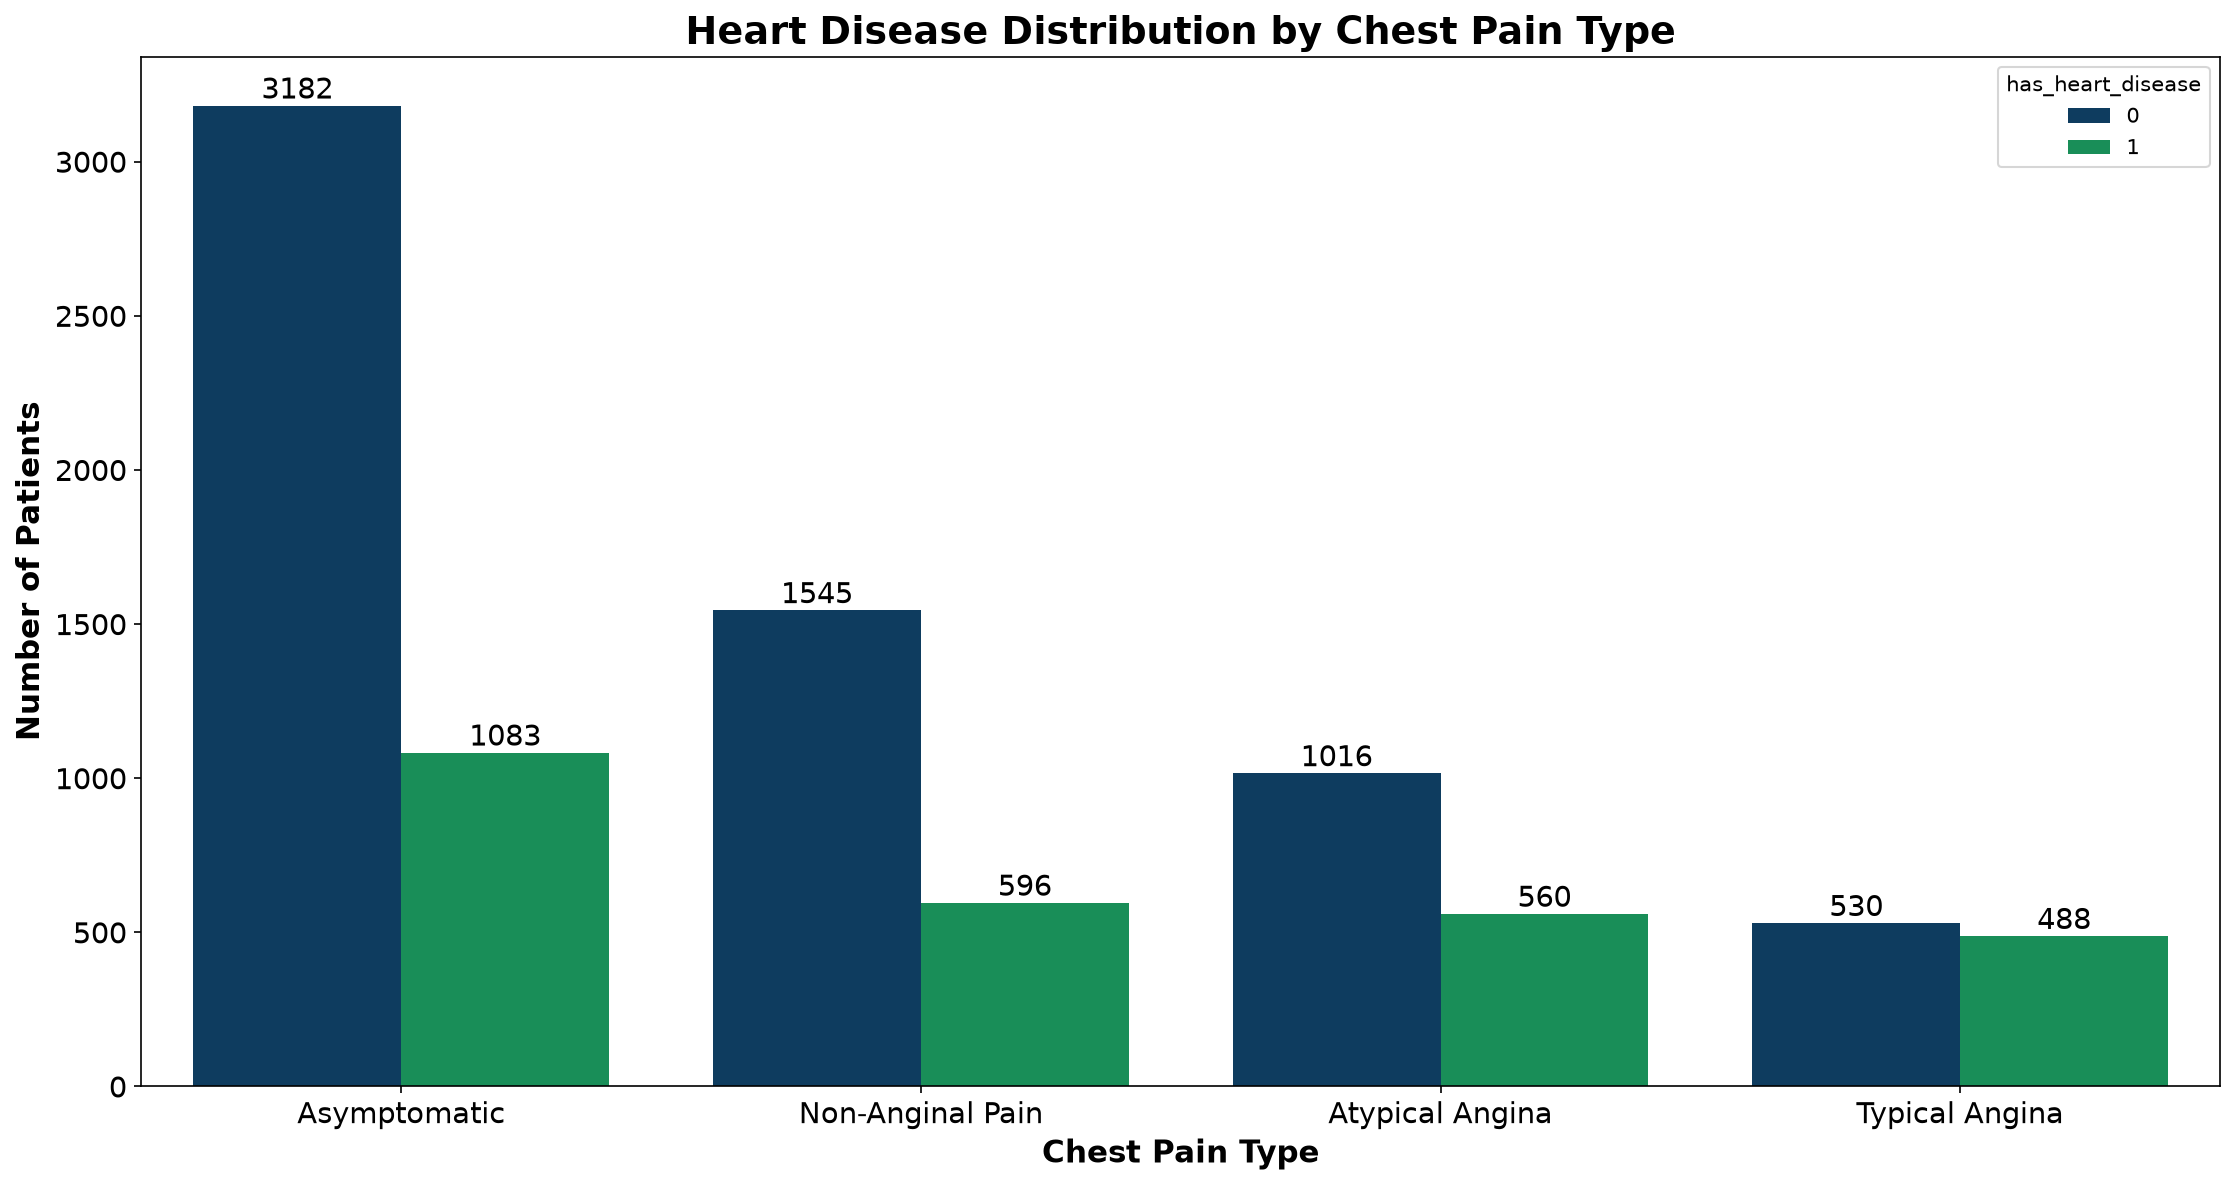

In [153]:
plt.figure(figsize=(15, 8), dpi=150)

ax = sns.countplot(data=df, x="chest_pain_type", hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Chest Pain Type", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=15, fontweight="bold")
plt.title("Heart Disease Distribution by Chest Pain Type", fontsize=18, fontweight="bold")
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p>
The chest_pain_type feature contains four categories: Asymptomatic, Non-Anginal Pain, Atypical Angina, and Typical Angina. The most frequent category is Asymptomatic, with 4,265 individuals, followed by Non-Anginal Pain with 2,141 individuals, Atypical Angina with 1,576 individuals, and Typical Angina with 1,018 individuals.

Overall, Asymptomatic individuals represent the largest group in the dataset, while Typical Angina is the least frequent category. These categories describe different patterns of chest pain and are clinically relevant when assessing cardiovascular risk.

The data type of this feature is string.

</p> 
</div>

* #### Exercise Induced Angina

In [154]:
df["exercise_induced_angina"].describe()

count      9000
unique        2
top       False
freq       6938
Name: exercise_induced_angina, dtype: object

In [155]:
print(df["exercise_induced_angina"].dtype)

bool


In [156]:
print(df["exercise_induced_angina"].unique())

[False  True]


In [157]:
print(df["exercise_induced_angina"].value_counts())

exercise_induced_angina
False    6938
True     2062
Name: count, dtype: int64


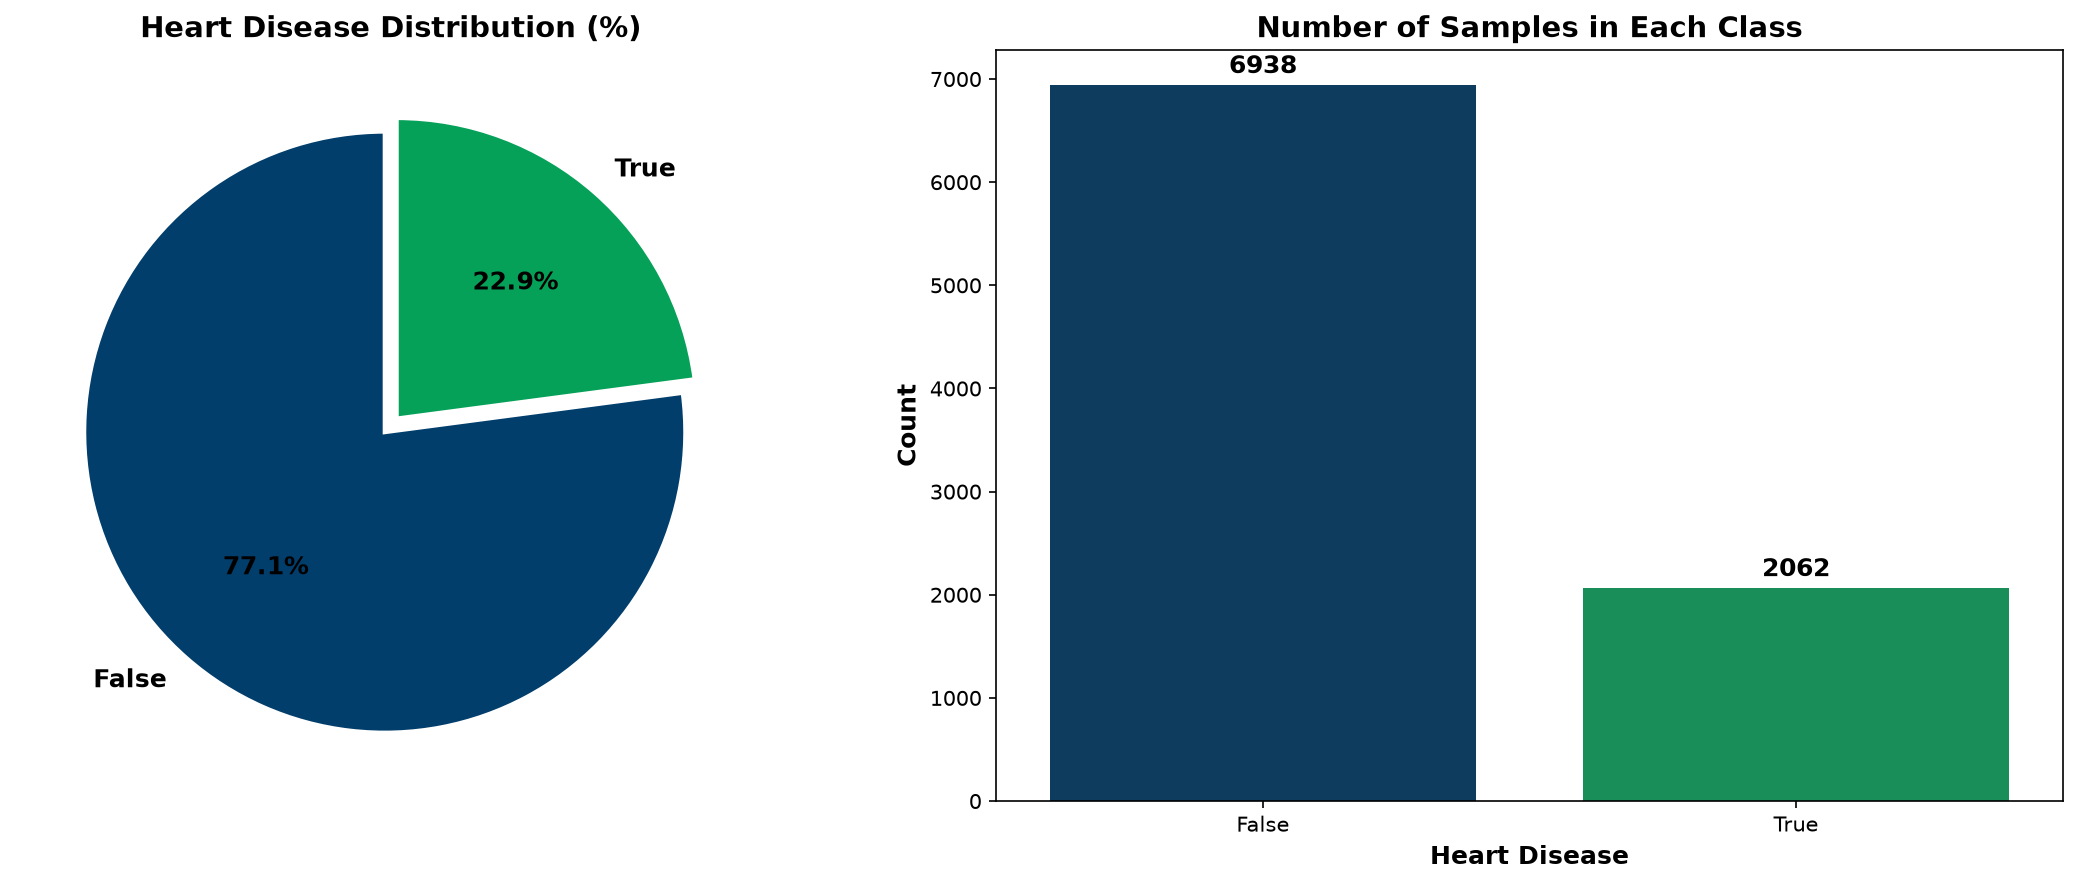

In [158]:
column = "exercise_induced_angina"

counts = data[column].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"{i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=column, hue=column, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

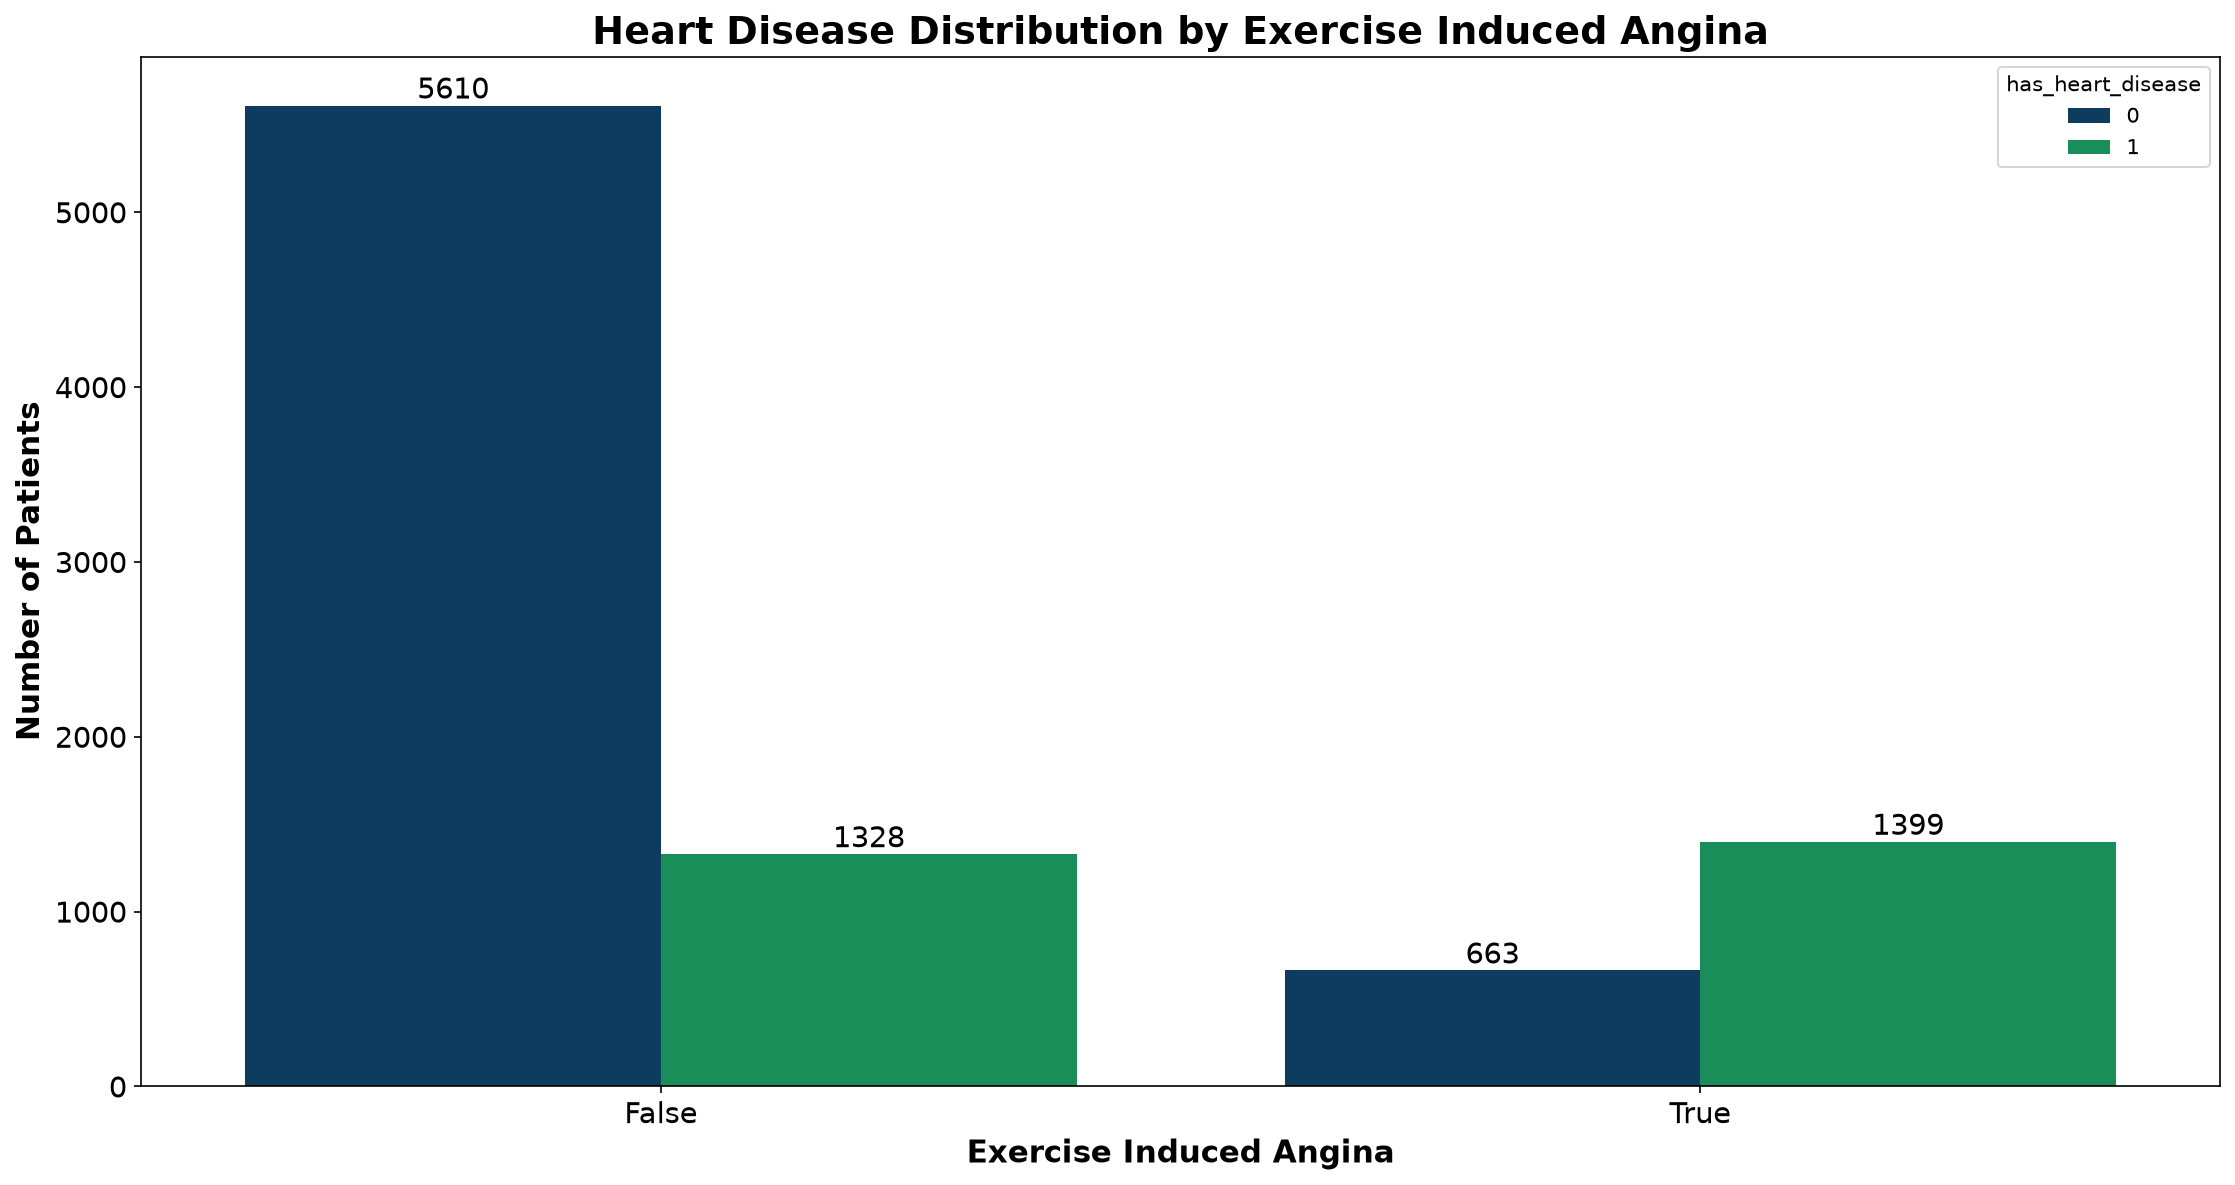

In [159]:
plt.figure(figsize=(15, 8), dpi=150)

ax = sns.countplot(data=df, x="exercise_induced_angina", hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Exercise Induced Angina", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=15, fontweight="bold")
plt.title("Heart Disease Distribution by Exercise Induced Angina", fontsize=18, fontweight="bold")
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p>
The exercise_induced_angina feature is a binary variable with two categories: False and True. Among the 9,000 individuals, 6,938 (77.09%) did not experience exercise-induced angina, while 2,062 (22.91%) experienced angina during exercise. Therefore, the majority of individuals in the dataset did not have exercise-induced angina.

This feature is clinically relevant because exercise-induced angina can be associated with myocardial ischemia and may provide useful information when assessing the risk of heart disease.
</p> 
</div>

* #### Family History

In [160]:
df["family_history"].describe()

count      9000
unique        2
top       False
freq       6548
Name: family_history, dtype: object

In [161]:
print(df["family_history"].dtype)

bool


In [162]:
print(df["family_history"].unique())

[False  True]


In [163]:
print(df["family_history"].value_counts())

family_history
False    6548
True     2452
Name: count, dtype: int64


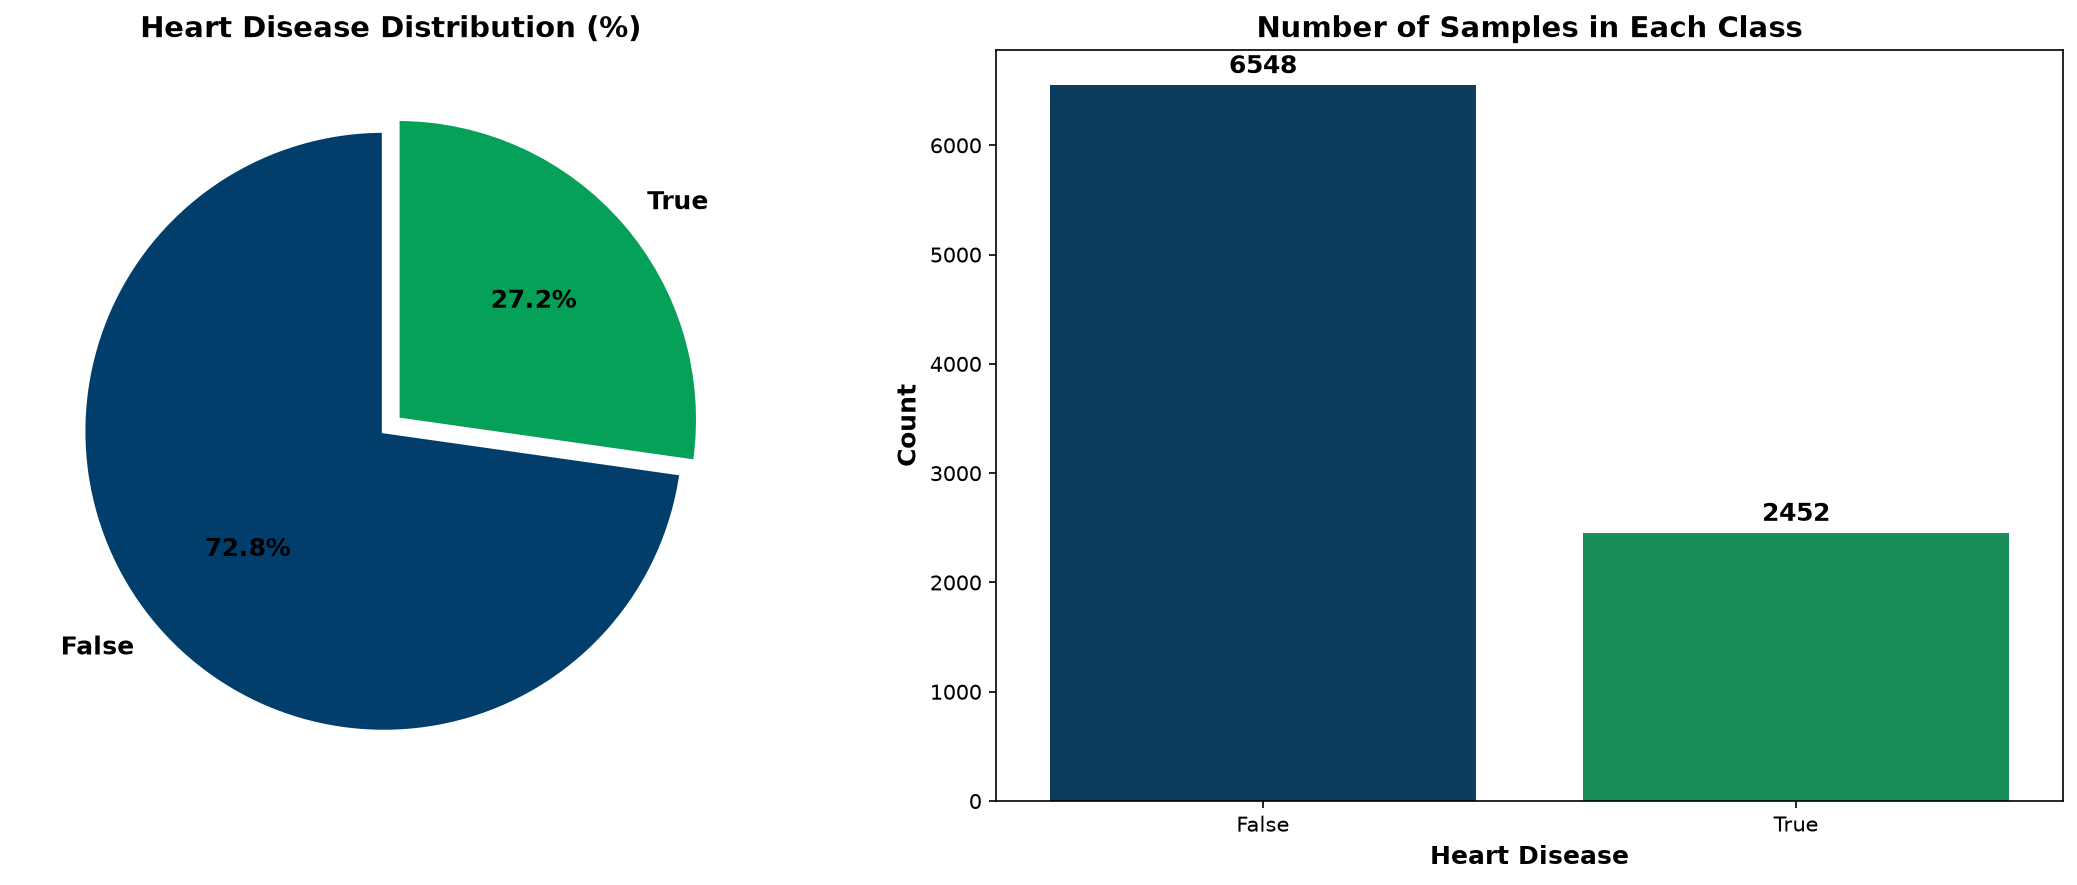

In [164]:
column = "family_history"

counts = data[column].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"{i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=column, hue=column, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

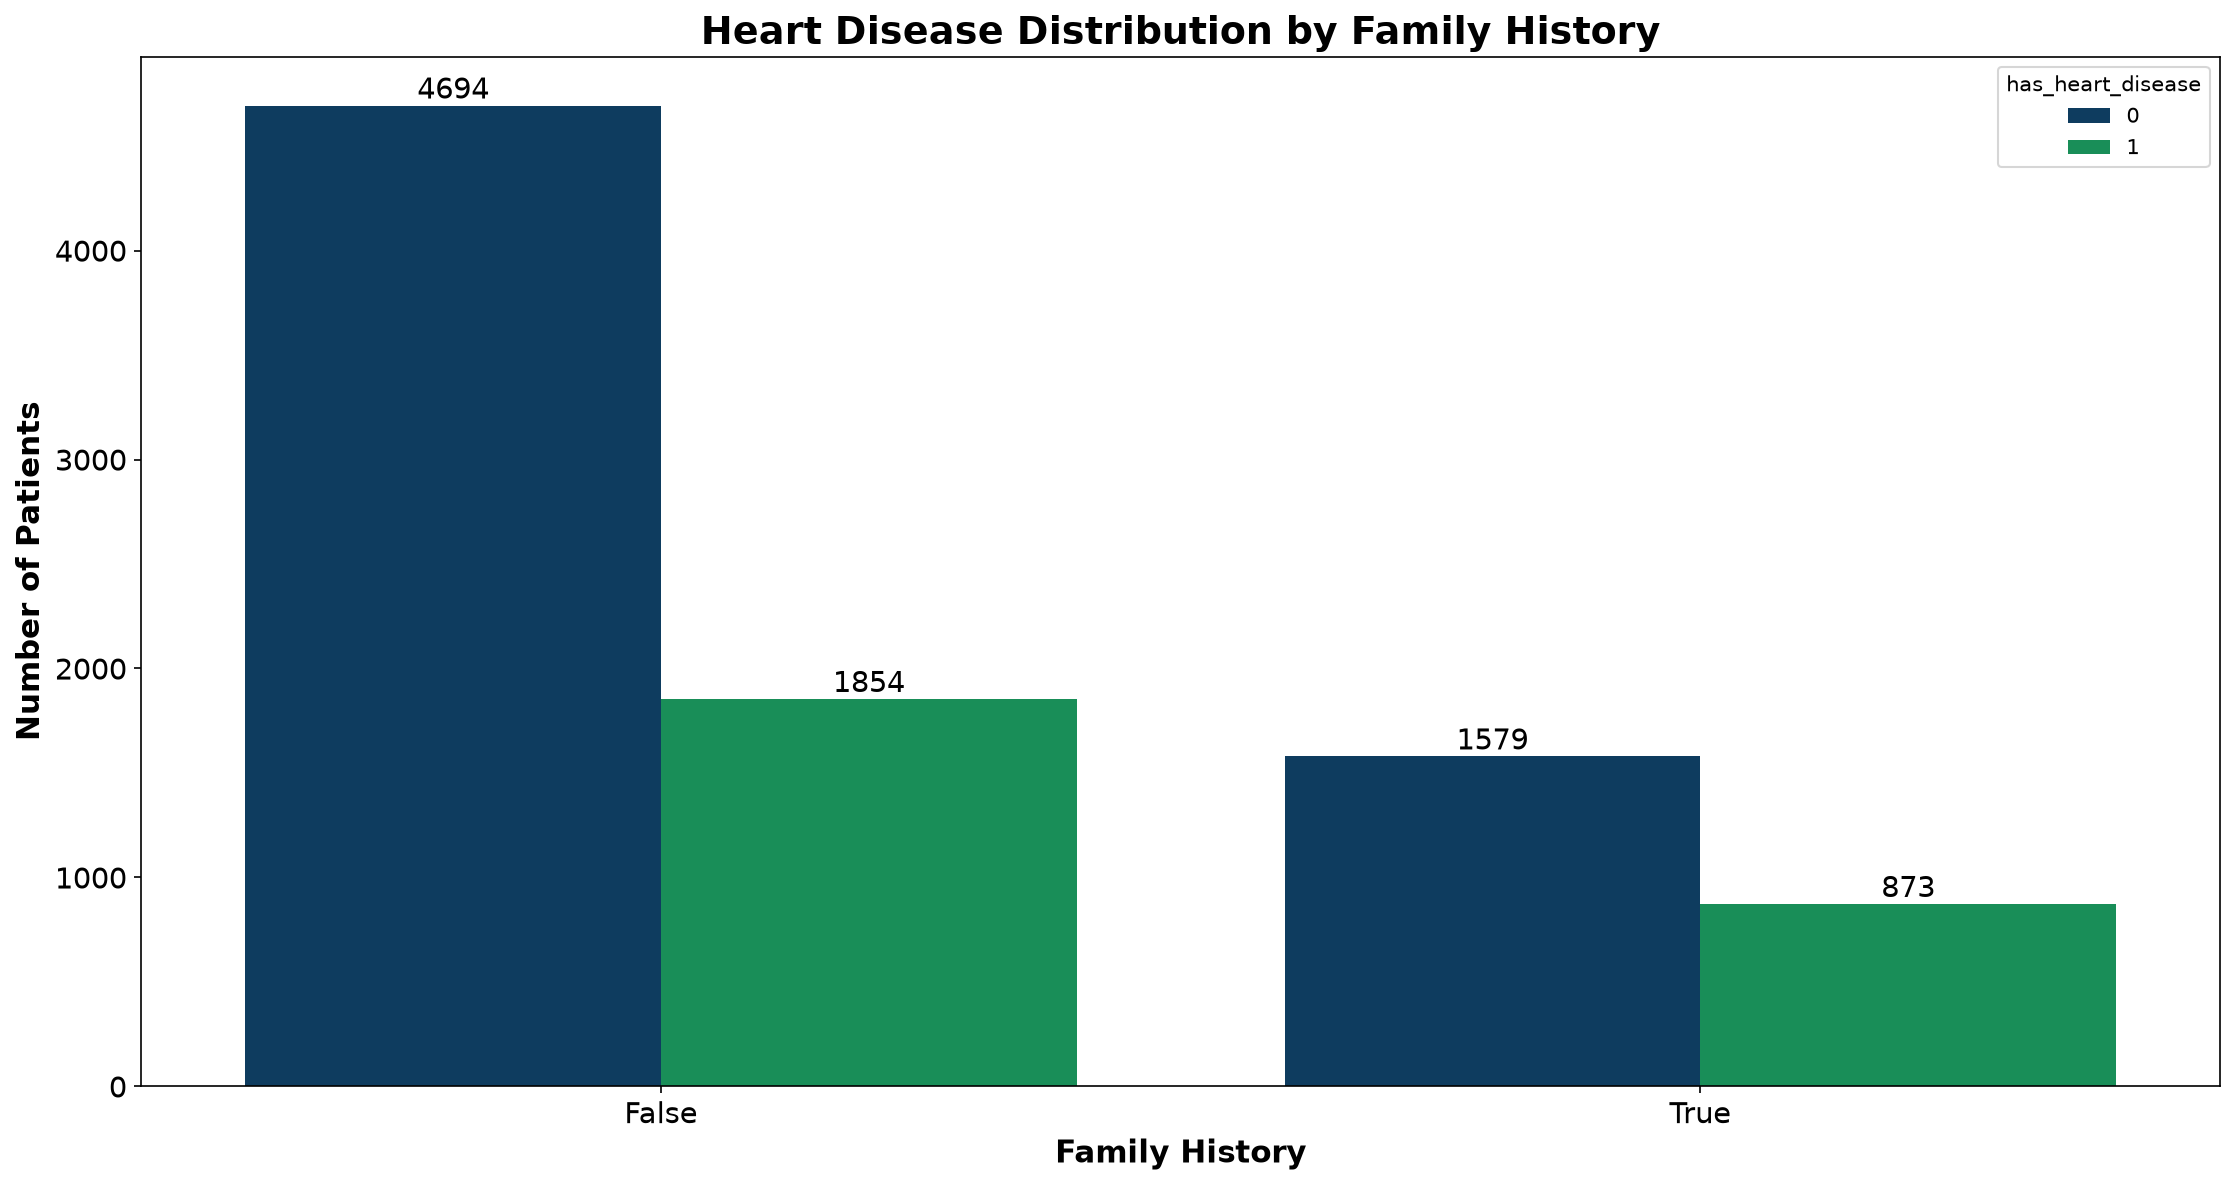

In [165]:
plt.figure(figsize=(15, 8), dpi=150)

ax = sns.countplot(data=df, x="family_history", hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Family History", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=15, fontweight="bold")
plt.title("Heart Disease Distribution by Family History", fontsize=18, fontweight="bold")
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p>
The family_history feature is a binary Boolean variable with two categories: False and True. Among the 9,000 individuals, 6,548 (72.76%) had no reported family history of heart disease, while 2,452 (27.24%) had a positive family history. Therefore, the majority of individuals in the dataset did not have a reported family history of heart disease.

Family history is an important cardiovascular risk factor because having close relatives with cardiovascular disease may be associated with a higher risk of developing heart disease. However, family history alone does not determine whether an individual has heart disease.
</p> 
</div>

* #### Smoker Status

In [166]:
df["smoker_status"].describe()

count      9000
unique        3
top       Never
freq       4980
Name: smoker_status, dtype: object

In [167]:
print(df["smoker_status"].dtype)

str


In [168]:
print(df["smoker_status"].unique())

<StringArray>
['Never', 'Current', 'Former']
Length: 3, dtype: str


In [169]:
print(df["smoker_status"].value_counts())

smoker_status
Never      4980
Former     2448
Current    1572
Name: count, dtype: int64


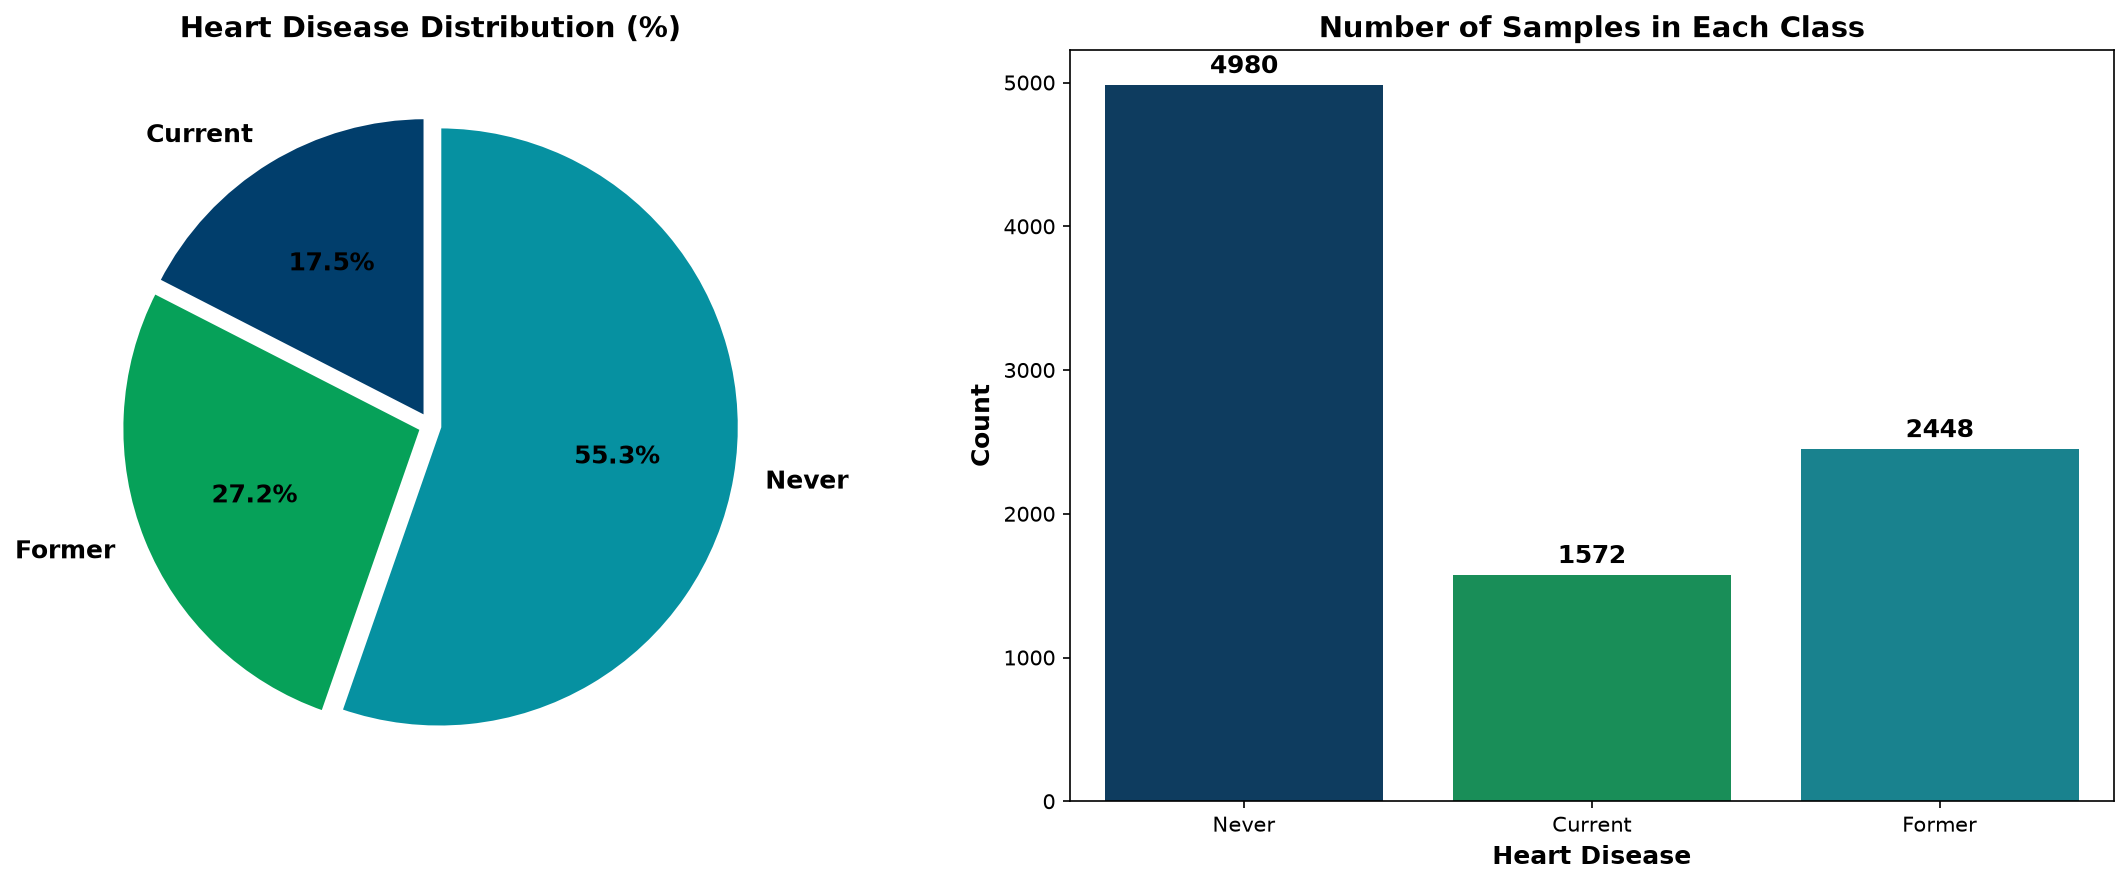

In [170]:
column = "smoker_status"

counts = data[column].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159", "#0691A1"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"{i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=column, hue=column, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

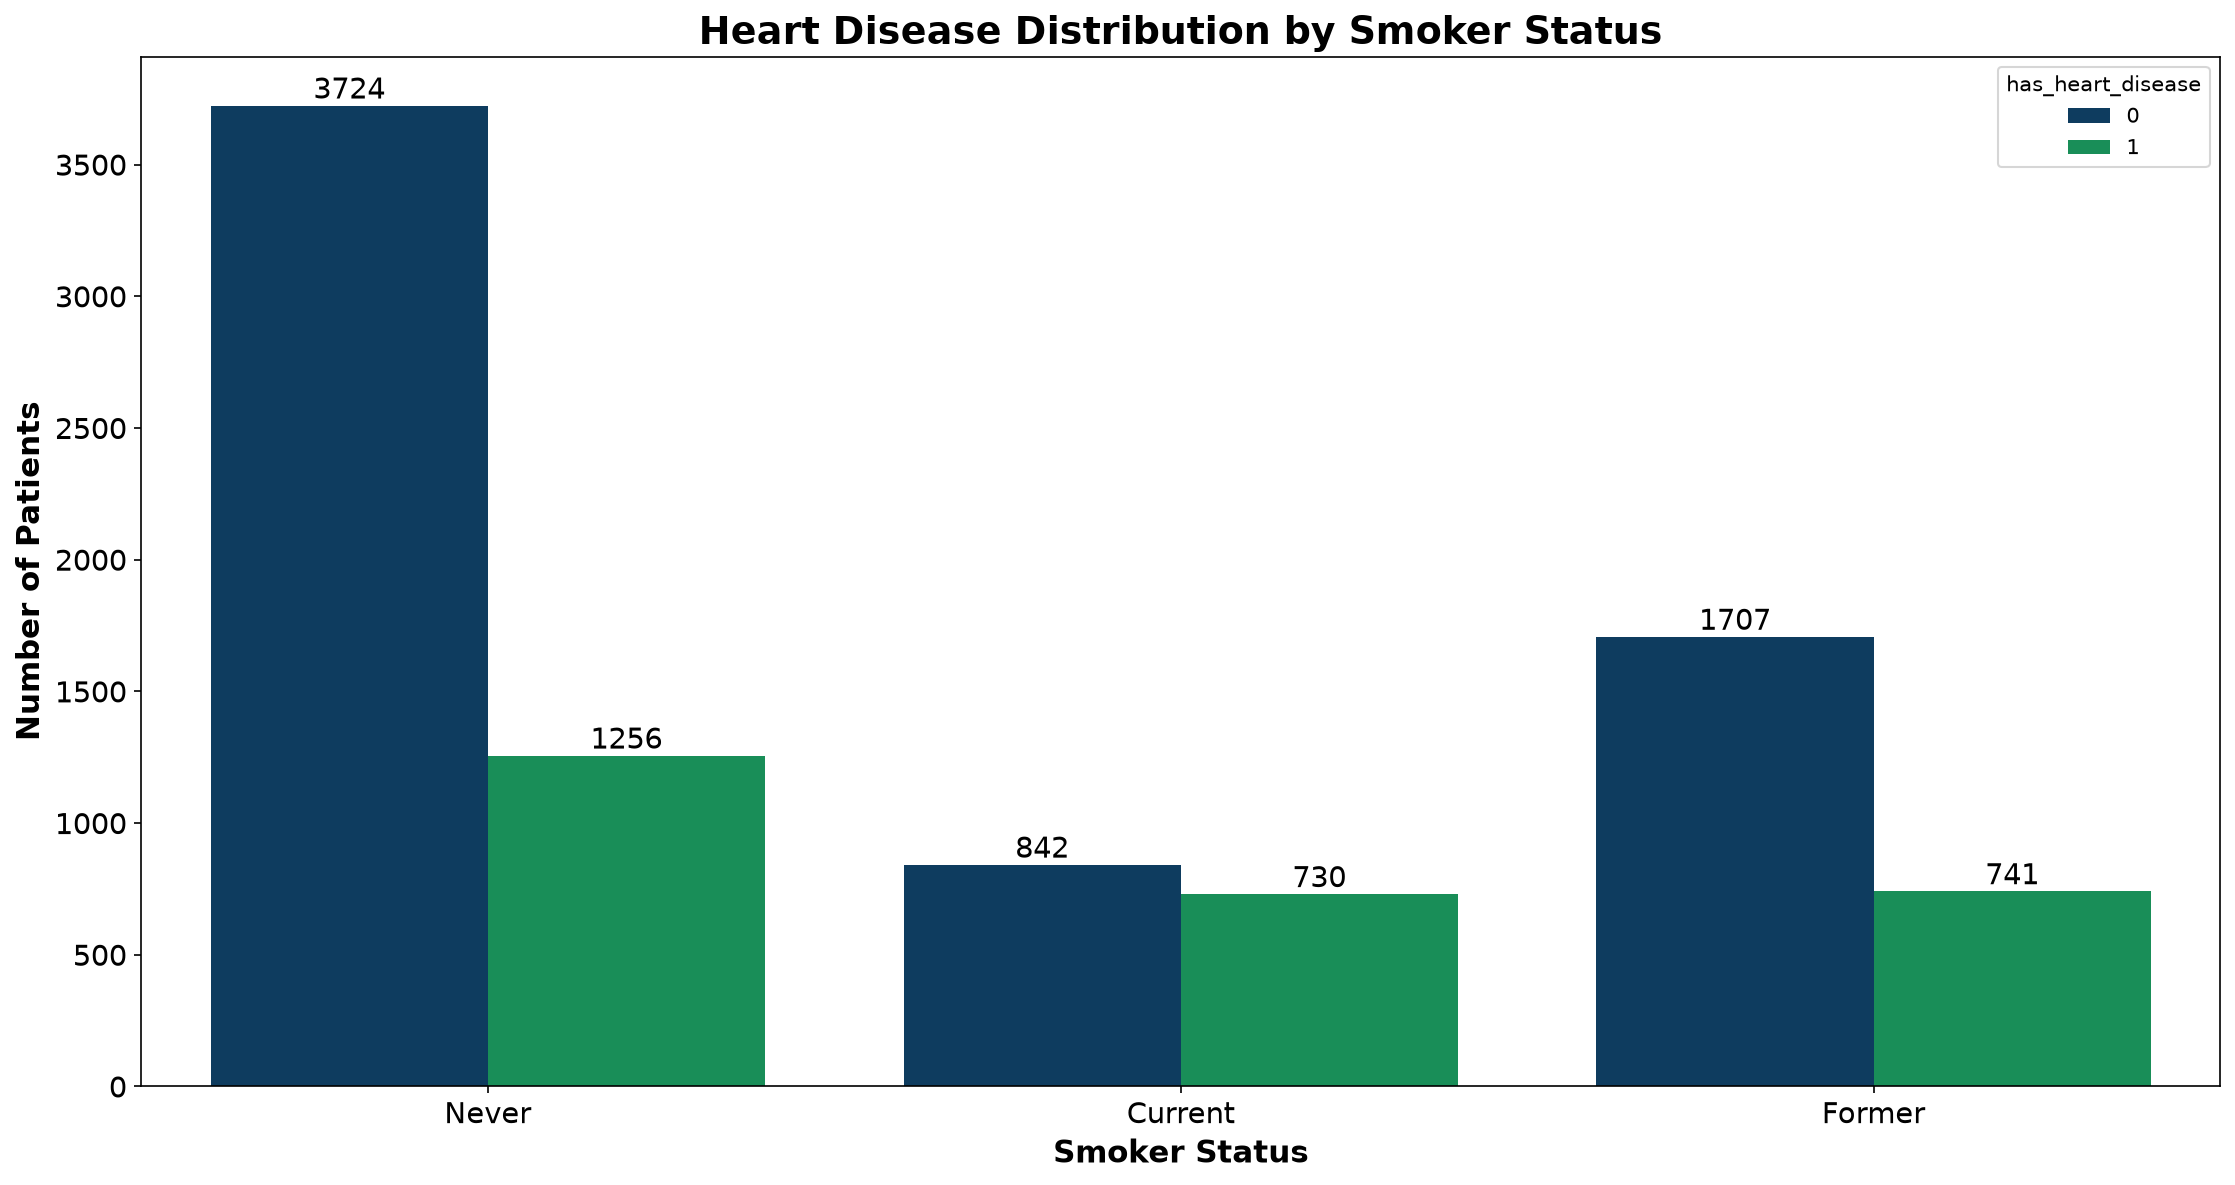

In [171]:
plt.figure(figsize=(15, 8), dpi=150)

ax = sns.countplot(data=df, x="smoker_status", hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Smoker Status", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=15, fontweight="bold")
plt.title("Heart Disease Distribution by Smoker Status", fontsize=18, fontweight="bold")
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p>
The smoker_status feature is a categorical string variable with three categories: Never, Former, and Current. Among the 9,000 individuals, 4,980 (55.33%) were never smokers, 2,448 (27.20%) were former smokers, and 1,572 (17.47%) were current smokers. Therefore, the majority of individuals in the dataset were never smokers, while current smokers represented the smallest group.

Smoking status is an important cardiovascular risk factor and can provide valuable information when analyzing heart disease risk. However, smoking status alone does not determine whether an individual has heart disease.

</p> 
</div>

* #### Wearable Owner

In [172]:
df["wearable_owner"].describe()

count      9000
unique        2
top       False
freq       5015
Name: wearable_owner, dtype: object

In [173]:
print(df["wearable_owner"].dtype)

bool


In [174]:
print(df["wearable_owner"].unique())

[ True False]


In [175]:
print(df["wearable_owner"].value_counts())

wearable_owner
False    5015
True     3985
Name: count, dtype: int64


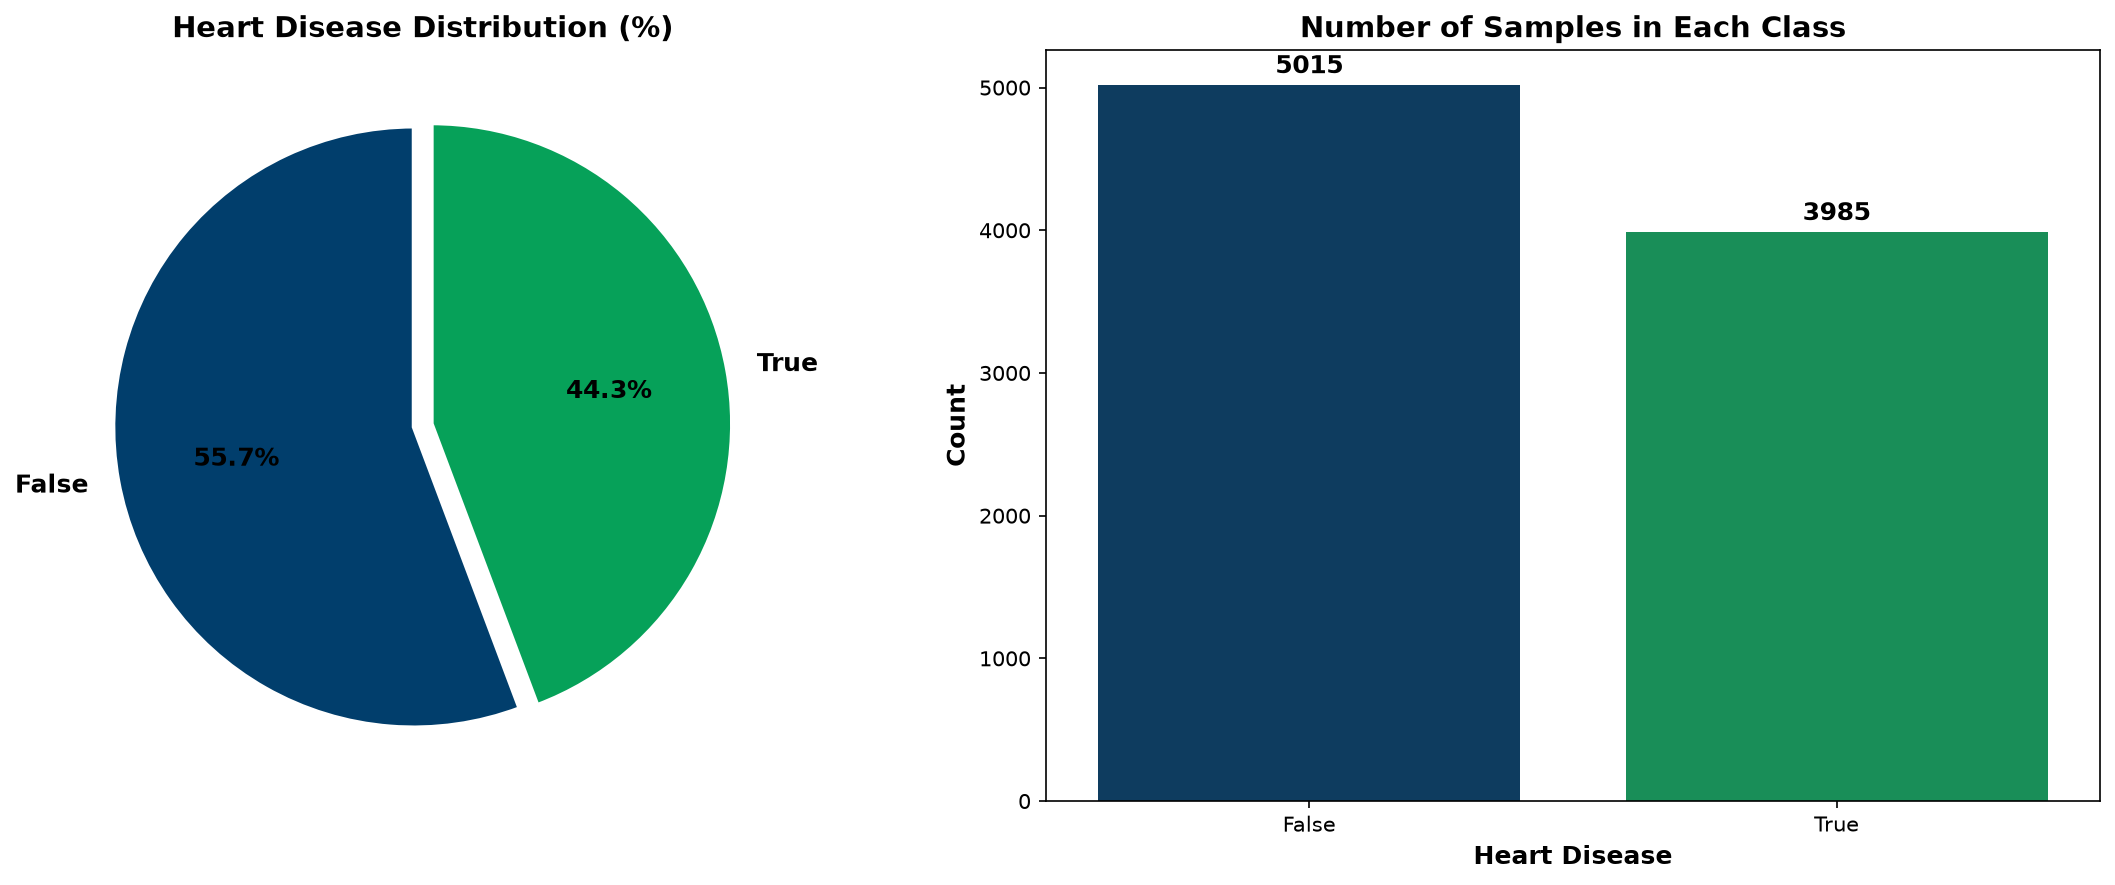

In [176]:
column = "wearable_owner"

counts = data[column].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)
colors = ["#013e6c", "#06A159"]

# ================= Pie Chart =================
axes[0].pie(counts, labels=[f"{i}" for i in counts.index], autopct="%1.1f%%", startangle=90, explode=[0.03] * len(counts), wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12, "fontweight":"bold"}, colors=colors)

axes[0].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight="bold")

# ================= Count Plot =================
sns.countplot(data=data, x=column, hue=column, palette=colors, legend=False, ax=axes[1])

axes[1].set_title("Number of Samples in Each Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Heart Disease", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

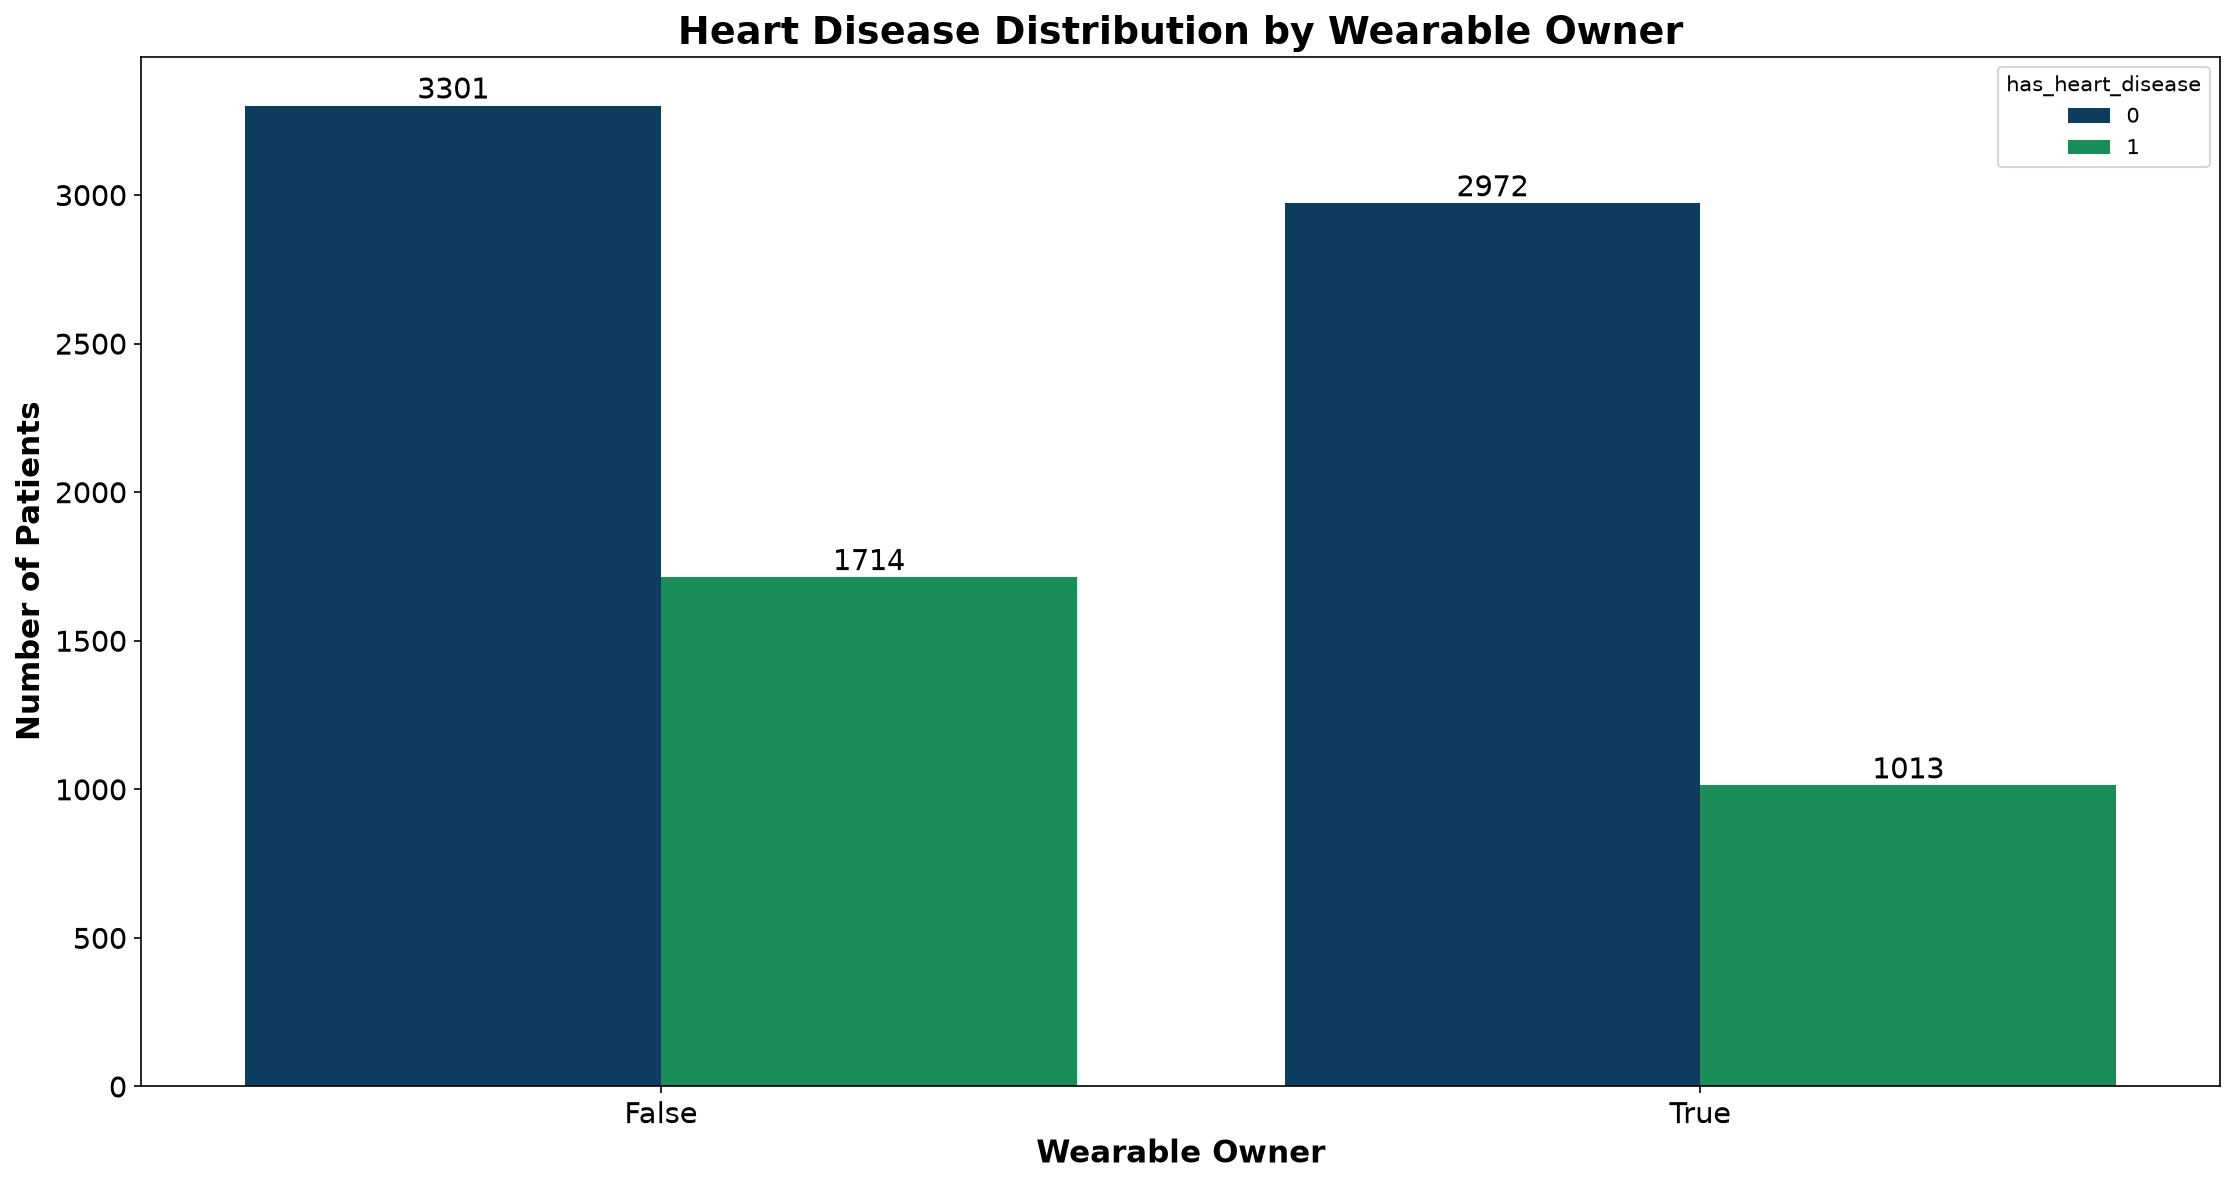

In [177]:
plt.figure(figsize=(15, 8), dpi=150)

ax = sns.countplot(data=df, x="wearable_owner", hue="has_heart_disease", palette=["#013e6c", "#06A159"])

plt.xlabel("Wearable Owner", fontsize=15, fontweight="bold")
plt.ylabel("Number of Patients", fontsize=15, fontweight="bold")
plt.title("Heart Disease Distribution by Wearable Owner", fontsize=18, fontweight="bold")
plt.tick_params(axis="x", labelsize=14)
plt.tick_params(axis="y", labelsize=14)

for container in ax.containers:
    ax.bar_label(container, fontsize=14)

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p>
The `wearable_owner` feature is a binary Boolean variable with two categories: False and True. Among the 9,000 individuals, 5,015 (55.72%) did not own a wearable device, while 3,985 (44.28%) owned a wearable device. Therefore, the majority of individuals in the dataset did not own a wearable device.

Wearable device ownership is included as a lifestyle and activity-related feature and may provide additional information about individuals' activity patterns. However, wearable ownership itself does not directly indicate the presence or absence of heart disease.
</p> 
</div>


* #### Categorical Feature Encoding

In [178]:
df["sex"] = df["sex"].replace({"Female": 2, "Male": 4})

df["chest_pain_type"] = df["chest_pain_type"].replace({"Asymptomatic": 2, "Non-Anginal Pain": 3, "Atypical Angina": 4, "Typical Angina": 5})

df["family_history"] = df["family_history"].replace({False: 2, True: 4})

df["exercise_induced_angina"] = df["exercise_induced_angina"].replace({False: 2, True: 4})

df["smoker_status"] = df["smoker_status"].replace({"Never": 2, "Former": 4, "Current": 6})

df["wearable_owner"] = df["wearable_owner"].replace({False: 2, True: 4})
df

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,4,117,74,193,57,106,119,112,5.2,...,2,2,2.9,86,5.4,19.8,4,7731,62.9,0
1,57,4,139,94,185,69,110,35,114,5.9,...,2,2,3.0,132,4.3,45.8,4,2629,74.6,1
2,29,4,128,78,197,52,108,157,95,5.5,...,2,6,3.5,128,5.1,17.7,4,9290,65.7,0
3,72,4,132,86,197,59,104,143,92,4.8,...,2,2,2.7,18,6.8,63.6,4,7373,48.5,1
4,62,2,116,75,154,65,75,104,135,6.2,...,4,4,3.3,24,8.2,58.7,2,6331,47.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,36,2,108,63,178,68,82,158,96,5.3,...,2,2,13.0,306,8.6,51.1,2,7144,58.1,0
8996,44,2,112,73,213,54,139,102,125,5.9,...,2,4,3.4,76,6.5,37.1,2,7395,68.9,0
8997,57,2,144,93,198,66,113,79,102,5.7,...,2,2,3.9,194,6.2,46.3,2,7424,70.2,0
8998,61,2,130,70,220,68,135,109,104,5.5,...,2,4,3.9,139,5.0,66.5,2,5716,43.8,1


In [179]:
print(df.select_dtypes(include=["object", "bool"]).columns)

Index(['sex', 'chest_pain_type', 'exercise_induced_angina', 'family_history',
       'smoker_status', 'wearable_owner'],
      dtype='str')


In [180]:
df[categorical_features] = df[categorical_features].astype(int)
print(df[["sex", "chest_pain_type", "exercise_induced_angina", "family_history", "smoker_status", "wearable_owner"]].dtypes)

sex                        int64
chest_pain_type            int64
exercise_induced_angina    int64
family_history             int64
smoker_status              int64
wearable_owner             int64
dtype: object


In [181]:
print(df.select_dtypes(include=["object", "bool"]).columns)

Index([], dtype='str')


In [182]:
pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null": df.notna().sum().values,
})

,Column,Data Type,Non-Null
0,age,int64,9000
1,sex,int64,9000
2,resting_bp_systolic,int64,9000
3,resting_bp_diastolic,int64,9000
4,cholesterol_total,int64,9000
5,hdl,int64,9000
6,ldl,int64,9000
7,triglycerides,int64,9000
8,fasting_blood_sugar,int64,9000
9,hba1c,float64,9000


<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p>
The dataset contained six categorical features whose values were not originally represented in numerical form. Since machine learning models require numerical input, the categories of these features were encoded using corresponding integer values.

After replacing the categorical class labels with numerical values, the data types of these features were converted to `int`. As a result, all features in the dataset were represented in numerical form, making the dataset suitable for the subsequent machine learning modeling process.
</p> 
</div>



### _____________________________________________________________________________________________________________________________________

<div style="
    max-width: 1150px;
    margin: 24px auto;
    padding: 6px 10px;
    display: flex;
    justify-content: center; 
    align-items: center; 
    text-align: center;
    font-size: 20px;
    font-weight: 600;
    background-color: #013e6c;    
    border-radius: 5px;
    font-family: 'samim';
">
   <h3 style="
   margin: 0;
   color: #f5f1f2ff;
   font-weight: 900;
   "> 
    Modeling </h3>
</div>

In [183]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained classification model on test data.
    """

    # Make predictions
    y_pred = model.predict(X_test)

    # Classification report
    report = metrics.classification_report(y_test, y_pred, output_dict=True)

    # Extract metrics
    results = {
        "Precision 0": report["0"]["precision"],
        "Precision 1": report["1"]["precision"],
        "Recall 0": report["0"]["recall"],
        "Recall 1": report["1"]["recall"],
        "F1 0": report["0"]["f1-score"],
        "F1 1": report["1"]["f1-score"],
        "Macro Avg Precision": report["macro avg"]["precision"],
        "Macro Avg Recall": report["macro avg"]["recall"],
        "Macro Avg F1": report["macro avg"]["f1-score"],
        "Accuracy": metrics.accuracy_score(y_test, y_pred)
    }

    # Convert to DataFrame
    df = pd.DataFrame(results, index=[model_name]).round(3)

    return df

In [184]:
Featuers = df.drop(columns=('has_heart_disease'))
Target = df["has_heart_disease"]

In [185]:
scaler = StandardScaler()
X = scaler.fit_transform(Featuers)
Y = df["has_heart_disease"].values.reshape(-1, 1)

In [186]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [187]:
print("X Train :", X_Train.shape)
print("X Test :", X_Test.shape)
print("Y Train :", Y_Train.shape)
print("Y Test :", Y_Test.shape)

X Train : (7200, 25)
X Test : (1800, 25)
Y Train : (7200, 1)
Y Test : (1800, 1)


### Logistic Regression

In [188]:
logRes = LogisticRegression(solver="liblinear", C=10, penalty="l2")
logRes.fit(X_Train, Y_Train)
Y_Pred_LR = logRes.predict(X_Test)
print(Color.BLUE, Color.BOLD, "The Accuracy of simple logistic regression:", metrics.accuracy_score(Y_Test, Y_Pred_LR) * 100)
print(Color.BLUE, Color.BOLD, "The Recall of simple logistic regression:", metrics.recall_score(Y_Test, Y_Pred_LR) * 100)

  The Accuracy of simple logistic regression: 90.44444444444444
  The Recall of simple logistic regression: 81.65467625899281


In [189]:
logRes.classes_
print(logRes.intercept_)
print("_" * 50)
print(logRes.coef_)

[-1.82604115]
__________________________________________________
[[-9.73568491e-01  2.48047074e-01  1.82029615e-01  9.65771882e-03
   2.26395330e-01 -5.31142297e-01  3.68311050e-01 -1.93495446e-04
   2.63367356e-02  3.52344853e-01  1.93149845e-01  1.22948264e-01
  -2.58856529e+00  4.91754303e-01  9.09350847e-01  8.05432424e-01
   2.34646999e-01  3.48635486e-01  5.72664010e-02 -2.77578159e-02
  -1.17986279e-01  1.53227938e-01 -5.71604792e-02 -1.06200064e-01
  -8.86674187e-02]]


In [190]:
np.max(logRes.coef_)

np.float64(0.9093508474541264)

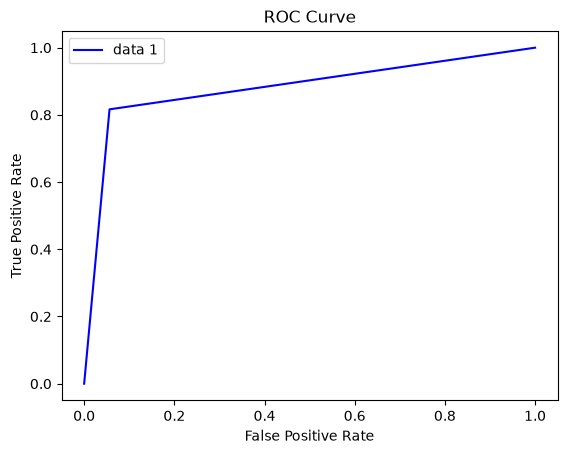

In [191]:
logRes.predict_proba(X_Test)
fpr, tpr, thresholds = metrics.roc_curve(Y_Test, Y_Pred_LR)

plt.plot(fpr, tpr, color='blue', label="data 1") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

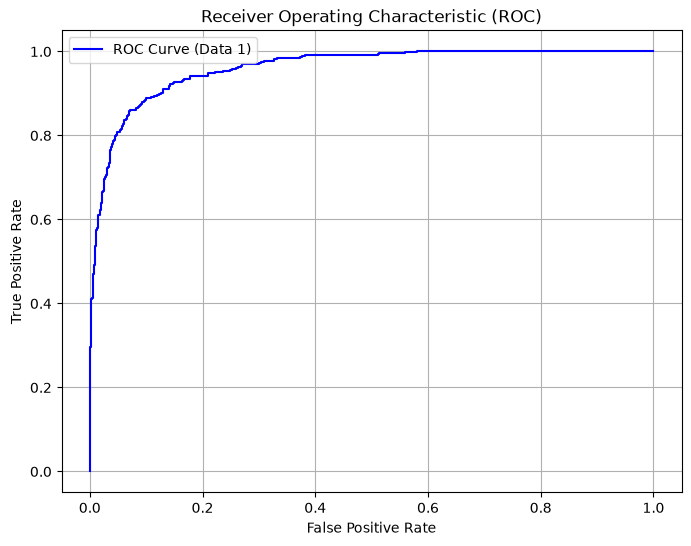

In [192]:
Y_prob_lR = logRes.predict_proba(X_Test)[:, 1]

fpr, tpr, thresholds = metrics.roc_curve(Y_Test, Y_prob_lR)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label="ROC Curve (Data 1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.show()

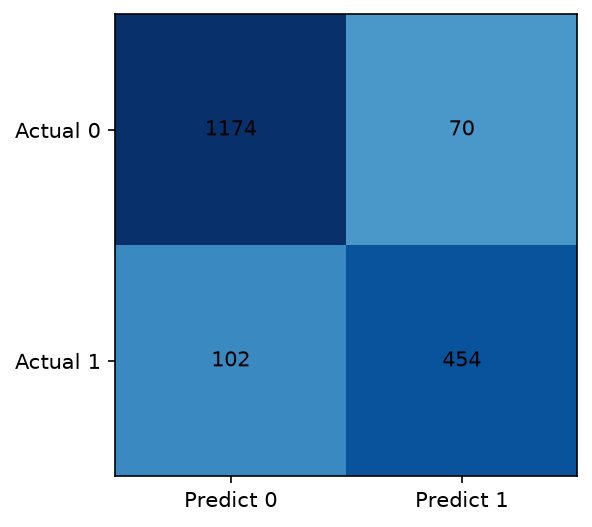

In [193]:
cm = metrics.confusion_matrix(Y_Test, logRes.predict(X_Test))
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
cax = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=("Predict 0", "Predict 1"))
ax.yaxis.set(ticks=(0, 1), ticklabels=("Actual 0", "Actual 1"))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()

In [194]:
lr_result = evaluate_model(logRes, X_Test, Y_Test, "Logistic Regression")
lr_result

,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Accuracy
Logistic Regression,0.92,0.866,0.944,0.817,0.932,0.841,0.893,0.88,0.886,0.904


### KNN

In [195]:
K = 20
Acc = np.zeros((K))

for i in range(1, K+1):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_Train, Y_Train.ravel())
    Y_Pred = knn.predict(X_Test)
    Acc[i-1] = metrics.accuracy_score(Y_Test, Y_Pred)
    
Acc

array([0.80333333, 0.80444444, 0.83055556, 0.82      , 0.84333333,
       0.83611111, 0.84055556, 0.835     , 0.84277778, 0.83833333,
       0.85      , 0.84166667, 0.84722222, 0.84277778, 0.85      ,
       0.84666667, 0.85333333, 0.84666667, 0.84722222, 0.84722222])

In [196]:
print(np.max(Acc))
print(np.min(Acc))

0.8533333333333334
0.8033333333333333


In [197]:
parameters = {"n_neighbors" : range(1, 20)}
grid_kn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parameters, scoring='recall', cv=5,
                       verbose=1, n_jobs=-1)
grid_kn.fit(X_Train, Y_Train)

print(Color.BOLD, Color.BLUE, grid_kn.best_params_)

Fitting 5 folds for each of 19 candidates, totalling 95 fits
  {'n_neighbors': 3}


In [198]:
train_score = {}
test_score = {}
n_neighbors = np.arange(2, 20, 1)
for neighbor in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_Train, Y_Train)
    train_score[neighbor]=knn.score(X_Train, Y_Train)
    test_score[neighbor]=knn.score(X_Test, Y_Test)

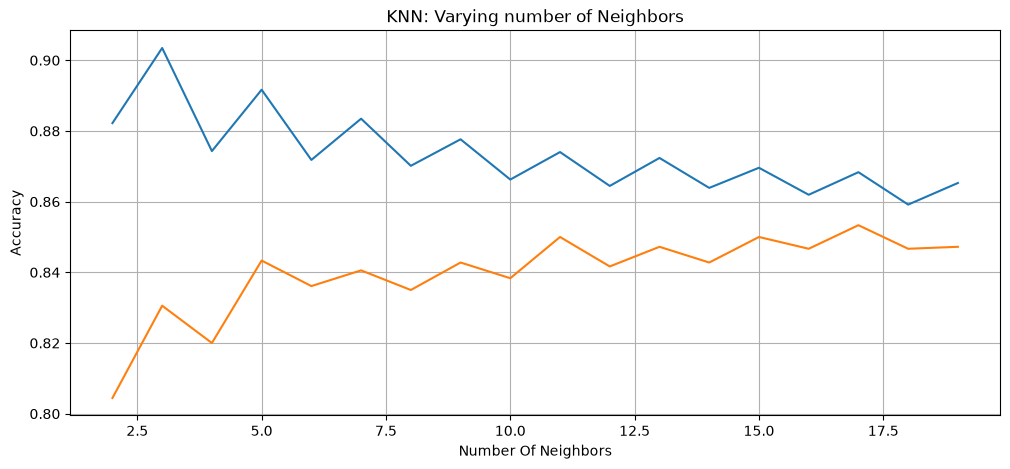

In [199]:
plt.figure(figsize=(12, 5))
plt.plot(n_neighbors, train_score.values(), label="Train Accuracy")
plt.plot(n_neighbors, test_score.values(), label="Test Accuracy")
plt.xlabel("Number Of Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN: Varying number of Neighbors")
plt.grid()
plt.show()

In [200]:
for key, value in test_score.items():
    if value==max(test_score.values()):
        print(key)

17


In [201]:
knn = KNeighborsClassifier(17)
knn.fit(X_Train, Y_Train)
Y_Pred_knn = knn.predict(X_Test)
print(Color.BLUE, Color.BOLD, "The Accuracy of KNN :", metrics.accuracy_score(Y_Test, Y_Pred_knn) * 100)
print(Color.BLUE, Color.BOLD, "The Recall of KNN :", metrics.recall_score(Y_Test, Y_Pred_knn) * 100)

  The Accuracy of KNN : 85.33333333333334
  The Recall of KNN : 60.431654676258994


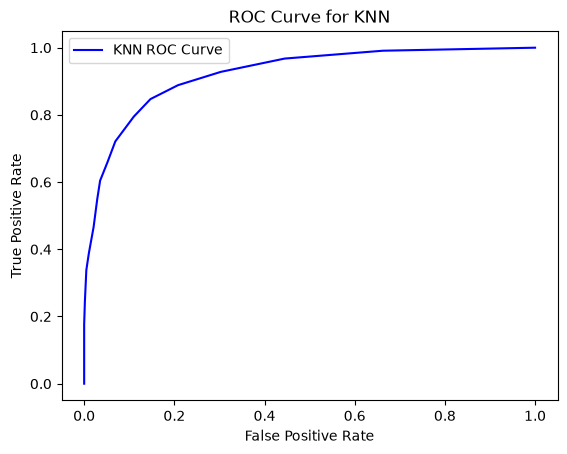

In [202]:
y_prob_knn = knn.predict_proba(X_Test)[:, 1] 
fpr, tpr, thresholds = metrics.roc_curve(Y_Test, y_prob_knn)

plt.plot(fpr, tpr, color='blue', label='KNN ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN')
plt.legend()
plt.show()

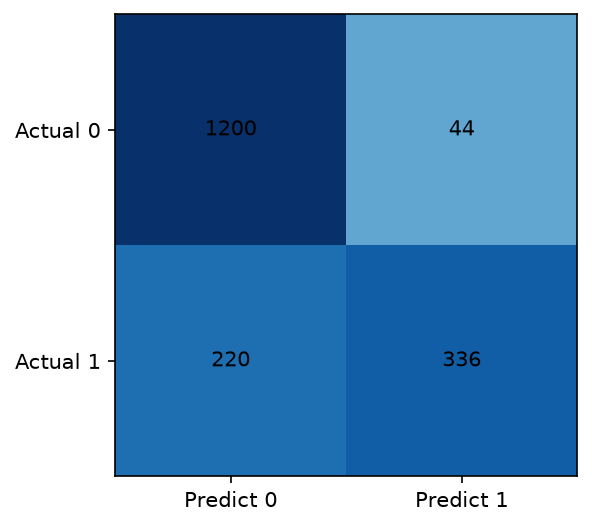

In [203]:
cm = metrics.confusion_matrix(Y_Test, knn.predict(X_Test))
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
cax = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=("Predict 0", "Predict 1"))
ax.yaxis.set(ticks=(0, 1), ticklabels=("Actual 0", "Actual 1"))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()

In [204]:
knn_result = evaluate_model(knn, X_Test, Y_Test, "KNN")
knn_result

,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Accuracy
KNN,0.845,0.884,0.965,0.604,0.901,0.718,0.865,0.784,0.809,0.853


### Random Forest

In [205]:
random_forest = RandomForestClassifier(criterion="entropy", max_depth=20, n_estimators=100, min_samples_split=2, random_state=42)
random_forest.fit(X_Train, Y_Train)
Y_Pred_RF = random_forest.predict(X_Test)
print(Color.BLUE, Color.BOLD, "Model Accuracy:", metrics.accuracy_score(Y_Test, Y_Pred_RF) * 100)
print(Color.BLUE, Color.BOLD, "Model recall:", metrics.recall_score(Y_Test, Y_Pred_RF) * 100)

  Model Accuracy: 89.0
  Model recall: 76.2589928057554


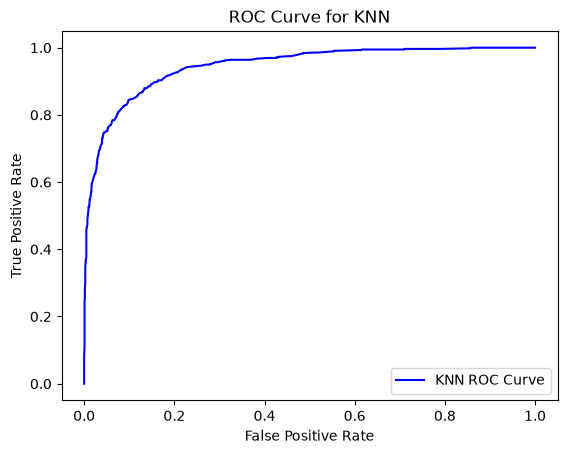

In [206]:
y_prob_RF = random_forest.predict_proba(X_Test)[:, 1] 

fpr, tpr, thresholds = metrics.roc_curve(Y_Test, y_prob_RF)

plt.plot(fpr, tpr, color='blue', label='KNN ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNN')
plt.legend()
plt.show()

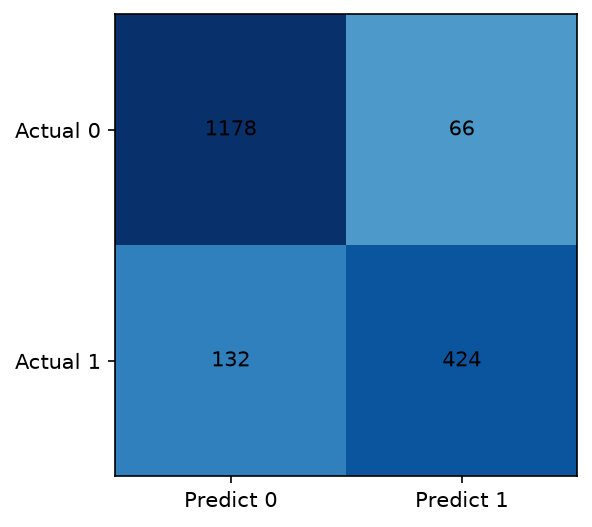

In [207]:
cm = metrics.confusion_matrix(Y_Test, random_forest.predict(X_Test))
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
cax = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=("Predict 0", "Predict 1"))
ax.yaxis.set(ticks=(0, 1), ticklabels=("Actual 0", "Actual 1"))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()

In [208]:
rf_result = evaluate_model(random_forest, X_Test, Y_Test, "Random Forest")
rf_result

,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Accuracy
Random Forest,0.899,0.865,0.947,0.763,0.922,0.811,0.882,0.855,0.867,0.89


### SVM

In [209]:
svm = SVC(kernel="linear", C=10, degree=2, probability=True)
svm.fit(X_Train, Y_Train)
Y_Pred_svm = svm.predict(X_Test)
print(Color.BLUE, Color.BOLD, "Model Accuracy:", metrics.accuracy_score(Y_Test, Y_Pred_svm) * 100)
print(Color.BLUE, Color.BOLD, "Model Recall:", metrics.recall_score(Y_Test, Y_Pred_svm) * 100)

  Model Accuracy: 90.61111111111111
  Model Recall: 80.75539568345323


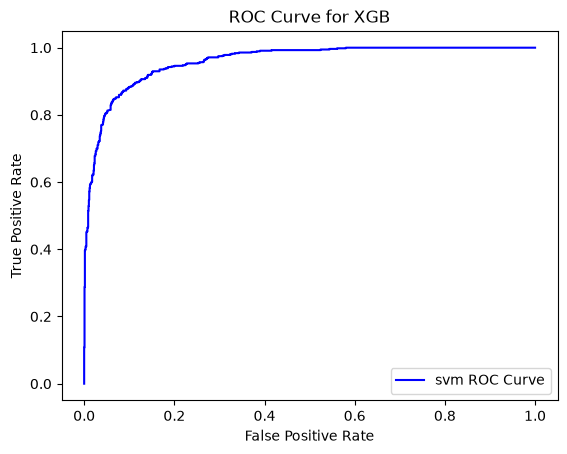

In [210]:
y_prob_svm = svm.predict_proba(X_Test)[:, 1] 

fpr, tpr, thresholds = metrics.roc_curve(Y_Test, y_prob_svm)

plt.plot(fpr, tpr, color='blue', label='svm ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGB')
plt.legend()
plt.show()

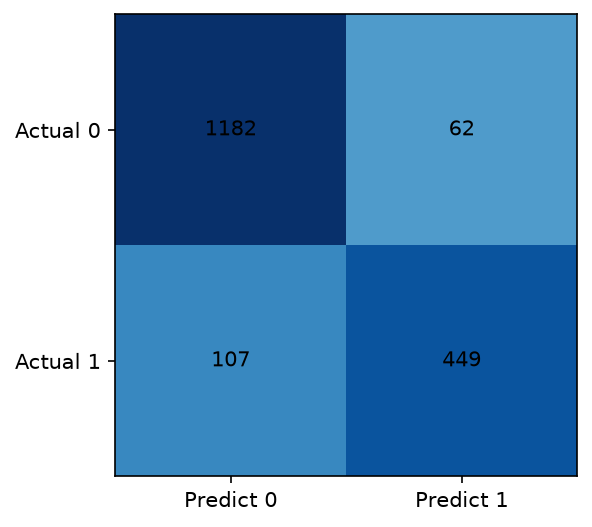

In [211]:
cm = metrics.confusion_matrix(Y_Test, svm.predict(X_Test))
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
cax = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=("Predict 0", "Predict 1"))
ax.yaxis.set(ticks=(0, 1), ticklabels=("Actual 0", "Actual 1"))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()

In [212]:
svm_result = evaluate_model(svm, X_Test, Y_Test, "SVM")
svm_result

,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Accuracy
SVM,0.917,0.879,0.95,0.808,0.933,0.842,0.898,0.879,0.887,0.906


### XGboots

In [213]:
xgb = XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.3, eval_metric="logloss")
xgb.fit(X_Train, Y_Train)
Y_Pred_xgb = xgb.predict(X_Test)
print(Color.BLUE, Color.BOLD, "Model Accuracy:", metrics.accuracy_score(Y_Test, Y_Pred_xgb) * 100)
print(Color.BLUE, Color.BOLD, "Model recall:", metrics.recall_score(Y_Test, Y_Pred_xgb) * 100)

  Model Accuracy: 89.38888888888889
  Model recall: 80.39568345323741


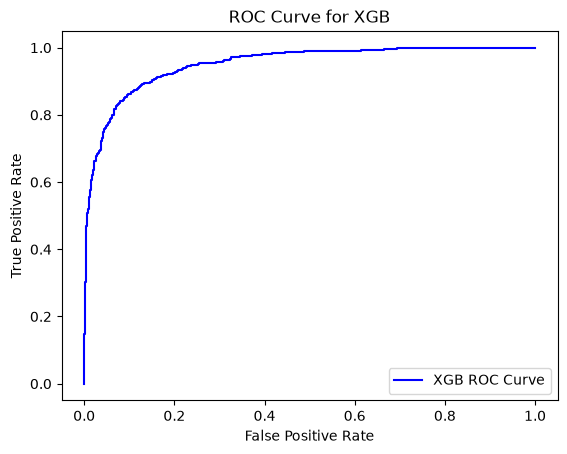

In [214]:
y_prob_xgb = xgb.predict_proba(X_Test)[:, 1] 

fpr, tpr, thresholds = metrics.roc_curve(Y_Test, y_prob_xgb)

plt.plot(fpr, tpr, color='blue', label='XGB ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGB')
plt.legend()
plt.show()

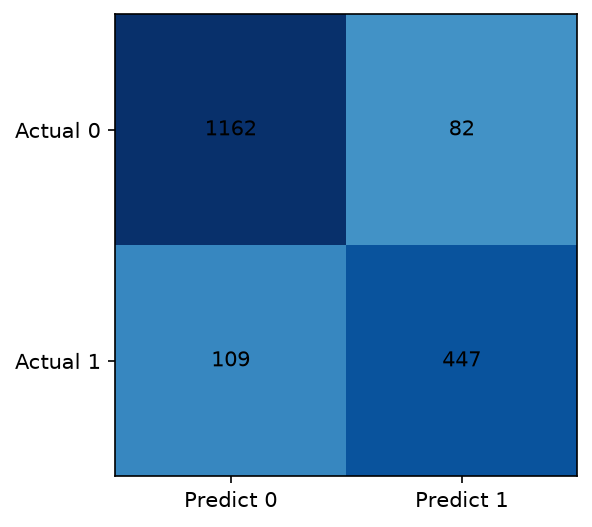

In [215]:
cm = metrics.confusion_matrix(Y_Test, xgb.predict(X_Test))
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
cax = ax.imshow(cm, cmap='Blues', norm=LogNorm(vmin=1, vmax=cm.max()))
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=("Predict 0", "Predict 1"))
ax.yaxis.set(ticks=(0, 1), ticklabels=("Actual 0", "Actual 1"))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()

In [216]:
xgb_result = evaluate_model(xgb, X_Test, Y_Test, "XGBoost")
xgb_result

,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Accuracy
XGBoost,0.914,0.845,0.934,0.804,0.924,0.824,0.88,0.869,0.874,0.894


* #### Model Performance Comparison

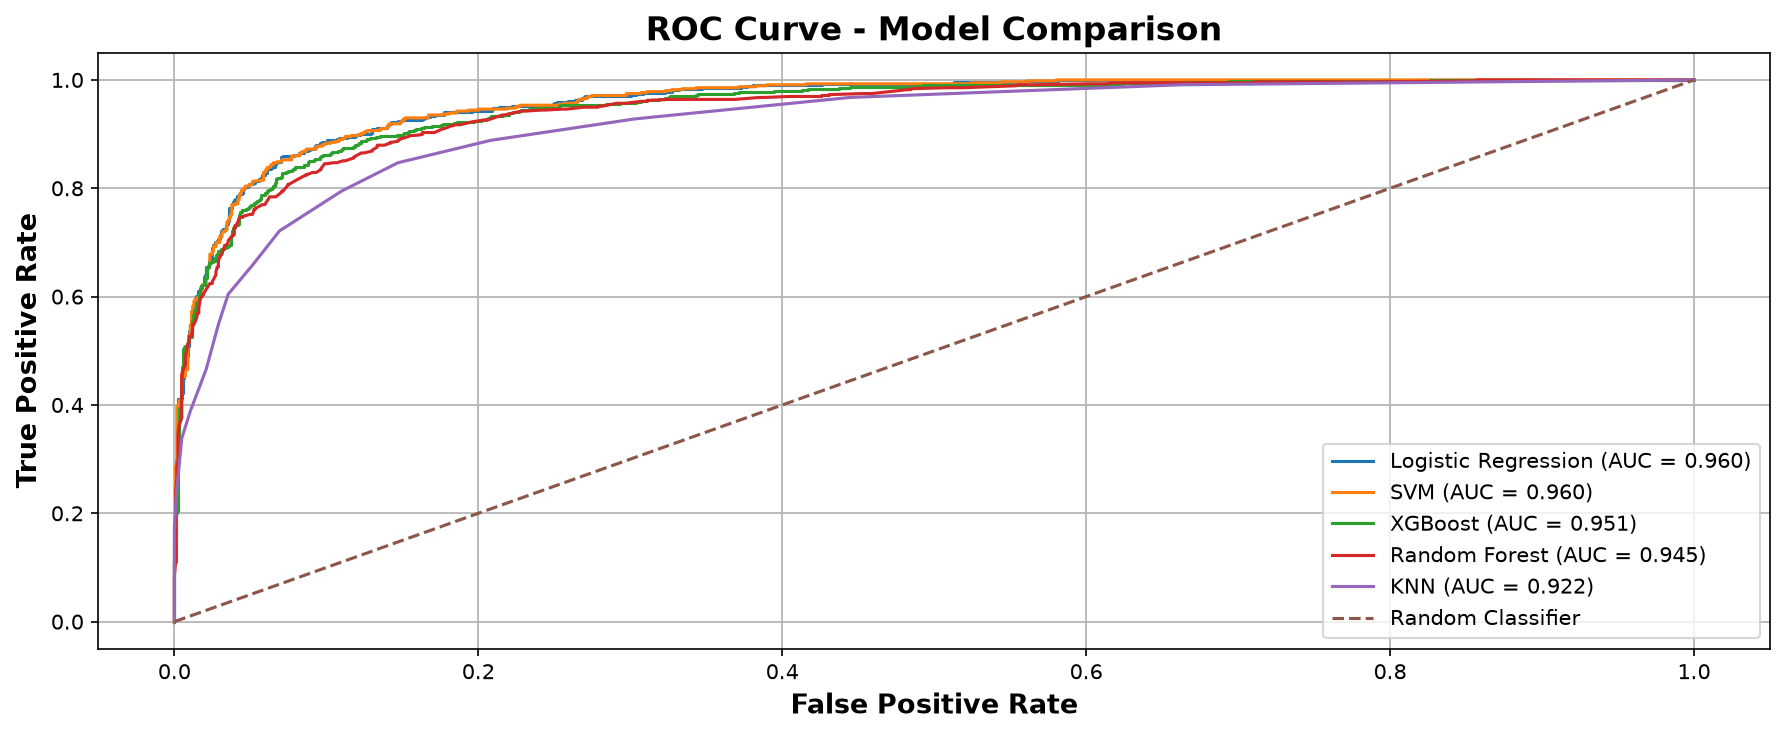

In [217]:
# Models
models_prob = {
    "Logistic Regression": Y_prob_lR,
    "SVM": y_prob_svm,
    "XGBoost": y_prob_xgb,
    "Random Forest": y_prob_RF,
    "KNN": y_prob_knn
}

plt.figure(figsize=(12, 5), dpi=150)
for model_name, y_prob in models_prob.items():
    fpr, tpr, _ = metrics.roc_curve(Y_Test, y_prob)
    auc_score = metrics.roc_auc_score(Y_Test, y_prob)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

# Random Classifier
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate", fontsize=13, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=13, fontweight="bold")
plt.title("ROC Curve - Model Comparison", fontsize=16, fontweight="bold")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
In this section, the ROC curves for **Logistic Regression, SVM, XGBoost, Random Forest, and KNN** models have been plotted to compare their ability to distinguish between the two classes of **heart disease** and **no heart disease**.

The vertical axis of the plot represents the **true positive rate (TPR)** or **Recall**, while the horizontal axis represents the **false positive rate (FPR)**. Each point on the ROC curve shows the model’s performance at a different decision threshold. The diagonal line in the plot represents the performance of a **random classifier**, and suitable models should have their curves above this line.

The **AUC (Area Under the ROC Curve)** metric has also been used for the overall comparison of the models. AUC indicates the model’s ability to distinguish positive samples from negative samples across different thresholds. The closer the AUC value is to 1, the greater the model’s ability to distinguish between the two classes.

Based on the plot, **Logistic Regression and SVM** have the highest value among the evaluated models, with **AUC = 0.960**. They are followed by **XGBoost with AUC = 0.951** and **Random Forest with AUC = 0.945**. The **KNN** model achieved the lowest AUC among the evaluated models, with **AUC = 0.922**.

Therefore, based on the AUC metric, Logistic Regression and SVM show a higher ability to **distinguish between the two classes** at this stage, while KNN performs less well compared with the other models. However, this conclusion is solely related to the ROC and AUC analysis, and **the final model is not selected at this stage**; because selecting the appropriate model requires considering other metrics such as Precision, Recall, F1-Score, Accuracy, and Confusion Matrix as well.
</p> 
</div>

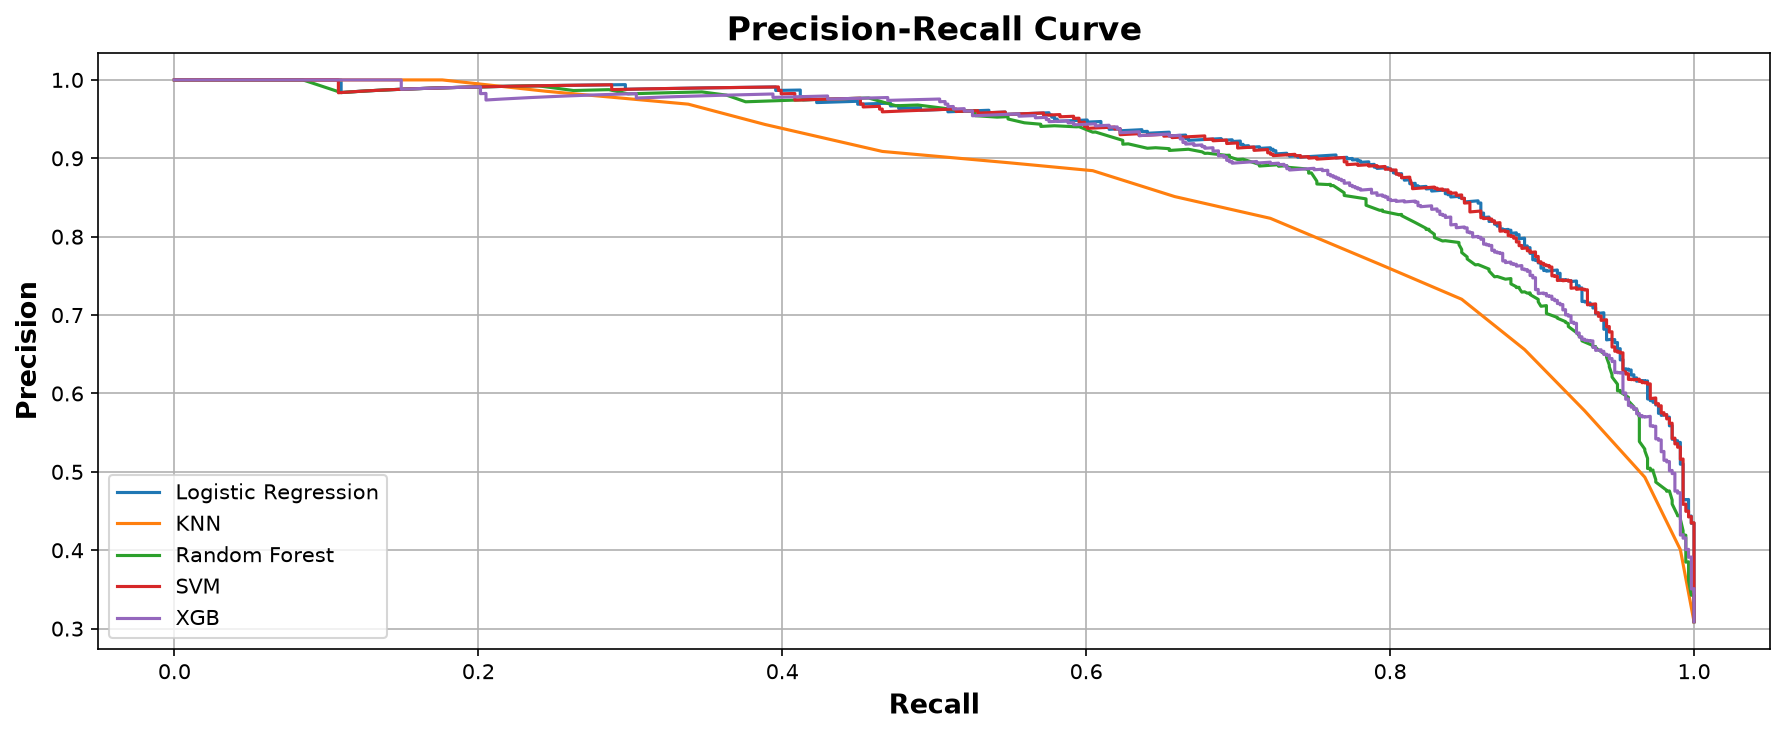

In [218]:
precision_LR, recall_LR, _ = precision_recall_curve(Y_Test, Y_prob_lR)
precision_KNN, recall_KNN, _ = precision_recall_curve(Y_Test, y_prob_knn)
precision_RF, recall_RF, _ = precision_recall_curve(Y_Test, y_prob_RF)
precision_svm, recall_svm, _ = precision_recall_curve(Y_Test, y_prob_svm)
precision_xgb, recall_xgb, _ = precision_recall_curve(Y_Test, y_prob_xgb)


plt.figure(figsize=(12, 5), dpi=150)

plt.plot(recall_LR, precision_LR, label="Logistic Regression")
plt.plot(recall_KNN, precision_KNN, label="KNN")
plt.plot(recall_RF, precision_RF, label="Random Forest")
plt.plot(recall_svm, precision_svm, label="SVM")
plt.plot(recall_xgb, precision_xgb, label="XGB")

plt.xlabel("Recall", fontsize=13, fontweight="bold")
plt.ylabel("Precision", fontsize=13, fontweight="bold")
plt.title("Precision-Recall Curve", fontsize=16, fontweight="bold")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
Recall indicates the model’s ability to identify actual patients, while Precision indicates the correctness of the model’s positive predictions.
As Recall increases, Precision usually decreases, indicating a Trade-off between Precision and Recall.
Logistic Regression, SVM, and XGBoost showed a better balance between Precision and Recall compared with the other models.
Random Forest performed relatively well, but in some regions it ranked below the three models above.
KNN showed the greatest drop in Precision as Recall increased and performed worse than the other models.
This chart is only one of the evaluation metrics, and the final model selection should be made by considering other metrics such as Accuracy, F1-Score, Confusion Matrix, and ROC-AUC.
</p> 
</div>

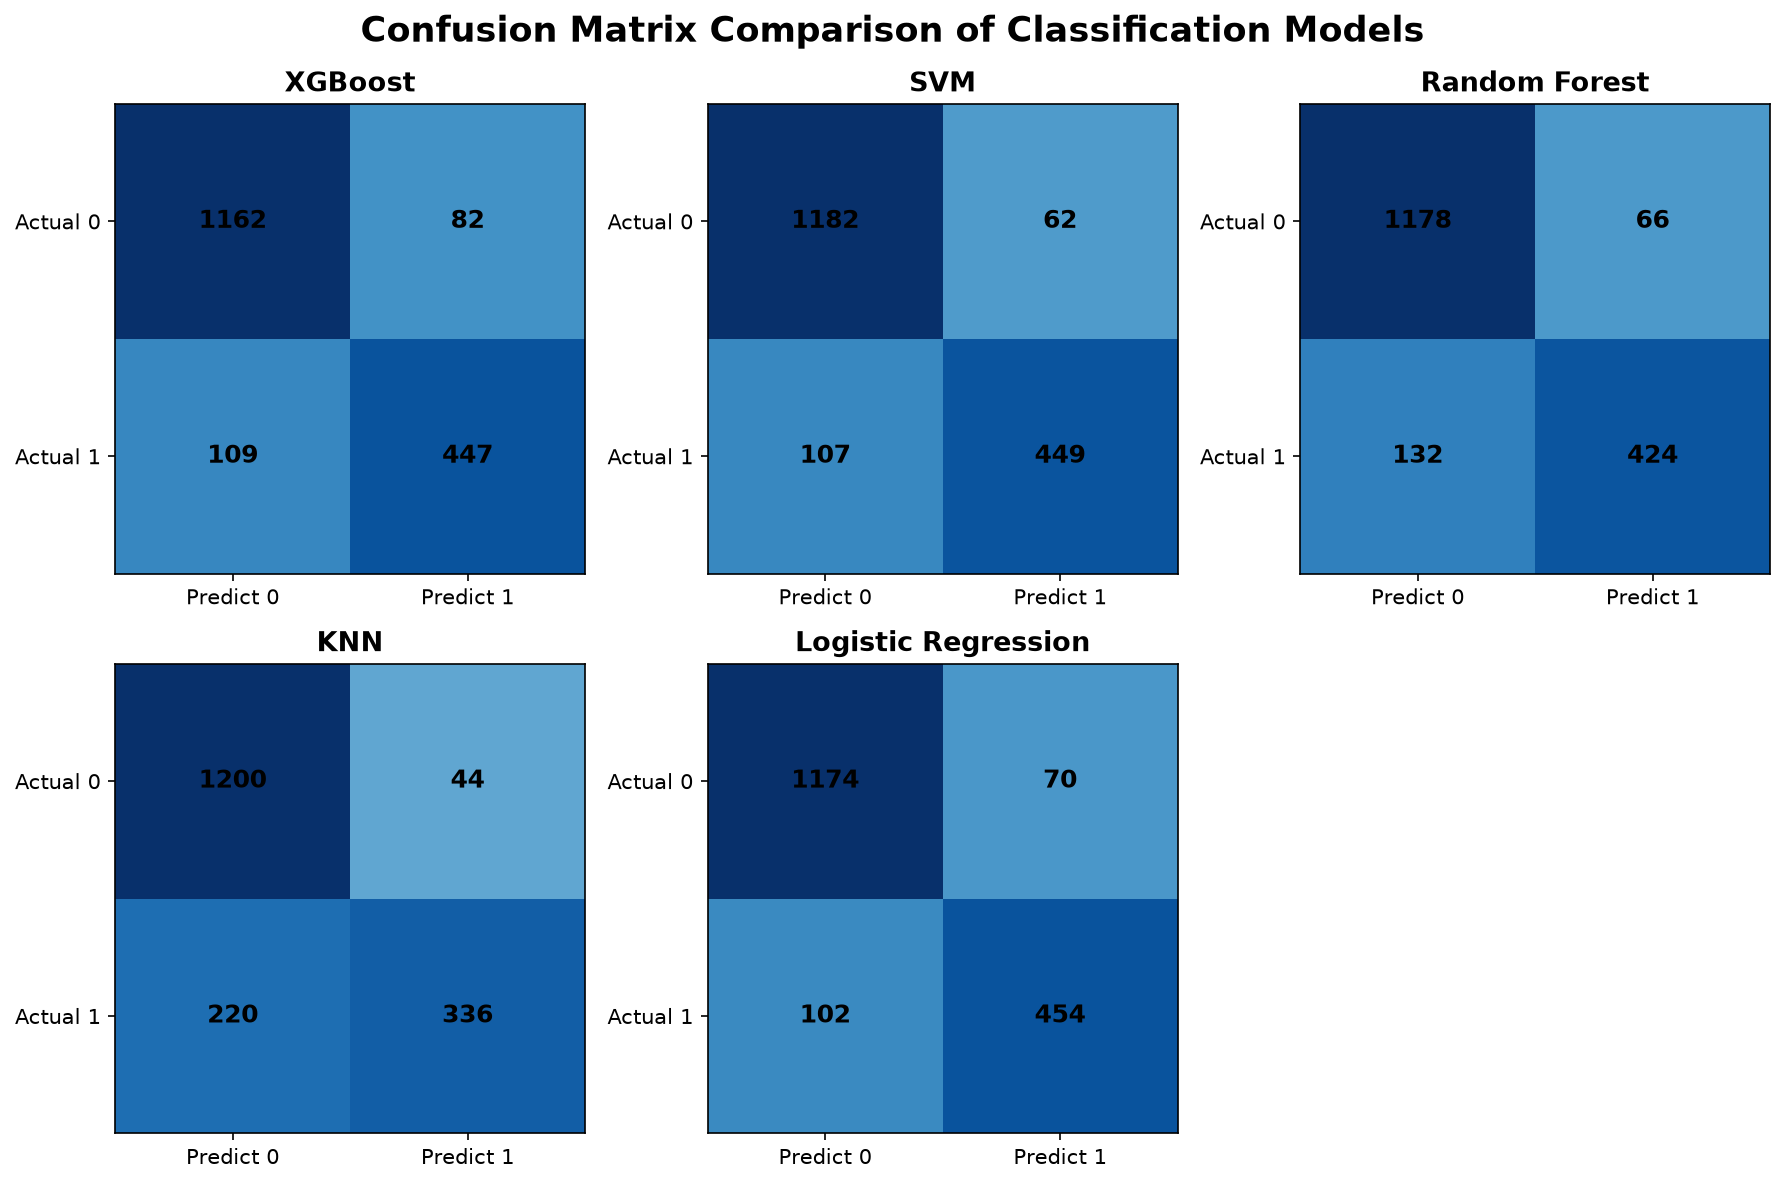

In [219]:
# Models
models = {
    "XGBoost": xgb,
    "SVM": svm,
    "Random Forest": random_forest,
    "KNN": knn,
    "Logistic Regression": logRes
}

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)
axes = axes.flatten()
# Plot confusion matrix for each model
for ax, (model_name, model) in zip(axes, models.items()):
    cm = metrics.confusion_matrix(Y_Test, model.predict(X_Test))

    cax = ax.imshow(cm, cmap="Blues", norm=LogNorm(vmin=1, vmax=cm.max()))

    ax.grid(False)
    ax.xaxis.set(ticks=(0, 1), ticklabels=("Predict 0", "Predict 1"))
    ax.yaxis.set(ticks=(0, 1), ticklabels=("Actual 0", "Actual 1"))
    ax.set_ylim(1.5, -0.5)

    # Numbers inside matrix
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12, fontweight="bold")

    ax.set_title(model_name, fontsize=13, fontweight="bold")

# Remove empty subplot
fig.delaxes(axes[-1])
fig.suptitle("Confusion Matrix Comparison of Classification Models", fontsize=17, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The confusion matrix for five models, Logistic Regression، SVM، XGBoost، Random Forest و KNN, was examined. This matrix shows the number of correct predictions and errors made by each model for the two classes, No Heart Disease and Heart Disease.

In this comparison, Logistic Regression showed the best performance in identifying actual patients, with 102 False Negative samples and 454 True Positive samples. It was followed by SVM with 107 and XGBoost with 109 False Negative samples.

Random Forest had weaker performance in identifying actual patients, with 132 False Negative samples. KNN had the highest number of missed patients, with 220 False Negative samples, and consequently showed a lower Recall for the Heart Disease class.

On the other hand, KNN performed very well in identifying individuals without the disease, with 1200 True Negative samples and only 44 False Positive samples, but this performance came at the cost of missing a larger number of actual patients.

Therefore, the Confusion Matrix analysis shows that there is a significant difference among the models in terms of the types of errors they make. In the problem of heart disease diagnosis, special attention should be paid to False Negative, because this error represents a patient whose disease was not identified by the model. However, the Confusion Matrix alone is not sufficient for model selection and should be evaluated alongside other performance metrics.
</p> 
</div>

In [220]:
# Concatenate the dataframes
all_evaluations = [lr_result, knn_result, rf_result, svm_result, xgb_result]
results = pd.concat(all_evaluations)

# Sort by 'recall_1'
results = results.sort_values(by='Recall 1', ascending=False).round(2)

In [221]:
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: blue " if v else "" for v in is_max]

In [222]:
results.style.apply(highlight_max, subset=["Recall 1"])

,Precision 0,Precision 1,Recall 0,Recall 1,F1 0,F1 1,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Accuracy
Logistic Regression,0.920000,0.870000,0.940000,0.820000,0.930000,0.840000,0.890000,0.880000,0.890000,0.900000
SVM,0.920000,0.880000,0.950000,0.810000,0.930000,0.840000,0.900000,0.880000,0.890000,0.910000
XGBoost,0.910000,0.840000,0.930000,0.800000,0.920000,0.820000,0.880000,0.870000,0.870000,0.890000
Random Forest,0.900000,0.860000,0.950000,0.760000,0.920000,0.810000,0.880000,0.860000,0.870000,0.890000
KNN,0.840000,0.880000,0.960000,0.600000,0.900000,0.720000,0.860000,0.780000,0.810000,0.850000


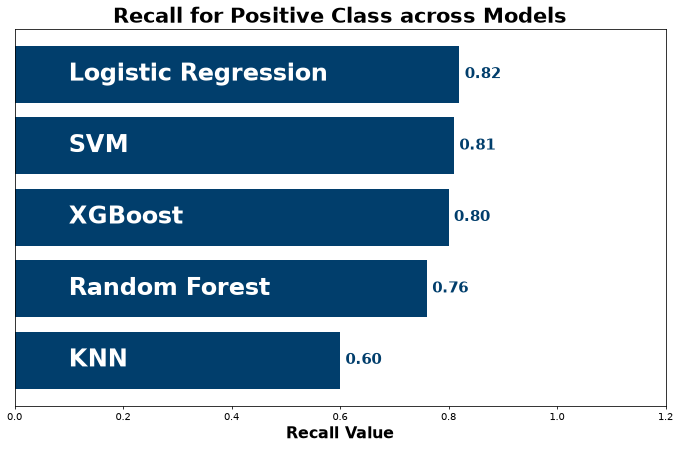

In [223]:
# Sort values based on 'Recall 1'
results.sort_values(by='Recall 1', ascending=True, inplace=True)
recall_1_scores = results['Recall 1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)
ax.barh(results.index, recall_1_scores, color='#013e6c')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(recall_1_scores, results.index)):
    ax.text(value + 0.01, i, f"{value:.2f}", ha='left', va='center', fontweight='bold', color='#013e6c', fontsize=15)
    ax.text(0.1, i, name, ha='left', va='center', fontweight='bold', color='white', fontsize=25)

# Remove yticks
ax.set_yticks([])

# Set x-axis limit
ax.set_xlim([0, 1.2])

# Add title and xlabel
plt.title("Recall for Positive Class across Models", fontweight='bold', fontsize=22)
plt.xlabel('Recall Value', fontsize=16, fontweight='bold')
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
In this section, the performance of different models was compared using the Precision, Recall, F1-Score, and Accuracy metrics. The results showed that Logistic Regression and SVM performed better than the other models, while KNN showed the weakest performance in identifying actual patients.

By examining the overall results obtained from the Classification Report، Confusion Matrix، ROC Curve، Precision-Recall Curve، and other evaluations conducted, Logistic Regression was ultimately selected as the final model for the project.
</p> 
</div>

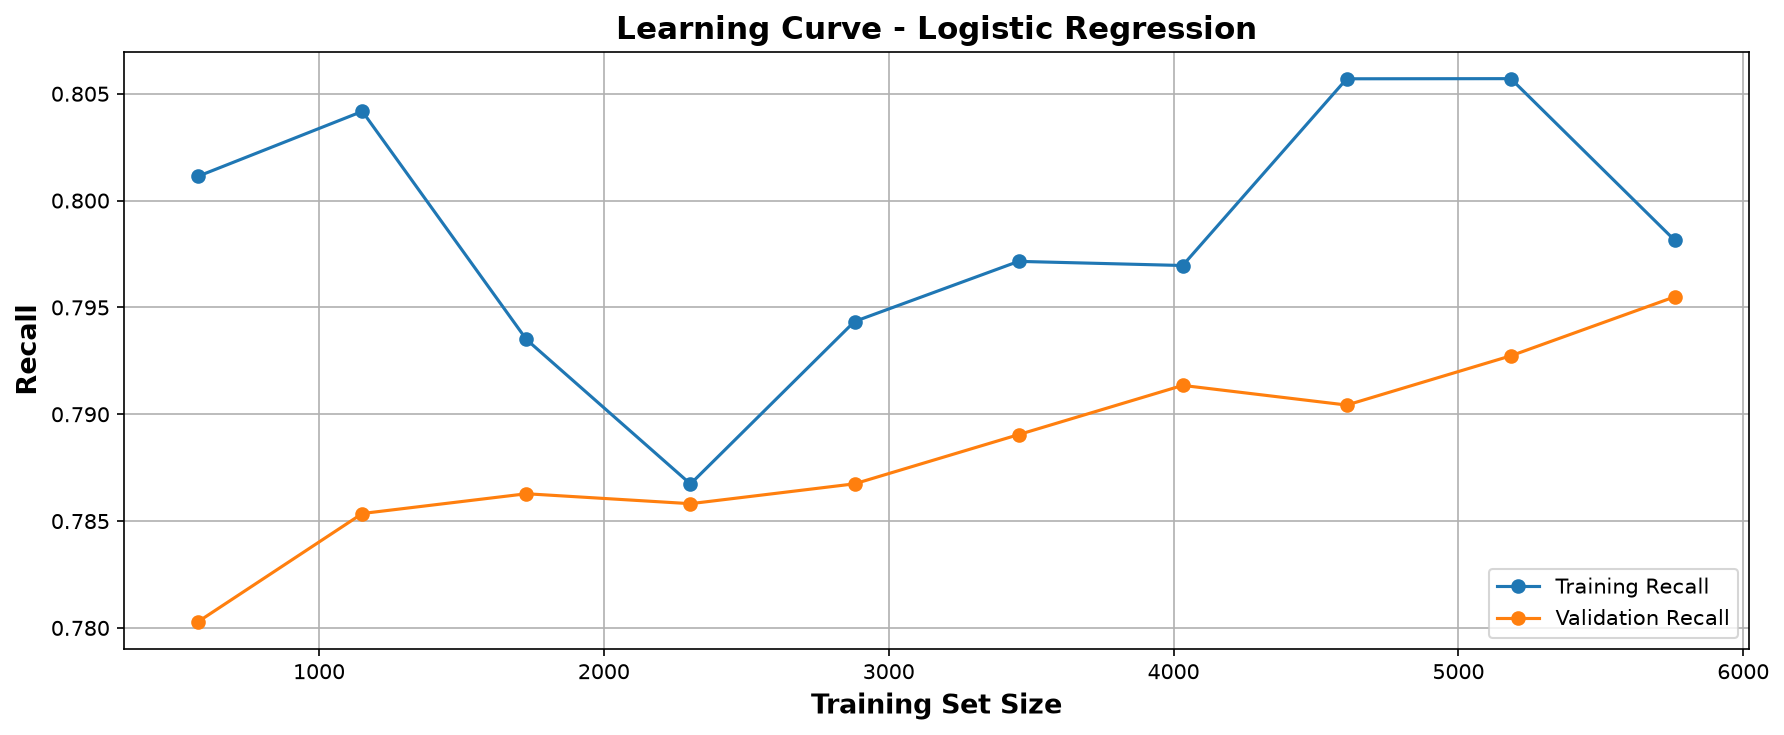

In [224]:
train_sizes, train_scores, validation_scores = learning_curve(logRes, X_Train, Y_Train, cv=5, scoring="recall",
                                                              train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(12, 5), dpi=150)

plt.plot(train_sizes, train_mean, marker="o", label="Training Recall")
plt.plot(train_sizes, validation_mean, marker="o", label="Validation Recall")

plt.xlabel("Training Set Size", fontsize=13, fontweight="bold")
plt.ylabel("Recall", fontsize=13, fontweight="bold")
plt.title("Learning Curve - Logistic Regression", fontsize=15, fontweight="bold")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

<div style="
    max-width: 1200px;
    margin: 24px auto;
    padding: 16px 20px;
    background-color: #013e6c;
    border-radius: 6px;
    font-family: 'vazir';
    font-size: 16px;
    line-height: 1.7;
    color: white;
">
<h3 style= 'font-weight:900;'>
</h3>
<p> 
The learning curve shows that as the volume of training data increases, Validation Recall has generally increased. This indicates that with more data, the model becomes better at identifying patients on new data.

The gap between Training Recall and Validation Recall indicates some difference between the model’s performance on the training data and the validation data. However, the upward trend in Validation Recall shows that within the range of data examined, the model still benefits from additional training data and has not yet reached full saturation.

Overall, this chart indicates that increasing the volume of training data has the potential to improve the model’s Generalization and Recall.
</p> 
</div>

* #### Model output

In [226]:
model_data = {
    "model": logRes,
    "scaler": scaler
}

joblib.dump(model_data, "../ML models/heart_disease_model.pkl")

['../ML models/heart_disease_model.pkl']